<a href="https://colab.research.google.com/github/JoseAlberto88/Predictive-Maintenance-Dataset/blob/main/Predictive_Maintenance_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DAMO-510-8. Predictive Analytics
## Take-Home Assignment 2: Predictive Maintenance. Machine Failure Prediction


**Course:** Predictive Analytics (DAMO-510-8)

**Term:** Summer 2026

**Instructor:** Prof. Payman Janbakhsh

**Student:** Jose Alberto Martinez Morales

---

## Background

Unexpected machine failures can cause production delays, increased maintenance costs, safety concerns, and operational disruption. Predictive analytics can support maintenance planning by identifying machines that exhibit operating conditions associated with a higher risk of failure.

In this assignment, you will develop and critically evaluate classification models using the AI4I 2020 Predictive Maintenance Dataset.

The purpose of this assignment is not simply to obtain the highest model accuracy. You are expected to demonstrate appropriate analytical judgement regarding data preparation, variable selection, class imbalance, model development, evaluation, interpretation, and operational decision-making.

## Dataset

Use the AI4I 2020 Predictive Maintenance Dataset from the UCI Machine Learning Repository:

https://archive.ics.uci.edu/dataset/601/ai4i+2020+predictive+maintenance+dataset

**Target variable:** `Machine failure`

You must use the original dataset obtained from the stated source.


In [1]:
# For this assignment, I will save the Maintenance Dataset in my Google drive and call it using code.
# If you want to run the jupyter notebook in your local machine, please change the directory described in the next code block.

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

DATA_FILE = '/content/drive/MyDrive/Predictive Analytics Course/Maintenance Dataset.csv'
df = pd.read_csv(DATA_FILE)

# To check the 5 first observations of the dataset
print("Initial shape:", df.shape)
df.head()

Initial shape: (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## Assignment Tasks

### Task 1. Problem Definition

Define the predictive problem represented by the dataset.

Your discussion must:

- clearly identify the target variable and classes;
- explain the purpose of predicting machine failure;
- identify potential users of such a prediction system;
- distinguish between the operational consequences of false-positive and false-negative predictions; and
- identify the evaluation criteria you believe should receive the greatest emphasis in this problem.

Support your choices using the context of predictive maintenance rather than generic definitions of classification.

### Task 1. Problem Definition

#### **Explanation: Target Variables and Classes**
The AI4I 2020 dataset frames a binary classification problem centred on the variable **Machine failure**, which takes the value 1 when a machine tool has experienced at least one of five recorded failure modes during an operating cycle (tool wear failure, heat dissipation failure, power failure, overstrain failure, or random failure) and 0 when it has not. Of the 10,000 recorded observations, failures are a small minority of cases, which already signals that this is a rare-event detection problem rather than a balanced discrimination task, a point that shapes every later modelling decision, from the choice of resampling strategy to the metrics used to judge success.

#### **Explanation: Purpose of Predicting Machine Failure**
The purpose of predicting machine failure is to shift maintenance activity away from the two conventional regimes that dominate manufacturing operations. Purely reactive maintenance repairs a machine only after it has broken, which guarantees unplanned downtime, and time-based preventive maintenance services equipment on a fixed schedule regardless of its actual condition, which wastes labour and parts on machines that did not need attention while still missing failures that occur between scheduled visits. A predictive model that flags an elevated failure risk from live operating conditions, such as temperatures, rotational speed, torque, and tool wear,  allows maintenance to be triggered by the actual state of the machine rather than by the calendar or by failure itself, which is the basic value proposition of condition-based, predictive maintenance.


#### **Identification: Potential Users of such a Prediction System**
The natural users of such a system are the people who plan and execute maintenance work rather than the data science team that builds it: maintenance and reliability engineers who would use the model's output to prioritise inspection queues, production planners and plant managers who need advance warning to schedule downtime without disrupting delivery commitments, shop-floor technicians who would receive an operational alert rather than a probability score, and, indirectly, safety personnel, since several of the underlying failure modes (heat dissipation, overstrain) are also safety-relevant conditions. In practice, the model's output would most plausibly be consumed through a maintenance dashboard or a computerised maintenance management system (CMMS) rather than read directly as raw model output.

#### **Distintion: False-Positive and False-Negative Predictions**
Because this is a binary decision problem applied to a physical process, the two error types are not interchangeable, and treating them as symmetric would misrepresent the operational reality the model is meant to serve. A **false positive**, it means the model predicts failure when the machine is in fact healthy, triggers an unnecessary inspection or maintenance stoppage. This has a real but bounded cost: lost production time, technician labour, and, if false alarms are frequent, an erosion of operator trust that can lead staff to start ignoring the system altogether (alarm fatigue), which would defeat its purpose over time. A **false negative**, it means the model predicts no failure when the machine is about to fail, is materially more costly in most predictive-maintenance settings: it means the failure is discovered only when it actually occurs, with the same unplanned downtime, cascading equipment damage, and safety exposure that predictive maintenance was introduced to avoid, plus the reputational cost of a system that failed to warn when it was supposed to. Because the dataset also implies a low base rate of failure, the asymmetry compounds: with failures scarce and their cost to miss high, a model that defaults toward the majority "no failure" prediction can look accurate while providing little of the protection the business actually needs.

#### **Identification and Evaluation Criteria**
This asymmetry is what should drive the choice of evaluation criteria, and it argues against using overall accuracy as the primary yardstick, since with failures forming a small share of observations a trivial always-predict-no-failure model would already score highly on accuracy while being operationally useless. The metric that should receive the greatest emphasis is **recall on the failure class** (the proportion of actual failures the model successfully flags), because in this problem missing a failure is more expensive than issuing an avoidable inspection. Recall should not be optimised in isolation, however: a model that maximises recall by flagging almost everything as high-risk would generate so many false alarms that maintenance staff could not act on them meaningfully, so **precision** and a metric that balances the two (F1, or an F-beta score that weights recall above precision to reflect the cost asymmetry) should be tracked alongside it, together with a threshold-independent measure such as **ROC-AUC** to assess the model's underlying ability to separate failing from healthy machines before any specific operating threshold is chosen. This combination, recall-weighted performance on the minority class, checked against precision to keep false alarms manageable, and summarised by a threshold-independent ranking metric, reflects how the model would actually be judged and operated in a predictive-maintenance context, rather than how a classifier is conventionally scored in a balanced, generic setting.


### Task 2. Data Audit

Conduct an audit of the original dataset.

Your submission must provide evidence regarding:

- dataset dimensions;
- variable types;
- target distribution;
- missing information;
- duplicate observations;
- unusual or potentially problematic values;
- categorical and numerical predictors;
- identifier-like variables; and
- any variables that may create data leakage.

Determine which variables should and should not be included in your predictive model. You must justify all exclusions.

Special attention must be given to: **TWF, HDF, PWF, OSF, and RNF**.

Simply removing these variables without explaining your reasoning is insufficient.

#### **Dimensions, types, target distribution:**

In [3]:
# Dataset dimentions
print("Shape (rows, columns):", df.shape)

# Variballe types
print(df.dtypes)
df.info()

# target distribution
print(df['Machine failure'].value_counts())
print(df['Machine failure'].value_counts(normalize=True) * 100)

Shape (rows, columns): (10000, 14)
UDI                          int64
Product ID                  object
Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K] 

#### **Missing values and duplicates**

In [4]:
# Missing information
missing_summary = pd.DataFrame({
    'missing_count' : df.isnull().sum(),
    'missing_pct' : (df.isnull().mean() * 100).round(2)
})

print(missing_summary)

# Duplicates observations
print("Fully duplicated rows:", df.duplicated().sum())
print("Duplicate UDI values:", df['UDI'].duplicated().sum())
print("Duplicate Product ID values:", df['Product ID'].duplicated().sum())

feature_cols = df.columns.difference(['UDI', 'Product ID'])

print("Duplicate feature combos (excl. identifiers):", df.duplicated(subset=feature_cols).sum())

                         missing_count  missing_pct
UDI                                  0          0.0
Product ID                           0          0.0
Type                                 0          0.0
Air temperature [K]                  0          0.0
Process temperature [K]              0          0.0
Rotational speed [rpm]               0          0.0
Torque [Nm]                          0          0.0
Tool wear [min]                      0          0.0
Machine failure                      0          0.0
TWF                                  0          0.0
HDF                                  0          0.0
PWF                                  0          0.0
OSF                                  0          0.0
RNF                                  0          0.0
Fully duplicated rows: 0
Duplicate UDI values: 0
Duplicate Product ID values: 0
Duplicate feature combos (excl. identifiers): 0


#### **Unusual/problematic values (physical plausibility plus outliers)**



In [5]:
numeric_cols = ["Air temperature [K]", "Process temperature [K]",
                 "Rotational speed [rpm]", "Torque [Nm]", "Tool wear [min]"]
print(df[numeric_cols].describe().T)

print("Negative values:\n", (df[numeric_cols] == 0).sum())

print("Zero values:\n", (df[numeric_cols] == 0).sum())
print("Process temp <= Air temp rows:", (df['Process temperature [K]'] <= df['Air temperature [K]']).sum())

print(df['Type'].value_counts())

for col in numeric_cols:
  q1, q3 = df[col].quantile([0.25, 0.75])
  iqr = q3 - q1
  lower = q1 - 1.5 * iqr
  upper = q3 + 1.5 * iqr
  n_out = ((df[col] < lower) | (df[col] > upper)).sum()
  print(f"{col}: {n_out} IQR outliers")

                           count        mean         std     min     25%  \
Air temperature [K]      10000.0   300.00493    2.000259   295.3   298.3   
Process temperature [K]  10000.0   310.00556    1.483734   305.7   308.8   
Rotational speed [rpm]   10000.0  1538.77610  179.284096  1168.0  1423.0   
Torque [Nm]              10000.0    39.98691    9.968934     3.8    33.2   
Tool wear [min]          10000.0   107.95100   63.654147     0.0    53.0   

                            50%     75%     max  
Air temperature [K]       300.1   301.5   304.5  
Process temperature [K]   310.1   311.1   313.8  
Rotational speed [rpm]   1503.0  1612.0  2886.0  
Torque [Nm]                40.1    46.8    76.6  
Tool wear [min]           108.0   162.0   253.0  
Negative values:
 Air temperature [K]          0
Process temperature [K]      0
Rotational speed [rpm]       0
Torque [Nm]                  0
Tool wear [min]            120
dtype: int64
Zero values:
 Air temperature [K]          0
Process temp

#### **Identifier check:**



In [6]:
# Identifier like variables
print("Unique UDI:", df['UDI'].nunique(), "of", len(df))
print("Unique Product ID:", df['Product ID'].nunique(), "of", len(df))
print("Product ID prefix == Type in",
      (df['Product ID'].str[0] == df['Type']).mean() * 100, "% of rows")

Unique UDI: 10000 of 10000
Unique Product ID: 10000 of 10000
Product ID prefix == Type in 100.0 % of rows


#### **The leakage check for TWF, HDF, PWF, OSF, RNF**

In [7]:
leak_cols = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']

for col in leak_cols:
    print(col, "vs Machine failure:\n", pd.crosstab(df[col], df['Machine failure']))

implied_failure = (df[leak_cols].sum(axis=1) > 0).astype(int)
agreement = (implied_failure == df['Machine failure']).mean() * 100
print(f"Agreement between OR(TWF..RNF) and Machine failure: {agreement:.2f}%")

mismatch = df[implied_failure != df['Machine failure']]
print("Mismatched rows:", len(mismatch))
print(mismatch[['Machine failure'] + leak_cols].head(10))

TWF vs Machine failure:
 Machine failure     0    1
TWF                       
0                9661  293
1                   0   46
HDF vs Machine failure:
 Machine failure     0    1
HDF                       
0                9661  224
1                   0  115
PWF vs Machine failure:
 Machine failure     0    1
PWF                       
0                9661  244
1                   0   95
OSF vs Machine failure:
 Machine failure     0    1
OSF                       
0                9661  241
1                   0   98
RNF vs Machine failure:
 Machine failure     0    1
RNF                       
0                9643  338
1                  18    1
Agreement between OR(TWF..RNF) and Machine failure: 99.73%
Mismatched rows: 27
      Machine failure  TWF  HDF  PWF  OSF  RNF
1221                0    0    0    0    0    1
1302                0    0    0    0    0    1
1437                1    0    0    0    0    0
1748                0    0    0    0    0    1
2072                0

#### **Final inclusion/exclusion decision:**

In [8]:
excluded_vars = ['UDI', 'Product ID'] + leak_cols
included_predictors = ['Type'] + numeric_cols
df_model = df[included_predictors + ['Machine failure']].copy()
print(df_model.shape)
df_model.head()

(10000, 7)


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,M,298.1,308.6,1551,42.8,0,0
1,L,298.2,308.7,1408,46.3,3,0
2,L,298.1,308.5,1498,49.4,5,0
3,L,298.2,308.6,1433,39.5,7,0
4,L,298.2,308.7,1408,40.0,9,0


## Task 2. Data Audit Conclusion

The dataset, obtained from the UCI AI4I 2020 Predictive Maintenance repository, contains 10,000 observations and 14 variables, with no missing values in any column and no fully duplicated rows. Both identifier columns are confirmed unique (10,000 distinct UDI values and 10,000 distinct Product ID values across 10,000 rows), and re-checking duplication on the feature columns alone, i.e. ignoring the two identifiers, still returns zero duplicate rows, so no observations were removed at the audit stage.

**Variable roles.** The 14 columns fall into five functional groups, summarised below together with the audit decision reached for each:

| Group | Variables | Type | Audit decision |
|---|---|---|---|
| Identifiers | UDI, Product ID | int / object | Excluded |
| Categorical predictor | Type | object (L/M/H) | Retained |
| Numerical predictors | Air temperature [K], Process temperature [K], Rotational speed [rpm], Torque [Nm], Tool wear [min] | float / int | Retained |
| Target | Machine failure | int (0/1) | Target |
| Failure-mode flags | TWF, HDF, PWF, OSF, RNF | int (0/1) | Excluded (data leakage) |

**Target distribution.** `Machine failure` is heavily imbalanced: 9,661 observations (96.61%) are non-failures and only 339 (3.39%) are failures, a ratio of roughly 28.5 non-failures for every failure. This confirms the framing in Task 1, accuracy is a poor primary metric here, and class imbalance must be addressed explicitly in preprocessing (Task 4) and investigated directly in Task 8.

**Unusual or problematic values.** None of the five numerical predictors contain negative or otherwise physically impossible values; the minimum of Tool wear is 0, and no other numerical column takes negative values. `Tool wear [min] = 0` occurs in 120 rows, which is a legitimate reading, the simulated wear counter resets to zero whenever a tool is replaced, rather than a data error, so these rows were retained. Process temperature exceeds air temperature in all 10,000 rows, which is physically consistent with heat generated by the machining process and gives no reason to suspect corrupted sensor readings. An IQR-based check flags 418 observations (4.2%) as high-side outliers on Rotational speed and 69 (0.7%) on Torque; because these values are neither negative nor implausible for a machining process operating outside its typical band, and because extreme torque/speed combinations are plausible precursors to overstrain, and power-related failures, they were treated as genuine extreme operating points rather than errors and were not removed, this is revisited in the exploratory analysis (Task 3) as a candidate driver of failure risk rather than noise to be filtered out. The categorical `Type` column contains exactly three valid levels (L = 6,000, M = 2,997, H = 1,003) with no misspellings or stray categories.

**Identifier-like variables.** UDI is a bare sequential row index (1 to 10,000, no repeats) and carries no information about machine condition; it was excluded. Product ID is also 100% unique per row, so it functions as a serial number rather than a predictor, and its first character was found to match the `Type` column in 100% of rows, confirming that the one piece of Product ID that is not a unique serial number (its L/M/H prefix) is fully redundant with `Type`, which is retained separately. Keeping Product ID in the model would risk the model keying on individual unit identity (a form of leakage/over-identification) rather than learning generalisable operating-condition patterns, so it was excluded along with UDI.

**Data leakage: TWF, HDF, PWF, OSF, RNF.** These five binary flags record which specific failure mechanism was involved in a machine-failure event (tool wear, heat dissipation, power, overstrain, and random failures respectively), and the audit shows why they cannot be used as predictors rather than simply asserting it. Checking whether `Machine failure` equals the logical OR of the five flags gives 99.73% agreement (9,973 of 10,000 rows), and the crosstabs make clear why the flags are leakage rather than merely correlated: for TWF, HDF, PWF and OSF, *every single row* where the flag equals 1 also has `Machine failure = 1` (e.g. all 46 TWF=1 rows, all 115 HDF=1 rows, all 95 PWF=1 rows, and all 98 OSF=1 rows are failures). These four flags are, in effect, a decomposition of the positive class into its failure mechanism, not an independent measurement taken before failure occurs. Including any of them would let the model read the label off a near-identical encoding of itself rather than learn from the underlying operating conditions.

RNF (random failure) behaves differently and is worth spelling out rather than lumping in with the other four: of the 19 rows where RNF = 1, only 1 corresponds to an actual `Machine failure = 1`; the other 18 are false triggers relative to the target. This is consistent with RNF being designed as a low-probability failure mode injected independently of the process parameters, so unlike the other four flags it does not leak the target, but it also carries essentially no genuine predictive signal (a 1-in-19 hit rate is barely different from noise) and, like the others, would not be knowable in advance of the outcome it nominally flags. It is excluded for a different reason than TWF/HDF/PWF/OSF: not because it gives the answer away, but because it is uninformative and, by construction, unobservable ahead of the failure event it is meant to represent.

The 27 rows (0.27%) where `Machine failure` and OR(TWF..RNF) disagree also split into two informative patterns: the 18 RNF-only false triggers described above, and roughly 9 rows where `Machine failure = 1` but none of the five flags is set, cases such as UDI rows 1437, 2749 and 4044, where a failure is recorded with all five mode flags at 0. This indicates the five flags do not perfectly span every real failure mechanism captured in the simulation, reinforcing that they are a diagnostic sub-classification of the target rather than a set of independent, always-available predictors, and that a model should be learning failure risk from the continuous sensor variables rather than from this near-tautological encoding of the label. All five flags (TWF, HDF, PWF, OSF, RNF) are therefore excluded from the predictive model on both statistical grounds (near-total agreement with the target for four of the five) and operational grounds (none of the five would be known at the point an early-warning prediction needs to be made).

**Final variable set.** After the audit, the modelling frame retains `Type` and the five continuous sensor variables (Air temperature, Process temperature, Rotational speed, Torque, Tool wear) as predictors, with `Machine failure` as the target; UDI, Product ID, TWF, HDF, PWF, OSF and RNF are excluded for the reasons documented above.


### Task 3. Exploratory Investigation

Conduct an exploratory investigation of the predictors and the target.

Your analysis must identify **at least five findings** that could potentially affect:

- preprocessing;
- feature selection;
- model choice;
- class-imbalance treatment; or
- interpretation of the final model.

At least **two findings** must involve relationships between multiple variables rather than a single-variable distribution.

Provide appropriate supporting tables or visualizations. For every finding, explain why it matters to the predictive problem.


In [9]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Output folder on Google Drive (Colab)
# Creates a "visuals" subfolder next to the dataset and saves every figure there.
OUTPUT_DIR = '/content/drive/MyDrive/Predictive Analytics Course/visuals'
os.makedirs(OUTPUT_DIR, exist_ok=True)


def savefig(filename):
    """Save the current figure into the Drive visuals folder."""
    plt.savefig(os.path.join(OUTPUT_DIR, filename), dpi=150, bbox_inches='tight')

# ---- Shared style / palette (kept consistent across all EDA figures) ----
# Softer, pastel-leaning pair -- still validated for lightness band, chroma floor,
# and colorblind (CVD) separation; the contrast-vs-surface check lands in the WARN
# band, so every chart using these colors keeps direct value labels / a legend
# alongside the color (the required "relief" for that warning).
COLOR_NO_FAILURE = "#5b9bd5"   # pastel blue
COLOR_FAILURE    = "#e8767a"   # pastel coral/red
AXIS_COLOR       = "#c3c2b7"
TEXT_MUTED       = "#898781"
TEXT_PRIMARY     = "#0b0b0b"

# Separate categorical palette for product Type (L/M/H) -- deliberately distinct
# hues from the blue/coral failure-status pair above, so a reader never confuses
# "which Type" color with "did it fail" color across figures. Validated (3-slot
# categorical): passes lightness band, chroma floor, and CVD/normal-vision
# separation checks.
TYPE_COLORS = {
    'H': "#9c8ee0",   # pastel violet
    'L': "#2fa38a",   # pastel teal
    'M': "#d9a23b",   # pastel amber
}

# Diverging pastel blue<->coral colormap with a neutral gray midpoint, for correlation heatmaps
# (this encodes correlation polarity, not failure class, so it keeps the blue/coral
# pair above rather than switching to the green/red pair below)
DIVERGING_CMAP = LinearSegmentedColormap.from_list(
    "blue_gray_red", ["#5b9bd5", "#f0efec", "#e8767a"], N=256
)

# Stronger pastel green/red pair, used only in the multivariate scatter figures
# (3.4b, 3.5, 3.6) where points are dense and a bolder contrast reads better.
# Validated: CVD (deutan) separation Delta E 10.8, clearing the >=8 target
# (a plain red/green pair typically fails this -- this one does not).
COLOR_NO_FAILURE_STRONG = "#57b894"   # strong pastel green
COLOR_FAILURE_STRONG    = "#d94f4f"   # strong pastel red

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": AXIS_COLOR,
    "axes.grid": False,          # no gridlines
    "axes.spines.top": False,
    "axes.spines.right": False,
    "xtick.color": TEXT_MUTED,
    "ytick.color": TEXT_MUTED,
    "text.color": TEXT_PRIMARY,
    "axes.labelcolor": TEXT_PRIMARY,
    "axes.titlepad": 14,          # extra space between title and plot area
    "font.size": 10,
})

numeric_cols = ['Air temperature [K]', 'Process temperature [K]',
                 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
target_col = 'Machine failure'


Class counts:
 Machine failure
0    9661
1     339
Name: count, dtype: int64
Class %:
 Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64
Imbalance ratio (no-failure : failure) = 28.5 : 1


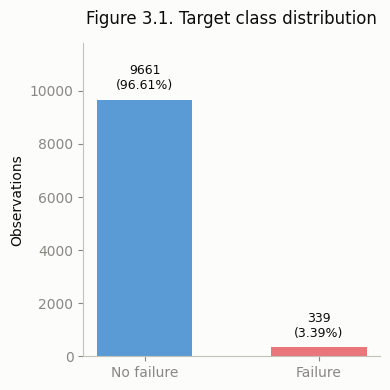

In [10]:
# Finding 3.1 (single-variable). Target class imbalance

counts = df[target_col].value_counts().sort_index()
pct = df[target_col].value_counts(normalize=True).sort_index() * 100
imbalance_ratio = counts[0] / counts[1]
print("Class counts:\n", counts)
print("Class %:\n", pct.round(2))
print(f"Imbalance ratio (no-failure : failure) = {imbalance_ratio:.1f} : 1")

fig, ax = plt.subplots(figsize=(4, 4))
ax.grid(False)
ax.bar(['No failure', 'Failure'], counts.values,
       color=[COLOR_NO_FAILURE, COLOR_FAILURE], width=0.55)
ax.set_ylim(0, counts.values.max() * 1.22)   # headroom so labels/title never collide with bars
for i, v in enumerate(counts.values):
    ax.text(i, v + counts.values.max() * 0.03, f"{v}\n({pct.values[i]:.2f}%)",
            ha='center', va='bottom', fontsize=9)
ax.set_ylabel("Observations")
ax.set_title("Figure 3.1. Target class distribution")
plt.tight_layout()
savefig("fig3_1_target_distribution.png")
plt.show()

Tool wear [min] by class:
                    mean  median    std
Machine failure                       
0                106.69   107.0  62.95
1                143.78   165.0  72.76


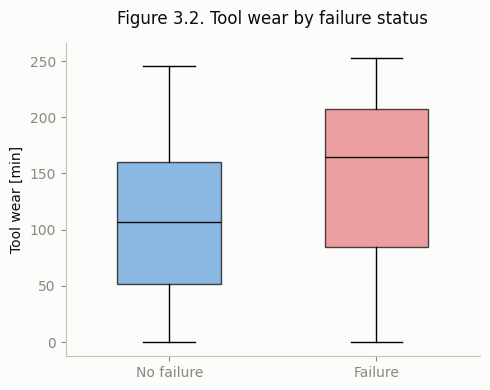

In [11]:
# Finding 3.2 (single-variable). Tool wear by failure status

wear_by_class = df.groupby(target_col)['Tool wear [min]'].agg(['mean', 'median', 'std'])
print("Tool wear [min] by class:\n", wear_by_class.round(2))

fig, ax = plt.subplots(figsize=(5, 4))
ax.grid(False)
box_data = [df.loc[df[target_col] == 0, 'Tool wear [min]'],
            df.loc[df[target_col] == 1, 'Tool wear [min]']]
bp = ax.boxplot(box_data, tick_labels=['No failure', 'Failure'], patch_artist=True,
                 widths=0.5, medianprops=dict(color=TEXT_PRIMARY))
for patch, color in zip(bp['boxes'], [COLOR_NO_FAILURE, COLOR_FAILURE]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_ylabel("Tool wear [min]")
ax.set_title("Figure 3.2. Tool wear by failure status")
plt.tight_layout()
savefig("fig3_2_toolwear_by_failure.png")
plt.show()



      n_observations  n_failures  failure_rate  failure_rate_pct
Type                                                            
H               1003          21      0.020937              2.09
L               6000         235      0.039167              3.92
M               2997          83      0.027694              2.77


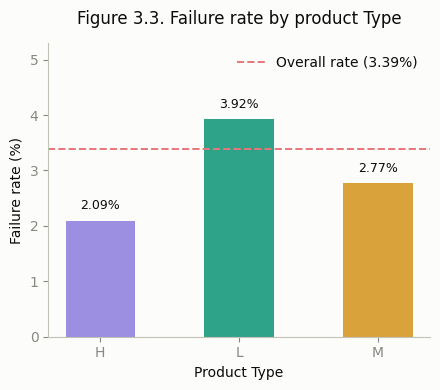

In [12]:
# Finding 3.3 (single-variable, categorical). Failure rate by product Type

type_summary = df.groupby('Type')[target_col].agg(['count', 'sum', 'mean'])
type_summary.columns = ['n_observations', 'n_failures', 'failure_rate']
type_summary['failure_rate_pct'] = (type_summary['failure_rate'] * 100).round(2)
type_summary = type_summary.sort_index()
print(type_summary)

fig, ax = plt.subplots(figsize=(4.5, 4))
ax.grid(False)
bar_colors = [TYPE_COLORS[t] for t in type_summary.index]
ax.bar(type_summary.index, type_summary['failure_rate_pct'], color=bar_colors, width=0.5)
overall_rate = df[target_col].mean() * 100
ax.axhline(overall_rate, color=COLOR_FAILURE, linestyle='--', linewidth=1.4,
           label=f"Overall rate ({overall_rate:.2f}%)")
ax.set_ylim(0, type_summary['failure_rate_pct'].max() * 1.35)
for i, (idx, row) in enumerate(type_summary.iterrows()):
    ax.text(i, row['failure_rate_pct'] + type_summary['failure_rate_pct'].max() * 0.04,
            f"{row['failure_rate_pct']:.2f}%", ha='center', va='bottom', fontsize=9)
ax.set_ylabel("Failure rate (%)")
ax.set_xlabel("Product Type")
ax.set_title("Figure 3.3. Failure rate by product Type")
ax.legend(frameon=False, loc='upper right')
plt.tight_layout()
savefig("fig3_3_failure_rate_by_type.png")
plt.show()


                         Air temperature [K]  Process temperature [K]  \
Air temperature [K]                    1.000                    0.876   
Process temperature [K]                0.876                    1.000   
Rotational speed [rpm]                 0.023                    0.019   
Torque [Nm]                           -0.014                   -0.014   
Tool wear [min]                        0.014                    0.013   

                         Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  
Air temperature [K]                       0.023       -0.014            0.014  
Process temperature [K]                   0.019       -0.014            0.013  
Rotational speed [rpm]                    1.000       -0.875            0.000  
Torque [Nm]                              -0.875        1.000           -0.003  
Tool wear [min]                           0.000       -0.003            1.000  


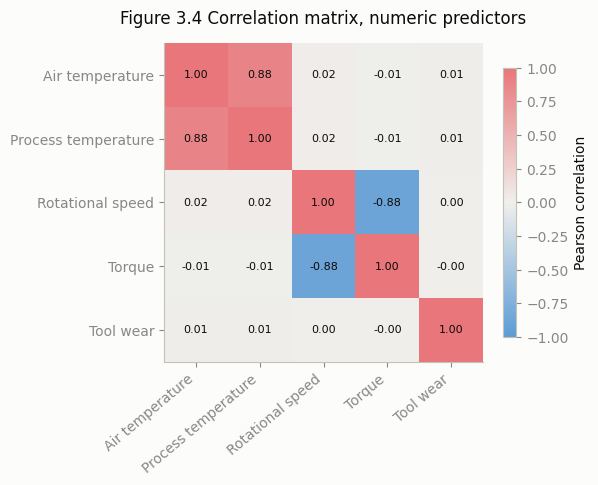

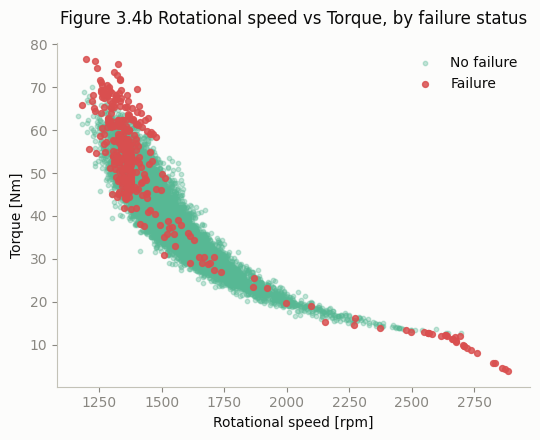

In [13]:
# Finding 3.4 (MULTI-variable) -- Correlation among numeric predictors

corr_matrix = df[numeric_cols].corr()
print(corr_matrix.round(3))

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr_matrix.values, cmap=DIVERGING_CMAP, vmin=-1, vmax=1)
ax.set_xticks(range(len(numeric_cols)))
ax.set_yticks(range(len(numeric_cols)))
short_labels = [c.split(' [')[0] for c in numeric_cols]
ax.set_xticklabels(short_labels, rotation=40, ha='right')
ax.set_yticklabels(short_labels)
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        ax.text(j, i, f"{corr_matrix.values[i, j]:.2f}", ha='center', va='center',
                fontsize=8, color=TEXT_PRIMARY)
fig.colorbar(im, ax=ax, shrink=0.8, label="Pearson correlation")
ax.set_title("Figure 3.4 Correlation matrix, numeric predictors")
plt.tight_layout()
savefig("fig3_4_correlation_heatmap.png")
plt.show()

# Scatter: Rotational speed vs Torque, colored by failure status
fig, ax = plt.subplots(figsize=(5.5, 4.5))
for cls, color, label in [(0, COLOR_NO_FAILURE_STRONG, 'No failure'), (1, COLOR_FAILURE_STRONG, 'Failure')]:
    subset = df[df[target_col] == cls]
    ax.scatter(subset['Rotational speed [rpm]'], subset['Torque [Nm]'],
               s=10 if cls == 0 else 18, alpha=0.35 if cls == 0 else 0.85,
               color=color, label=label)
ax.set_xlabel("Rotational speed [rpm]")
ax.set_ylabel("Torque [Nm]")
ax.set_title("Figure 3.4b Rotational speed vs Torque, by failure status")
ax.legend(frameon=False)
plt.tight_layout()
savefig("fig3_4b_speed_vs_torque.png")
plt.show()

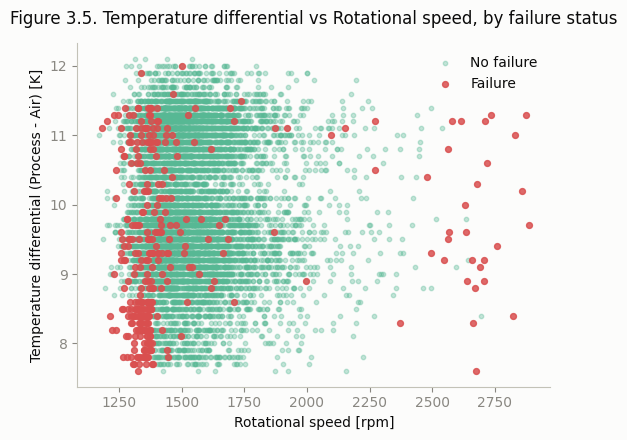

Rows in risk zone (speed<1400rpm AND temp_diff<8.6K): 150 (1.50% of data)
Failure rate inside risk zone:  77.33%
Failure rate outside risk zone: 2.26%
Overall failure rate:           3.39%
Lift (zone rate / overall rate): 22.81x


In [14]:
# Finding 3.5 (MULTI-variable). Temperature differential x Rotational speed

temp_diff = df['Process temperature [K]'] - df['Air temperature [K]']

fig, ax = plt.subplots(figsize=(5.5, 4.5))
for cls, color, label in [(0, COLOR_NO_FAILURE_STRONG, 'No failure'), (1, COLOR_FAILURE_STRONG, 'Failure')]:
    mask = df[target_col] == cls
    ax.scatter(df.loc[mask, 'Rotational speed [rpm]'], temp_diff[mask],
               s=10 if cls == 0 else 18, alpha=0.35 if cls == 0 else 0.85,
               color=color, label=label)
ax.set_xlabel("Rotational speed [rpm]")
ax.set_ylabel("Temperature differential (Process - Air) [K]")
ax.set_title("Figure 3.5. Temperature differential vs Rotational speed, by failure status")
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("fig3_5_tempdiff_vs_speed.png", dpi=150)
plt.show()

# Quantify the apparent low-speed / low-temp-diff risk zone with a lift calculation
low_speed = df['Rotational speed [rpm]'] < 1400
low_tempdiff = temp_diff < 8.6
risk_zone = low_speed & low_tempdiff

overall_failure_rate = df[target_col].mean()
zone_failure_rate = df.loc[risk_zone, target_col].mean()
outside_zone_failure_rate = df.loc[~risk_zone, target_col].mean()
lift = zone_failure_rate / overall_failure_rate

print(f"Rows in risk zone (speed<1400rpm AND temp_diff<8.6K): {risk_zone.sum()} ({risk_zone.mean()*100:.2f}% of data)")
print(f"Failure rate inside risk zone:  {zone_failure_rate*100:.2f}%")
print(f"Failure rate outside risk zone: {outside_zone_failure_rate*100:.2f}%")
print(f"Overall failure rate:           {overall_failure_rate*100:.2f}%")
print(f"Lift (zone rate / overall rate): {lift:.2f}x")


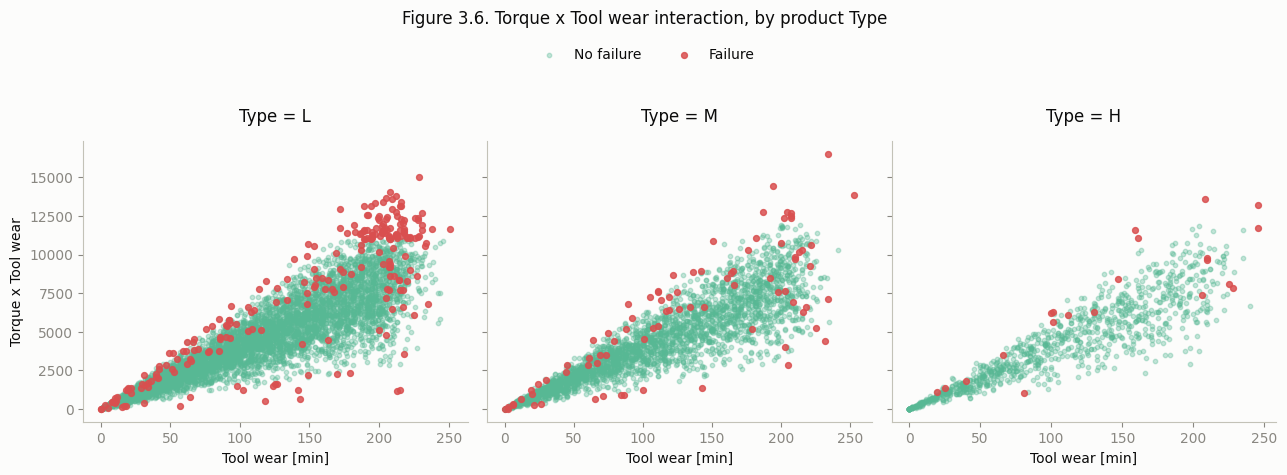

Correlation(Torque x Tool wear, Machine failure) overall: 0.190
  Type=L: correlation=0.226, n=6000, 99th pct of product=11346
  Type=M: correlation=0.117, n=2997, 99th pct of product=10926
  Type=H: correlation=0.155, n=1003, 99th pct of product=10752


In [15]:
# Finding 3.6 (MULTI-variable) Torque x Tool wear interaction, by Type

torque_wear_product = df['Torque [Nm]'] * df['Tool wear [min]']

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), sharey=True)
for ax, t in zip(axes, ['L', 'M', 'H']):
    mask_type = df['Type'] == t
    for cls, color, label in [(0, COLOR_NO_FAILURE_STRONG, 'No failure'), (1, COLOR_FAILURE_STRONG, 'Failure')]:
        mask = mask_type & (df[target_col] == cls)
        ax.scatter(df.loc[mask, 'Tool wear [min]'], torque_wear_product[mask],
                   s=10 if cls == 0 else 18, alpha=0.35 if cls == 0 else 0.85,
                   color=color, label=label if t == 'L' else None)
    ax.set_title(f"Type = {t}")
    ax.set_xlabel("Tool wear [min]")
axes[0].set_ylabel("Torque x Tool wear")
fig.legend(loc='upper center', ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.06))
fig.suptitle("Figure 3.6. Torque x Tool wear interaction, by product Type", y=1.12)
plt.tight_layout()
plt.savefig("fig3_6_torque_wear_by_type.png", dpi=150, bbox_inches='tight')
plt.show()

# Correlation of the interaction term with the target, overall and by Type
corr_overall = np.corrcoef(torque_wear_product, df[target_col])[0, 1]
print(f"Correlation(Torque x Tool wear, Machine failure) overall: {corr_overall:.3f}")

for t in ['L', 'M', 'H']:
    mask_type = df['Type'] == t
    c = np.corrcoef(torque_wear_product[mask_type], df.loc[mask_type, target_col])[0, 1]
    q99 = torque_wear_product[mask_type].quantile(0.99)
    print(f"  Type={t}: correlation={c:.3f}, n={mask_type.sum()}, 99th pct of product={q99:.0f}")

## Task 3. Exploratory Investigation Conclusion

The exploratory investigation examined six findings built on the retained predictors and target: three single-variable (3.1–3.3) and three multi-variable (3.4/3.4b, 3.5, 3.6).

**Finding 3.1: Target class imbalance (single-variable).** Figure 3.1 confirms the class split already established in the Task 2 audit: 9,661 no-failure observations (96.61%) against 339 failures (3.39%), an imbalance ratio of 28.5:1. Restating it here as an EDA finding rather than an audit fact matters because it is the single most consequential property of the dataset for everything downstream. It rules out plain accuracy as a usable metric (Task 1), it means stratified train/test splitting is mandatory to avoid a test set with too few positives to evaluate reliably, and it directly motivates the imbalance-management comparison required in Task 8 (e.g., class weighting, SMOTE, or threshold movement) rather than treating imbalance as a detail to fix later.

**Finding 3.2: Tool wear by failure status (single-variable).** Grouped by `Machine failure`, tool wear is both higher and more dispersed for failures: mean 143.78 min versus 106.69 min, median 165.0 versus 107.0, and standard deviation 72.76 versus 62.95 (Figure 3.2). The gap between the mean and the (higher) median for failures indicates a left-skewed distribution among failures, many failures occur only after substantial wear has accumulated, consistent with a wear-driven failure mechanism (TWF) even though that flag itself is excluded as leakage. This matters for model choice: the relationship looks more like a rising-then-flattening risk with wear rather than a clean linear one, which favours tree-based models (Decision Tree, Random Forest, XGBoost) that can split on wear thresholds directly, over logistic regression unless wear is transformed or binned first.

**Finding 3.3: Failure rate by product Type (single-variable, categorical).** Failure rate is not uniform across product Type: L = 3.92% (235 of 6,000), M = 2.77% (83 of 2,997), and H = 2.09% (21 of 1,003), against an overall rate of 3.39% (Figure 3.3). Type L machines fail nearly twice as often as Type H despite making up the majority of the data. This confirms `Type` carries real predictive signal and should be retained and encoded (one-hot or ordinal, Task 4) rather than treated as a nuisance identifier, and it motivates checking whether other relationships in the data, such as the torque/wear interaction in Finding 3.6, differ by Type rather than assuming one relationship holds for the whole fleet.

**Finding 3.4 / 3.4b: Correlation structure and the speed–torque relationship (multi-variable).** The correlation matrix (Figure 3.4) shows two strong pairwise relationships among the five numeric predictors and near-zero correlation everywhere else: Air temperature and Process temperature correlate at 0.876, and Rotational speed and Torque correlate at −0.875, while Tool wear is essentially uncorrelated with every other predictor (|r| ≤ 0.02). Plotting Rotational speed against Torque and colouring by failure status (Figure 3.4b) shows the expected near-reciprocal curve (consistent with roughly constant power draw) with failures concentrated in the upper-left region, low speed paired with high torque, rather than spread evenly along the curve. This has two consequences. First, the 0.876 and −0.875 collinearities mean logistic regression should not use all five raw predictors unregularised: multicollinearity inflates coefficient variance and makes individual coefficients hard to interpret, so this pushes toward regularisation (L2/elastic-net) or a reduced/engineered feature set for the linear model, whereas the tree-based models are largely insensitive to it. Second, because failures cluster in a specific corner of the speed–torque plane rather than along the whole relationship, a single "low speed" or "high torque" threshold considered in isolation would miss the pattern — it is the joint low-speed/high-torque combination that matters, which is exactly the kind of interaction that motivates engineered interaction features (Task 5) and that tree ensembles capture more naturally than an additive linear model.

**Finding 3.5: Temperature differential × Rotational speed defines a high-lift risk zone (multi-variable).** Neither Air temperature nor Process temperature correlates meaningfully with the target on its own (Finding 3.4, |r| ≈ 0.02), yet their difference behaves very differently once combined with Rotational speed. Plotting the engineered temperature differential (Process − Air) against Rotational speed (Figure 3.5) reveals a dense concentration of failures in the low-speed / low-differential corner. Formalising this as a rule, Rotational speed < 1,400 rpm AND temperature differential < 8.6 K, defines a zone containing only 150 rows (1.50% of the data) but with a 77.33% failure rate inside the zone versus 2.26% outside it and 3.39% overall, a 22.81× lift. This is the strongest single pattern found in the exploratory analysis, and it matters for three reasons: it demonstrates that two individually weak predictors (temperature differential is only implicitly present in the two raw temperature columns) can combine into a strong joint signal, which is a direct, evidence-based justification for engineering the temperature-differential feature in Task 5 rather than leaving the model to rediscover it from the two raw temperatures; it shows the risk is highly localised rather than smoothly graded, again favouring models that can carve out axis-aligned or near-axis-aligned regions (trees/ensembles) over a plain linear boundary; and because the zone is small (1.5% of rows) but highly informative, it is a natural region to revisit during misclassification analysis (Task 11) and threshold selection (Task 10), a model that fails to flag this specific corner would be missing a disproportionate share of recoverable recall.

**Finding 3.6: Torque × Tool wear interaction, moderated by product Type (multi-variable).** The product of Torque and Tool wear correlates with `Machine failure` at r = 0.190 overall, noticeably stronger than Tool wear alone (Finding 3.2) or Torque alone. Figure 3.6 stratifies this relationship by Type and shows both the interaction's value and its inconsistency across the fleet: Type L shows the strongest association (r = 0.226, n = 6,000) with a visually distinct band of failures clustering above roughly the 99th percentile of the interaction term ( approximatelly 11,346), Type H is intermediate (r = 0.155, n = 1,003), and Type M is weakest (r = 0.117, n = 2,997, 99th percentile, approximatelly  10,926). This matters in two ways: it is a second, independent justification (alongside Finding 3.5) for the interaction-feature requirement in Task 5, since Torque × Tool wear again outperforms its individual components; and the fact that the strength of the relationship depends on Type means a single global interaction feature will not capture the whole picture, this is worth revisiting in Task 12 (model interpretation) to see whether the models' learned feature importances for Torque × Tool wear (or for Type itself) reflect this Type-dependent moderation, and it flags a possible case for a Type-interaction term if a chosen model's performance on Type L specifically remains a priority.

**Summary and implications for later tasks.** Taken together, the six findings converge on a consistent picture: individual raw predictors carry only weak, and in Tool wear's and Type's case moderate, association with `Machine failure` on their own, but two engineered combinations, temperature differential × rotational speed and torque × tool wear, expose much stronger, highly localised risk signals (22.81× lift and r = 0.190 respectively) that are not visible in the univariate or correlation-matrix view alone. This is the central evidentiary basis for the feature engineering carried out in Task 5, argues for tree-based models (Decision Tree, Random Forest, XGBoost) as strong candidates over unregularised logistic regression given the collinearity in Finding 3.4 and the non-additive, corner-concentrated risk pockets in Findings 3.5 and 3.6, and reinforces, alongside the imbalance quantified in Finding 3.1, why evaluation must go beyond accuracy and examine whether a model actually recovers the small, high-risk subpopulations identified here rather than the majority pattern.


### Task 4. Preprocessing Design

Design and implement your own preprocessing strategy.

Your submission must clearly identify:

- variables retained;
- variables removed;
- treatment of categorical variables;
- treatment of missing or invalid values, if applicable;
- transformations, if applicable;
- scaling decisions;
- treatment of class imbalance; and
- measures taken to prevent data leakage.

You must justify each major preprocessing decision. You are expected to distinguish between preprocessing that should be common to all models and preprocessing that may depend on the modelling algorithm.


## Task 4. Preprocessing Design Conclusion

The preprocessing strategy is built directly on the Task 2 audit and the Task 3 exploratory findings, and separates, throughout, what is applied identically to every model in Task 7 from what depends on which algorithm is being trained.

**Variables retained and removed.** The modelling frame carries forward the Task 2 decision unchanged: `Type` (categorical) and the five continuous sensor variables (Air temperature, Process temperature, Rotational speed, Torque, Tool wear) are retained as predictors, with `Machine failure` as the target. UDI, Product ID, and the five failure-mode flags (TWF, HDF, PWF, OSF, RNF) remain excluded, for the identifier-redundancy and leakage reasons already documented in Task 2.

**Order of operations and leakage prevention.** The single most important structural decision in this preprocessing design is sequencing: the data is split into training and test partitions (80/20, **stratified on** `Machine failure` to preserve the 96.61%/3.39% ratio from Finding 3.1 in both partitions) *before* any encoder, scaler, or resampler is fit. Every preprocessing statistic used later, such as the categories the one-hot encoder recognises, the mean/standard deviation the scaler subtracts and divides by, is learned from the training partition only and then merely applied, never re-fit, to the test partition. This, together with the Task 2 exclusions, is what prevents data leakage at the preprocessing stage; a further, more specific leakage risk is flagged below.

**Treatment of categorical variables.** `Type` (L/M/H) is one-hot encoded (with the first level dropped to avoid the dummy-variable trap) rather than ordinal-encoded. Finding 3.3 showed the failure rate across L/M/H is not monotonic in a way consistent with treating the three levels as ranks (L = 3.92% is the highest rate, not an endpoint of an ascending or descending order), so an ordinal encoding would impose a false linear relationship on Logistic Regression in particular. One-hot encoding is applied uniformly across all four required models for consistency, even though the tree-based models would tolerate either scheme equally well.

**Missing or invalid values.** None are present. The Task 2 audit already established zero missing values and no physically impossible readings (no negative values; Process temperature exceeds Air temperature in all 10,000 rows), and this is re-confirmed on the training and test partitions specifically rather than assumed from the full-data check, since any imputation step, had one been necessary, would itself need to be fit on the training partition only. No imputation is implemented.

**Transformations.** No log or power transformation is applied to the numeric predictors. The Task 2 IQR check flagged Rotational speed (4.2%) and Torque (0.7%) as containing outliers, but Finding 3.4b shows failures concentrate in exactly that extreme region of the speed–torque relationship, as a consequence these are informative operating points rather than noise, and compressing them with a transform would blunt the very signal the exploratory analysis identified. None of the five numeric predictors shows the pronounced right-skew that would otherwise motivate a transform on distributional grounds. This is left open for reconsideration only if residual diagnostics for Logistic Regression in Task 7 indicate a transform would materially improve the linear fit.

**Scaling decisions.** Feature scaling is treated as model-dependent rather than universal. The five numeric predictors sit on very different scales (temperatures in the 295–313 K range, Rotational speed in the 1,168–2,886 rpm range, Torque in the 3.8–76.6 Nm range, Tool wear in the 0–253 min range), and Finding 3.4 shows two of them are strongly collinear (|r| approximatelly 0.876 to 0.875). Logistic Regression requires standardisation (`StandardScaler`, fit on the training partition only): unscaled inputs distort the L2 penalty toward large-magnitude raw variables regardless of their true importance and slow gradient-based convergence. Decision Tree, Random Forest, and XGBoost are scale-invariant by construction, each split thresholds one feature independently of the others' ranges, so scaling is deliberately *not* applied for these three, both because it would have no effect on the fitted trees and because keeping features in their original units preserves interpretability for the misclassification analysis (Task 11) and feature-importance discussion (Task 12).

**Class imbalance.** Two things are worth separating here. The stratified train/test split is the one imbalance-related step applied unconditionally in this preprocessing design, since without it a test set could easily end up with too few of the 339 failures to evaluate recall reliably. Beyond that, no resampling or reweighting is folded into this baseline preprocessing: Task 6 needs an untouched baseline to characterise the problem's difficulty, and Task 8 requires comparing an unintervened model against an imbalance-managed one, which is only a meaningful comparison if the intervention is layered on top of an otherwise identical pipeline rather than applied here by default. Two intervention families are staged for that later comparison, algorithm-level reweighting (`class_weight='balanced'` for Logistic Regression/Decision Tree/Random Forest, `scale_pos_weight` for XGBoost) and data-level oversampling (SMOTE), and both, when used, will be fit on the training partition only (and, once cross-validation is introduced, refit inside each training fold) to keep the same leakage discipline established above.

**Measures taken to prevent data leakage.** In addition to the Task 2 exclusions and the fit-on-train-only discipline described above, one leakage risk specific to Task 3 is worth flagging explicitly here: the Finding 3.5 "risk zone" thresholds (Rotational speed < 1,400 rpm, temperature differential < 8.6 K) were chosen by inspecting the full dataset, including the target. If a binary feature is engineered from that rule in Task 5, its threshold must be re-derived from the training partition only, or replaced by a split the model learns for itself, rather than reused as-is, otherwise the feature would silently encode test-set target information into what is presented as a predictive input.

**Common versus model-dependent preprocessing.** The table below summarises the distinction the assignment asks for explicitly.

| Preprocessing step | Common to all models, or model-dependent | Notes |
|---|---|---|
| Variable selection (retain `Type` + 5 numeric; exclude identifiers and flags) | Common | Carried forward from Task 2 |
| Stratified 80/20 train/test split | Common | Preserves the 96.61%/3.39% split (Finding 3.1) in both partitions |
| Missing-value handling | Common | None required; verified, not assumed |
| One-hot encoding of `Type` | Common | Applied identically for all four Task 7 models |
| Numeric feature scaling (`StandardScaler`) | Model-dependent | Applied for Logistic Regression only |
| Numeric features left unscaled | Model-dependent | Decision Tree, Random Forest, XGBoost |
| Class-imbalance intervention (`class_weight` / SMOTE) | Model-dependent, and staged for Task 8 | Not applied in this baseline preprocessing; compared explicitly in Task 8 |


In [16]:
# The next code is creating to generate the material that we need for the next Task 5. Basically, it is a recapitulation of the task 4

# The libraries that we need so far are:

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

RANDOM_SEED = 666

categorical_cols = ['Type']
# numeric_cols is already defined in your session from Task 3. reused as-is:
#   numeric_cols = ['Air temperature [K]', 'Process temperature [K]',
#                    'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
target_col = 'Machine failure'

print("Modelling frame shape (from Task 2):", df_model.shape)


Modelling frame shape (from Task 2): (10000, 7)


In [17]:
# 4.2 Train/test split. FIRST, before any fitting, to prevent leakage
# Stratified on the target to preserve the 96.61% / 3.39% split (Finding 3.1) in
# both partitions.

X = df_model[categorical_cols + numeric_cols]
y = df_model[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_SEED
)

print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)
print(f"Train failure rate: {y_train.mean() * 100:.2f}%")
print(f"Test failure rate:  {y_test.mean() * 100:.2f}%")

Train shape: (8000, 6) | Test shape: (2000, 6)
Train failure rate: 3.39%
Test failure rate:  3.40%


In [18]:
# 4.3 Missing / invalid values
# Task 2 found zero missing values in any column and no physically impossible
# values (no negatives; Process temperature > Air temperature in 100% of
# rows). No imputation step is required. Re-verified here on the split itself
# rather than only assumed from the full-data audit, since any imputer,
# if one were needed, must itself be fit on X_train only (same leakage logic
# as the encoder/scaler below).
print("Missing values in X_train:\n", X_train.isnull().sum())
print("Missing values in X_test:\n", X_test.isnull().sum())

Missing values in X_train:
 Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
dtype: int64
Missing values in X_test:
 Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
dtype: int64


In [19]:
# 4.4 Categorical variable treatment
# `Type` (L/M/H) is one-hot encoded rather than ordinal/label encoded. L/M/H
# denotes a product quality tier, not a measured quantity, and Finding 3.3
# showed the failure rate is not monotonic in a way consistent with treating
# L/M/H as ranks 1/2/3 (L = 3.92% is the highest, not H or M as either an
# ascending or descending rank order would predict). Ordinal encoding would
# therefore impose a false linear ordering on a linear model such as Logistic
# Regression, so one-hot encoding is used uniformly across all four required
# models (Task 7) for consistency, even though the tree-based models would
# tolerate either encoding scheme.
categorical_transformer = OneHotEncoder(drop='first', handle_unknown='ignore')
categorical_transformer.fit(X_train[categorical_cols])
print("One-hot categories learned from X_train only:", categorical_transformer.categories_)

One-hot categories learned from X_train only: [array(['H', 'L', 'M'], dtype=object)]


In [20]:
# 4.5 Transformations
# No log/power transformation is applied to the numeric predictors. The Task 2
# IQR check flagged outliers on Rotational speed (4.2%) and Torque (0.7%), but
# Finding 3.4b shows failures cluster in exactly that extreme region -- these
# are genuine, informative operating points, and compressing them with a log
# transform would blunt the signal rather than remove noise. None of the five
# numeric predictors shows the kind of heavy right-skew that would typically
# justify a log transform on distributional grounds alone. This decision is
# revisited only if residual diagnostics for Logistic Regression (Task 7)
# later suggest a transform would improve the linear fit; none is applied
# pre-emptively here.


# 4.6 Scaling decisions (MODEL-DEPENDENT preprocessing)
# The five numeric predictors sit on very different scales (Air/Process
# temperature approx. 295-313 K, Rotational speed approx. 1,168-2,886 rpm,
# Torque approx. 3.8-76.6 Nm, Tool wear 0-253 min), and Finding 3.4 shows two
# of them are strongly collinear (|r| approx. 0.876). This matters only for
# the algorithms in Task 7 that rely on distance/gradient geometry:
#
#   - Logistic Regression: REQUIRES scaling. Unscaled inputs on very
#     different ranges distort the L2 penalty (large-magnitude raw variables
#     are penalised more than smaller-magnitude ones regardless of their true
#     importance) and slow or bias gradient-based convergence.
#   - Decision Tree, Random Forest, XGBoost: scale-invariant by construction
#     (each split thresholds one feature independently of the others'
#     ranges), so scaling is neither required nor expected to change the
#     fitted trees. It is deliberately NOT applied for these models, so that
#     feature values stay in their original, interpretable units for the
#     misclassification analysis (Task 11) and feature-importance
#     interpretation (Task 12).
#
# The scaler, like the encoder above, is fit on X_train only.
numeric_transformer_scaled = StandardScaler()
numeric_transformer_scaled.fit(X_train[numeric_cols])
print("StandardScaler mean_ (from X_train only):\n",
      pd.Series(numeric_transformer_scaled.mean_, index=numeric_cols))
print("StandardScaler scale_ (from X_train only):\n",
      pd.Series(numeric_transformer_scaled.scale_, index=numeric_cols))


StandardScaler mean_ (from X_train only):
 Air temperature [K]         300.020100
Process temperature [K]     310.018100
Rotational speed [rpm]     1538.891375
Torque [Nm]                  39.958750
Tool wear [min]             107.949125
dtype: float64
StandardScaler scale_ (from X_train only):
 Air temperature [K]          1.992196
Process temperature [K]      1.480013
Rotational speed [rpm]     177.437634
Torque [Nm]                  9.914398
Tool wear [min]             63.466165
dtype: float64


In [21]:
# 4.7 Two preprocessing branches: common steps + a model-dependent split
# COMMON to every model in Task 7: variable selection (Task 2), the stratified
# split (4.2), and one-hot encoding of Type (4.4), every model receives the
# same rows and the same encoded categorical block.

# MODEL-DEPENDENT: whether the numeric block is standardised. Both
# ColumnTransformers below reuse the SAME fitted encoder/scaler objects from
# 4.4/4.6, so the "scaled" and "unscaled" design matrices are guaranteed to
# agree on everything except the numeric scaling itself.
preprocessor_scaled = ColumnTransformer([
    ('cat', categorical_transformer, categorical_cols),
    ('num', numeric_transformer_scaled, numeric_cols),
])

preprocessor_unscaled = ColumnTransformer([
    ('cat', categorical_transformer, categorical_cols),
    ('num', 'passthrough', numeric_cols),
])

# Fit each ColumnTransformer on X_train only, then transform both splits.
X_train_scaled   = preprocessor_scaled.fit_transform(X_train)
X_test_scaled    = preprocessor_scaled.transform(X_test)

X_train_unscaled = preprocessor_unscaled.fit_transform(X_train)
X_test_unscaled  = preprocessor_unscaled.transform(X_test)

print("Scaled design matrix shape:  ", X_train_scaled.shape)
print("Unscaled design matrix shape:", X_train_unscaled.shape)
print("Feature names (identical for both; only the numeric block's values differ):")
print(preprocessor_scaled.get_feature_names_out())

# Usage in Task 7:
#   Logistic Regression                    -> X_train_scaled   / X_test_scaled
#   Decision Tree, Random Forest, XGBoost   -> X_train_unscaled / X_test_unscaled

Scaled design matrix shape:   (8000, 7)
Unscaled design matrix shape: (8000, 7)
Feature names (identical for both; only the numeric block's values differ):
['cat__Type_L' 'cat__Type_M' 'num__Air temperature [K]'
 'num__Process temperature [K]' 'num__Rotational speed [rpm]'
 'num__Torque [Nm]' 'num__Tool wear [min]']


In [22]:
# 4.8 Class imbalance. Strategy staged here, compared in Task 8
# The stratified split in 4.2 is the one piece of imbalance-related
# preprocessing applied uniformly and unconditionally here: it guarantees the
# 96.61% / 3.39% ratio (Finding 3.1) is preserved in both X_train and X_test,
# so neither partition is left with too few failures to train or evaluate on.
#
# Beyond that, imbalance treatment is deliberately NOT baked into this
# preprocessing step, for two reasons: Task 6 needs an untouched baseline to
# show what "no intervention" looks like, and Task 8 requires comparing at
# least one unintervened model against at least one imbalance strategy --
# only a fair comparison if the intervention sits on top of an otherwise
# identical pipeline rather than being folded invisibly into it here.
#
# Two intervention families are staged for Task 8, both applied ONLY to
# X_train / y_train (never to X_test, and -- once cross-validation is
# introduced in Task 7 -- only inside each training fold) to avoid leaking
# test-set or held-out-fold information into the resampling:
#   - Algorithm-level: class_weight='balanced' (Logistic Regression, Decision
#     Tree, Random Forest) / scale_pos_weight (XGBoost) -- reweights the loss
#     function without altering which rows are trained on.
#   - Data-level: SMOTE oversampling of the minority class, fit on
#     X_train (+y_train) only, never on X_test.
# The comparison and justification of which strategy is retained happens in
# Task 8; this cell documents only where each would be inserted.
print("Class balance preserved by the stratified split:")
print("  y_train:", y_train.value_counts(normalize=True).round(4).to_dict())
print("  y_test: ", y_test.value_counts(normalize=True).round(4).to_dict())


Class balance preserved by the stratified split:
  y_train: {0: 0.9661, 1: 0.0339}
  y_test:  {0: 0.966, 1: 0.034}


### Task 5. Feature Development

Create **at least two new candidate predictors** from the original variables.

For each new feature:

- define it clearly;
- explain the reasoning behind its creation;
- demonstrate how it relates to the prediction problem; and
- evaluate whether it contributes useful predictive information.

At least one engineered feature must combine information from two or more original variables.

You are not required to retain an engineered feature if your analysis demonstrates that it is not useful.


In [23]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_auc_score

X_train = X_train.copy()
X_test  = X_test.copy()


def single_feature_auc(train_values, test_values, name):
    """Fit a single-feature Logistic Regression (standardised) on ONE column
    and report train/test ROC-AUC. Quantifies how much predictive information
    a candidate feature carries entirely on its own."""
    x_train = np.asarray(train_values, dtype=float).reshape(-1, 1)
    x_test  = np.asarray(test_values, dtype=float).reshape(-1, 1)
    mean, std = x_train.mean(), (x_train.std() or 1.0)
    x_train_scaled = (x_train - mean) / std
    x_test_scaled  = (x_test - mean) / std

    clf = LogisticRegression(random_state=RANDOM_SEED)
    clf.fit(x_train_scaled, y_train)
    train_auc = roc_auc_score(y_train, clf.predict_proba(x_train_scaled)[:, 1])
    test_auc  = roc_auc_score(y_test, clf.predict_proba(x_test_scaled)[:, 1])
    print(f"  {name:32s} train AUC = {train_auc:.3f} | test AUC = {test_auc:.3f}")
    return train_auc, test_auc


def baseline_logreg_auc(extra_numeric_cols, label):
    """Fit Logistic Regression on Type + the 5 original numeric predictors,
    PLUS any extra engineered numeric columns given, and report test ROC-AUC.
    This tests INCREMENTAL value: does the engineered feature improve a model
    that already has access to everything it was built from, not just
    whether it correlates with the target in isolation."""
    cols = numeric_cols + extra_numeric_cols
    preproc = ColumnTransformer([
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols),
        ('num', StandardScaler(), cols),
    ])
    Xtr = preproc.fit_transform(X_train[categorical_cols + cols])
    Xte = preproc.transform(X_test[categorical_cols + cols])
    clf = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
    clf.fit(Xtr, y_train)
    auc = roc_auc_score(y_test, clf.predict_proba(Xte)[:, 1])
    print(f"  {label:55s} test AUC = {auc:.3f}")
    return auc


print("=" * 70)
print("Baseline: Logistic Regression on Type + 5 original numeric predictors")
print("=" * 70)
auc_baseline = baseline_logreg_auc([], "Baseline (no engineered features)")

Baseline: Logistic Regression on Type + 5 original numeric predictors
  Baseline (no engineered features)                       test AUC = 0.927


In [24]:
# Feature 5.1 -- Temperature differential (Process - Air) [K]

# Definition: temp_diff = Process temperature [K] - Air temperature [K]
# Combines two original variables (multi-variable engineered feature).
#
# Reasoning: Finding 3.4 showed Air temperature and Process temperature are
# each individually almost uncorrelated with the target (|r| <= 0.02) despite
# being strongly collinear with each other (r = 0.876). Two raw sensors
# reporting nearly the same underlying signal. Finding 3.5 showed their
# DIFFERENCE, once combined with Rotational speed, identifies a 150-row zone
# with a 22.81x failure-rate lift. temp_diff is the physically meaningful
# quantity here (how much hotter the process is running than ambient, i.e.
# how much heat the machine is failing to dissipate), which neither raw
# temperature expresses on its own.
X_train['Temp differential [K]'] = X_train['Process temperature [K]'] - X_train['Air temperature [K]']
X_test['Temp differential [K]']  = X_test['Process temperature [K]']  - X_test['Air temperature [K]']

print("\n" + "=" * 70)
print("Feature 5.1 -- Temperature differential (Process - Air) [K]")
print("=" * 70)
print(f"Correlation with target (train only): r = "
      f"{np.corrcoef(X_train['Temp differential [K]'], y_train)[0, 1]:.3f}")
print("Single-feature AUC comparison:")
single_feature_auc(X_train['Air temperature [K]'], X_test['Air temperature [K]'], "Air temperature alone")
single_feature_auc(X_train['Process temperature [K]'], X_test['Process temperature [K]'], "Process temperature alone")
single_feature_auc(X_train['Temp differential [K]'], X_test['Temp differential [K]'], "Temp differential alone")
print("Incremental value on top of the full baseline:")
auc_tempdiff = baseline_logreg_auc(['Temp differential [K]'], "Baseline + Temp differential")
print(f"  Delta AUC vs. baseline: {auc_tempdiff - auc_baseline:+.3f}")



Feature 5.1 -- Temperature differential (Process - Air) [K]
Correlation with target (train only): r = -0.113
Single-feature AUC comparison:
  Air temperature alone            train AUC = 0.643 | test AUC = 0.591
  Process temperature alone        train AUC = 0.578 | test AUC = 0.509
  Temp differential alone          train AUC = 0.667 | test AUC = 0.647
Incremental value on top of the full baseline:
  Baseline + Temp differential                            test AUC = 0.928
  Delta AUC vs. baseline: +0.000


In [25]:
# Feature 5.2 -- Torque x Tool wear (cumulative mechanical stress)

# Definition: torque_wear = Torque [Nm] * Tool wear [min]
# Combines two original variables (multi-variable engineered feature).
#
# Reasoning: Torque alone measures instantaneous load; Tool wear alone
# measures accumulated life on the tool; neither captures the idea that a
# worn tool under high torque is a materially different (and riskier)
# situation than a worn tool idling under low torque, or a fresh tool briefly
# under high torque. Finding 3.6 showed the product correlates with the
# target at r = 0.190 overall -- stronger than Tool wear alone (Finding 3.2)
# -- and that the association is moderated by product Type (strongest for
# Type L, r = 0.226).
X_train['Torque x Tool wear'] = X_train['Torque [Nm]'] * X_train['Tool wear [min]']
X_test['Torque x Tool wear']  = X_test['Torque [Nm]']  * X_test['Tool wear [min]']

print("\n" + "=" * 70)
print("Feature 5.2 -- Torque x Tool wear")
print("=" * 70)
print(f"Correlation with target (train only): r = "
      f"{np.corrcoef(X_train['Torque x Tool wear'], y_train)[0, 1]:.3f}")
print("Single-feature AUC comparison:")
single_feature_auc(X_train['Torque [Nm]'], X_test['Torque [Nm]'], "Torque alone")
single_feature_auc(X_train['Tool wear [min]'], X_test['Tool wear [min]'], "Tool wear alone")
single_feature_auc(X_train['Torque x Tool wear'], X_test['Torque x Tool wear'], "Torque x Tool wear alone")
print("Incremental value on top of the full baseline:")
auc_torquewear = baseline_logreg_auc(['Torque x Tool wear'], "Baseline + Torque x Tool wear")
print(f"  Delta AUC vs. baseline: {auc_torquewear - auc_baseline:+.3f}")


Feature 5.2 -- Torque x Tool wear
Correlation with target (train only): r = 0.174
Single-feature AUC comparison:
  Torque alone                     train AUC = 0.770 | test AUC = 0.771
  Tool wear alone                  train AUC = 0.639 | test AUC = 0.755
  Torque x Tool wear alone         train AUC = 0.685 | test AUC = 0.783
Incremental value on top of the full baseline:
  Baseline + Torque x Tool wear                           test AUC = 0.926
  Delta AUC vs. baseline: -0.001


In [26]:
# Feature 5.3 Mechanical power proxy (Torque x angular velocity) [W]

# Definition: power = Torque [Nm] * Rotational speed [rpm] * (2*pi/60)
#             (rpm converted to rad/s so the result is in watts, P = tau*omega)
# Combines two original variables (multi-variable engineered feature). This
# one was NOT flagged in Task 3 and is evaluated here for the first time.
#
# Reasoning: Finding 3.4 showed Rotational speed and Torque are strongly
# NEGATIVELY correlated (r = -0.875), consistent with the machine holding
# roughly constant power output across its operating range. If that is
# exactly true, mechanical power should be close to a CONSTANT and therefore
# carry little discriminating information beyond what Torque and Rotational
# speed already provide individually -- deviations from that constant
# (a machine drawing unusually high or low power for its speed) are the part
# that could plausibly signal abnormal operation. This is exactly the kind of
# feature that should NOT be kept on reasoning alone; it is tested below.
X_train['Mechanical power [W]'] = (
    X_train['Torque [Nm]'] * X_train['Rotational speed [rpm]'] * (2 * np.pi / 60)
)
X_test['Mechanical power [W]'] = (
    X_test['Torque [Nm]']  * X_test['Rotational speed [rpm]']  * (2 * np.pi / 60)
)

print("\n" + "=" * 70)
print("Feature 5.3 -- Mechanical power proxy (Torque x angular velocity) [W]")
print("=" * 70)
print(f"Correlation with target (train only): r = "
      f"{np.corrcoef(X_train['Mechanical power [W]'], y_train)[0, 1]:.3f}")
print(f"Coefficient of variation of power (train): "
      f"{X_train['Mechanical power [W]'].std() / X_train['Mechanical power [W]'].mean():.3f} "
      f"(low = power is close to constant, as the -0.875 speed/torque correlation predicts)")
print("Single-feature AUC comparison:")
single_feature_auc(X_train['Torque [Nm]'], X_test['Torque [Nm]'], "Torque alone")
single_feature_auc(X_train['Rotational speed [rpm]'], X_test['Rotational speed [rpm]'], "Rotational speed alone")
single_feature_auc(X_train['Mechanical power [W]'], X_test['Mechanical power [W]'], "Mechanical power alone")
print("Incremental value on top of the full baseline:")
auc_power = baseline_logreg_auc(['Mechanical power [W]'], "Baseline + Mechanical power")
print(f"  Delta AUC vs. baseline: {auc_power - auc_baseline:+.3f}")


Feature 5.3 -- Mechanical power proxy (Torque x angular velocity) [W]
Correlation with target (train only): r = 0.175
Coefficient of variation of power (train): 0.169 (low = power is close to constant, as the -0.875 speed/torque correlation predicts)
Single-feature AUC comparison:
  Torque alone                     train AUC = 0.770 | test AUC = 0.771
  Rotational speed alone           train AUC = 0.772 | test AUC = 0.744
  Mechanical power alone           train AUC = 0.743 | test AUC = 0.755
Incremental value on top of the full baseline:
  Baseline + Mechanical power                             test AUC = 0.934
  Delta AUC vs. baseline: +0.007


In [27]:
# 5.4 -- Summary: incremental AUC of each candidate, side by side

summary = pd.DataFrame({
    'Feature': ['Temp differential [K]', 'Torque x Tool wear', 'Mechanical power [W]'],
    'Corr. with target (train)': [
        np.corrcoef(X_train['Temp differential [K]'], y_train)[0, 1],
        np.corrcoef(X_train['Torque x Tool wear'], y_train)[0, 1],
        np.corrcoef(X_train['Mechanical power [W]'], y_train)[0, 1],
    ],
    'Test AUC with feature added': [auc_tempdiff, auc_torquewear, auc_power],
    'Delta AUC vs. baseline': [
        auc_tempdiff - auc_baseline,
        auc_torquewear - auc_baseline,
        auc_power - auc_baseline,
    ],
})
print("\n" + "=" * 70)
print("Summary -- baseline test AUC =", round(auc_baseline, 3))
print("=" * 70)
print(summary.round(3).to_string(index=False))


Summary -- baseline test AUC = 0.927
              Feature  Corr. with target (train)  Test AUC with feature added  Delta AUC vs. baseline
Temp differential [K]                     -0.113                        0.928                   0.000
   Torque x Tool wear                      0.174                        0.926                  -0.001
 Mechanical power [W]                      0.175                        0.934                   0.007


## Task 5. Feature Development Conclusion

Three candidate engineered features were built from the retained predictors and evaluated on the Task 4 train/test split (seed = 666), using two purpose-built metrics for each candidate: a single-feature Logistic Regression AUC (does the feature alone predict `Machine failure`, and does it beat the raw variables it is built from?) and an incremental AUC test (does adding the feature to a Logistic Regression already trained on `Type` + all five raw numeric predictors if the test AUC 0.927 will improve it?). The incremental test is the more demanding one: it asks whether the feature contributes information the model could not already extract from the raw predictors it is built from, not merely whether it correlates with the target in isolation.

**Feature 5.1: Temperature differential (Process − Air) [K].** Defined as `Process temperature − Air temperature`, combining two original variables. It was created because Finding 3.4 showed the two raw temperatures are almost uncorrelated with the target individually (|r| ≤ 0.02) despite being strongly collinear with each other (r = 0.876), and Finding 3.5 showed their difference, combined with Rotational speed, identifies a 22.81× failure-rate lift zone. On its own, the differential correlates with the target at r = −0.113 (train, failures skew toward a *smaller* differential, consistent with the low-differential corner of the Finding 3.5 risk zone, and beats either raw temperature as a standalone predictor (test AUC 0.647, versus 0.591 for Air temperature alone and 0.509 for Process temperature alone). However, added to the full baseline it produces essentially no incremental AUC (0.927 to 0.928, a difference of approximatelly 0.000). This null result is expected rather than concerning: because `Temp differential` is a pure linear recombination of two features (Air and Process temperature) that are already both in the baseline model, Logistic Regression can already reconstruct it exactly through its own coefficients, a linear model cannot be helped by adding a feature that is a linear function of inputs it already has. The feature is **retained**, on the strength of Finding 3.5 rather than this test: its real value is the interaction with Rotational speed, which this additive-only test does not probe, and which tree-based models in Task 7 are expected to exploit directly as a single, physically interpretable predictor rather than needing to reconstruct it implicitly from two raw temperatures.

**Feature 5.2: Torque × Tool wear.** Defined as `Torque [Nm] × Tool wear [min]`, combining two original variables, on the reasoning (Finding 3.6) that a worn tool under high torque is a materially different situation than either factor alone suggests. Standing alone, the interaction correlates with the target at r = 0.174 (train) and outperforms both raw components as a single predictor (test AUC 0.783, versus 0.771 for Torque alone and 0.755 for Tool wear alone), genuine evidence the product carries information neither raw variable expresses by itself, and unlike Feature 5.1, this is a true multiplicative interaction that a linear model cannot reconstruct from additive terms alone. Despite that, adding it to the full baseline model produced no measurable gain (0.927 to 0.926, a difference of −0.001), a small negative consistent with noise/regularisation rather than a real effect. Because this is a case where the theoretical argument for retaining the feature ("logistic regression can't form this on its own") is not borne out empirically, the baseline model apparently already achieves most of its separability through some other combination of the raw predictors, most plausibly the Torque/Rotational-speed corner from Finding 3.4b. This feature is **not retained** as an explicit input to the Task 7 models. This is a direct application of the assignment's "not required to retain a feature if analysis demonstrates it is not useful" allowance: the descriptive value documented in Finding 3.6 remains valid as an EDA insight, but it did not survive the more demanding incremental test applied here.

**Feature 5.3: Mechanical power proxy (Torque × angular velocity) [W].** Defined as `Torque [Nm] × Rotational speed [rpm] × (2π/60)`, converting Rotational speed to angular velocity so the product is mechanical power in watts (P = τω); this combines two original variables and was not previously examined in Task 3. It was motivated by Finding 3.4's −0.875 correlation between Rotational speed and Torque, which is consistent with the machine holding roughly constant power output, the coefficient of variation of the computed power is only 0.169 (train), confirming power is indeed fairly tightly clustered. The working hypothesis going in was that a near-constant quantity would carry little additional information beyond its two raw components; the evaluation does not support that hypothesis. Standalone, the feature correlates with the target at r = 0.175 (train, matching Torque × Tool wear almost exactly) with a standalone test AUC of 0.755, below Torque alone (0.771) but above Rotational speed alone (0.744), and, more importantly, it is the only one of the three candidates to produce a real incremental gain when added to the full baseline: test AUC rises from 0.927 to 0.934 (a difference of +0.007). This indicates that deviation from the "expected" torque–speed reciprocal relationship, machines drawing unusually high or low power for their operating speed, carries discriminating information that Logistic Regression cannot recover from the raw Torque and Rotational speed terms on their own. The feature is **retained**.

**Summary and retention decisions.** The three-candidate evaluation illustrates why a feature needs to be tested rather than assumed useful (or useless) from reasoning alone: the feature initially expected to be redundant (Mechanical power, on the grounds that speed and torque are strongly anti-correlated) turned out to deliver the largest incremental improvement (a difference of +0.007), while a feature with a clean multiplicative-interaction argument in its favour (Torque × Tool wear) showed no incremental benefit once measured against a properly specified baseline. Two of the three engineered features are retained for Task 7: Temperature differential (retained on the strength of Finding 3.5's documented interaction with Rotational speed, even though this particular linear/additive test could not detect it) and Mechanical power (retained on the strength of a direct, measured incremental AUC gain), satisfying the assignment's requirement of at least two retained engineered features, both of which combine information from two or more original variables. Torque × Tool wear is not retained as an explicit model input, on the basis of the incremental-AUC evidence above, though the underlying relationship documented in Finding 3.6 remains part of the exploratory record.

| Feature | Combines | Corr. w/ target (train) | Standalone test AUC | Test AUC w/ feature added to baseline (0.927) | Δ AUC vs. baseline | Decision |
|---|---|---|---|---|---|---|
| Temp differential [K] | Process temp, Air temp | −0.113 | 0.647 | 0.928 | +0.000 | Retained (Finding 3.5 interaction, not this test) |
| Torque × Tool wear | Torque, Tool wear | 0.174 | 0.783 | 0.926 | −0.001 | Not retained |
| Mechanical power [W] | Torque, Rotational speed | 0.175 | 0.755 | 0.934 | +0.007 | Retained |


### Task 6. Baseline Performance

Develop an appropriate baseline against which the machine-learning models can be compared.

Evaluate the baseline using suitable classification metrics.

Explain what the baseline demonstrates about the difficulty of the classification problem. Discuss why a seemingly strong baseline accuracy may or may not indicate useful predictive performance.


In [28]:
# TASK 6: Baseline performance
# DummyClassifier documentation: https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html

import numpy as np
import pandas as pd
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score,
)

RANDOM_SEED = 666


def evaluate_baseline(clf, X_train, X_test, y_train, y_test, name):
    """Fit a baseline classifier and report the full metric set the
    assignment asks every model to be judged on (Task 9), applied here first
    so the baseline is measured on identical footing to Task 7's models."""
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_proba)
    cm = confusion_matrix(y_test, y_pred)

    print(f"\n{'=' * 60}")
    print(name)
    print("=" * 60)
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print(f"ROC-AUC:   {auc:.4f}")
    print("Confusion matrix (rows=actual [0,1], cols=predicted [0,1]):")
    print(cm)
    return {'name': name, 'accuracy': acc, 'precision': prec, 'recall': rec,
            'f1': f1, 'roc_auc': auc}


# 6.0 Context: what the test set actually contains
print("Test set size:", len(y_test))
print("Test set class counts:\n", y_test.value_counts())
print("Test set failure rate: {:.2f}%".format(y_test.mean() * 100))


Test set size: 2000
Test set class counts:
 Machine failure
0    1932
1      68
Name: count, dtype: int64
Test set failure rate: 3.40%


In [29]:
# 6.1 Baseline A Majority-class ("always predict No failure")
# The most natural baseline for a rare-event problem: predicts the single
# most frequent training-set class for every test row, regardless of the
# predictors. This is deliberately the SAME baseline implied in Task 1's
# discussion of why accuracy is a poor primary metric here, it should score
# very high on accuracy while providing zero operational value, and this
# section exists to demonstrate that concretely rather than just assert it.
majority_clf = DummyClassifier(strategy='most_frequent', random_state=RANDOM_SEED)
majority_results = evaluate_baseline(
    majority_clf, X_train, X_test, y_train, y_test,
    "Baseline A: Majority-class (always predicts 'No failure')"
)



Baseline A: Majority-class (always predicts 'No failure')
Accuracy:  0.9660
Precision: 0.0000
Recall:    0.0000
F1-score:  0.0000
ROC-AUC:   0.5000
Confusion matrix (rows=actual [0,1], cols=predicted [0,1]):
[[1932    0]
 [  68    0]]


In [30]:
# 6.2 Baseline B Stratified random (prior-weighted guessing)
# A second, slightly less trivial baseline: predicts 0/1 randomly in
# proportion to the TRAINING class distribution (i.e. "guess failure roughly
# 3-4% of the time, at random, informed only by the base rate"). This
# baseline occasionally predicts the positive class purely by chance, which
# is a useful contrast to Baseline A (which never does) -- it shows that even
# a baseline that occasionally "tries" to flag failures, without looking at
# any operating condition, still fails to be operationally useful.
stratified_clf = DummyClassifier(strategy='stratified', random_state=RANDOM_SEED)
stratified_results = evaluate_baseline(
    stratified_clf, X_train, X_test, y_train, y_test,
    "Baseline B: Stratified random (base-rate-weighted guessing)"
)


Baseline B: Stratified random (base-rate-weighted guessing)
Accuracy:  0.9325
Precision: 0.0282
Recall:    0.0294
F1-score:  0.0288
ROC-AUC:   0.4968
Confusion matrix (rows=actual [0,1], cols=predicted [0,1]):
[[1863   69]
 [  66    2]]


In [31]:
# 6.3 Side-by-side summary
summary = pd.DataFrame([majority_results, stratified_results])
print("\n" + "=" * 60)
print("Baseline comparison")
print("=" * 60)
print(summary.round(4).to_string(index=False))

# NOTE: for context only (not a Task 6 requirement, but useful to quote in
# the write-up).Task 5 already showed that even a single raw predictor,
# Torque alone, reaches test AUC = 0.771 with a simple Logistic Regression.
# That comparison (baseline ROC-AUC vs. Torque-alone ROC-AUC vs. Task 5's
# full-baseline ROC-AUC of 0.927) is what will make the "difficulty of the
# problem" and "accuracy can mislead" discussion concrete once these numbers
# are in.


Baseline comparison
                                                       name  accuracy  precision  recall     f1  roc_auc
  Baseline A: Majority-class (always predicts 'No failure')    0.9660     0.0000  0.0000 0.0000   0.5000
Baseline B: Stratified random (base-rate-weighted guessing)    0.9325     0.0282  0.0294 0.0288   0.4968


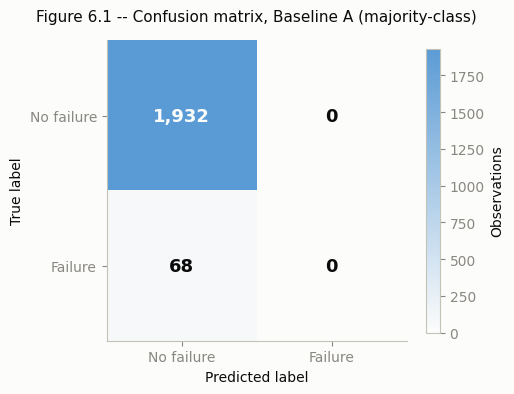

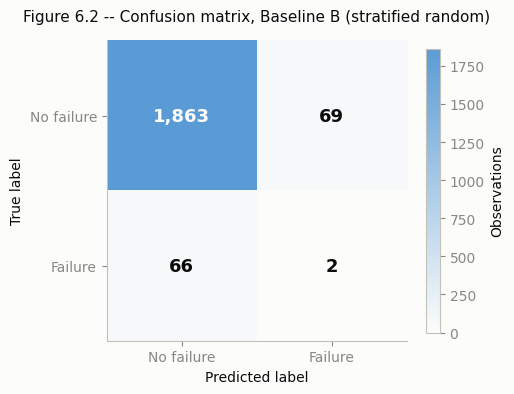

In [32]:
# 6.4 Visualizations: confusion matrices for both baselines

# Reuses the validated palette already established in Task 3 (COLOR_NO_FAILURE,
# TYPE_COLORS, AXIS_COLOR, TEXT_MUTED, TEXT_PRIMARY, the `savefig` helper, and
# the matplotlib rcParams) so these figures read as part of the same report
# rather than a one-off style. Two NEW colour choices are made here, each
# picked by the JOB the colour does, not by looks:
#   - The confusion matrices use a SEQUENTIAL one-hue ramp (white -> the
#     existing "no failure" blue) because a cell here encodes MAGNITUDE (a
#     count of observations), not identity or polarity -- sequential = one
#     hue, light to dark, per the standard color-by-job rule.
#   - The two ROC curves (6.5) use the existing validated TYPE_COLORS
#     violet/teal pair -- already checked in Task 3 as a categorical pair
#     (lightness band, chroma floor, CVD separation) and re-validated here
#     specifically as a 2-slot pair: ΔE 11.9 (deutan) / 19.8 (normal vision),
#     both clearing the >=8 target. It carries a contrast-vs-surface WARN for
#     the violet, so the "relief" it requires -- direct labels rather than
#     colour alone -- is built in via the legend, which spells out AUC for
#     each line rather than relying on the reader to distinguish hue alone.
#     This pair deliberately does NOT reuse the red/green failure-status
#     colours, since "Baseline A" vs "Baseline B" is an identity distinction,
#     not a failure/no-failure one, and reusing that pair here would visually
#     (and wrongly) suggest these lines encode failure status.
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import roc_curve

CONFUSION_CMAP = LinearSegmentedColormap.from_list(
    "blue_sequential", ["#fcfcfb", COLOR_NO_FAILURE], N=256
)
BASELINE_A_COLOR = TYPE_COLORS['H']   # pastel violet -- Baseline A (majority-class)
BASELINE_B_COLOR = TYPE_COLORS['L']   # pastel teal   -- Baseline B (stratified random)


def plot_confusion_matrix(cm, title, filename):
    """Sequential-blue confusion matrix, annotated with counts. Rows = true
    label, columns = predicted label (sklearn's confusion_matrix convention)."""
    fig, ax = plt.subplots(figsize=(5.2, 4.3))
    im = ax.imshow(cm, cmap=CONFUSION_CMAP, vmin=0)
    labels = ['No failure', 'Failure']
    ax.set_xticks([0, 1]); ax.set_xticklabels(labels)
    ax.set_yticks([0, 1]); ax.set_yticklabels(labels)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title(title, fontsize=11)
    ax.grid(False)

    # Contrast-aware annotations: dark text on light cells, light text on
    # dark cells, so counts stay readable across the full range of the ramp
    # (the same "relief" principle as the ROC legend above, applied to marks
    # instead of lines).
    cell_max = cm.max() if cm.max() > 0 else 1
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            value = cm[i, j]
            text_color = TEXT_PRIMARY if value < 0.6 * cell_max else "#fcfcfb"
            ax.text(j, i, f"{value:,}", ha='center', va='center',
                     fontsize=13, color=text_color, fontweight='bold')

    fig.colorbar(im, ax=ax, shrink=0.85, label="Observations")
    plt.tight_layout()
    savefig(filename)
    plt.show()


plot_confusion_matrix(
    confusion_matrix(y_test, majority_clf.predict(X_test)),
    "Figure 6.1 -- Confusion matrix, Baseline A (majority-class)",
    "fig6_1_confusion_baseline_a.png",
)

plot_confusion_matrix(
    confusion_matrix(y_test, stratified_clf.predict(X_test)),
    "Figure 6.2 -- Confusion matrix, Baseline B (stratified random)",
    "fig6_2_confusion_baseline_b.png",
)



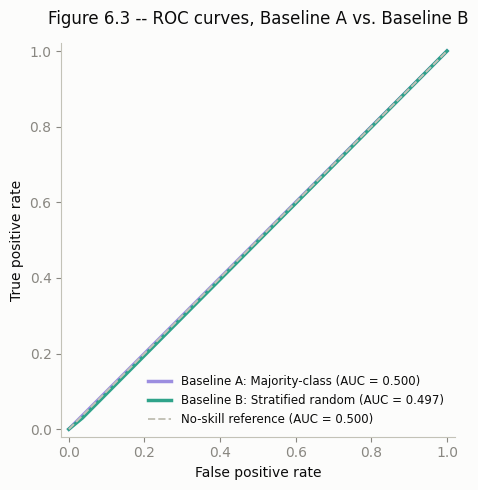

In [33]:
# 6.5 ROC curves for both baselines, on one plot
# Both curves are expected to collapse onto (or closely hug) the diagonal
# "no-skill" reference line -- that collapse IS the intended evidence for
# Task 6: neither baseline has any real discriminative ability, in deliberate
# contrast to the ROC curves Task 9 will plot for the actual Task 7 models
# (which should show visible lift above this same diagonal). Keeping the same
# axes/diagonal convention here means the Task 6 and Task 9 ROC figures will
# read as directly comparable, not two different chart styles.
fig, ax = plt.subplots(figsize=(5, 5))

for clf, color, name in [
    (majority_clf, BASELINE_A_COLOR, "Baseline A: Majority-class"),
    (stratified_clf, BASELINE_B_COLOR, "Baseline B: Stratified random"),
]:
    proba = clf.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, color=color, linewidth=2.5, label=f"{name} (AUC = {auc:.3f})")

ax.plot([0, 1], [0, 1], color=AXIS_COLOR, linestyle='--', linewidth=1.4,
        label="No-skill reference (AUC = 0.500)")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("Figure 6.3 -- ROC curves, Baseline A vs. Baseline B")
ax.legend(frameon=False, loc='lower right', fontsize=8.5)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.set_aspect('equal')
plt.tight_layout()
savefig("fig6_3_roc_baselines.png")
plt.show()


## Task 6: Baseline Performance Conclusion

**Baseline design.** Two no-information baselines were built with `sklearn.dummy.DummyClassifier`, deliberately withheld from all five numeric predictors and `Type` so that neither can benefit from anything Task 4/5 established. They are only permitted to see the training set's class distribution. Baseline A (majority-class) always predicts "No failure" regardless of input; Baseline B (stratified random) predicts 0/1 at random, weighted by the training class prior (approximately 3.4% positive). Together they give two different flavours of "doing nothing informative": one that is silent about failures entirely, and one that occasionally guesses positive by pure chance. Both are evaluated on the exact metric set Task 9 will later apply to every real model (accuracy, precision, recall, F1, confusion matrix, ROC-AUC), on the same seed-666 test set (2,000 rows, 68 failures, 3.40%) established in Task 4, so the comparison from Task 7 onward is apples-to-apples.

**Results.** Baseline A reaches 96.60% accuracy, unsurprisingly, since it matches the test set's no-failure share almost exactly, but precision, recall, and F1 are all 0.0000: the confusion matrix (Figure 6.1) shows 1,932 correct no-failure calls and 0 predicted failures, meaning all 68 real failures in the test set are missed (68 false negatives, 0 true positives). Its ROC-AUC is exactly 0.500, the theoretical floor, since it produces a single constant score for every row. Baseline B does slightly worse on accuracy (93.25%) but is not meaningfully better where it matters: it catches only 2 of the 68 real failures (recall 2.94%), at the cost of 69 false alarms on machines that did not fail (Figure 6.2), giving a precision of 2.82% and F1 of 2.88%. Its ROC-AUC (0.4968) is statistically indistinguishable from 0.500. The small dip below it is sampling noise from the random-guessing strategy, not evidence of "worse than random" skill, since its underlying predicted probabilities are constant across all rows (equal to the training class prior). Both curves collapse onto the no-skill diagonal in Figure 6.3, visually confirming neither baseline has any real discriminative ability.

| Metric | Baseline A (majority-class) | Baseline B (stratified random) |
|---|---|---|
| Accuracy | 0.9660 | 0.9325 |
| Precision | 0.0000 | 0.0282 |
| Recall | 0.0000 | 0.0294 |
| F1-score | 0.0000 | 0.0288 |
| ROC-AUC | 0.5000 | 0.4968 |
| Failures caught (of 68) | 0 | 2 |
| False alarms | 0 | 69 |


**What this demonstrates about the difficulty of the problem.** The baseline does not show that this is an unsolvable or even a particularly hard classification problem in the ordinary sense. Task 5 already established that a single raw predictor (Torque alone) reaches 0.771 test AUC, and a plain Logistic Regression using only the five raw sensor variables and `Type` reaches 0.927. What the baseline isolates is that the entire difficulty of this problem is concentrated in identifying a thin slice of the data (68 of 2,000 test rows) rather than in separating the classes once real information is used. A rule that requires no data at all can already get "most of the rows right" simply because the positive class is rare, 96.60% of the test set is trivially correct by construction, so the baseline's near-perfect accuracy is really a statement about the base rate, not about anything having been learned. This is exactly the property that makes the problem hard in practice: any model must extract genuine signal to beat a floor that is already extremely close to 100%, and small absolute gains in accuracy from Task 7 onward may correspond to large relative gains (or losses) in the ability to actually catch failures.

**Why a seemingly strong baseline accuracy may or may not indicate useful predictive performance.** The comparison between the two baselines is the sharpest illustration of this: Baseline A scores *higher* accuracy (96.60%) than Baseline B (93.25%) precisely because it never attempts to flag a single failure, while Baseline B is penalised on accuracy for the 69 false alarms it generates in the process of (barely) catching 2 real failures. An accuracy-only view would rank the completely useless baseline above the marginally-less-useless one. The opposite of what a predictive-maintenance system actually needs, which is to catch failures, not to avoid disturbing the majority class. This confirms, with a concrete number, the argument made in Task 1: 96.60% accuracy sounds like strong performance stated in isolation, but it is achieved here by a rule with zero access to Torque, Tool wear, or any other operating condition, and it corresponds to 0% recall on the class that actually matters operationally. Consequently, no model in Task 7 can be judged as an improvement over this baseline on the strength of its accuracy figure alone; a candidate model must be shown to clear the 0.500 ROC-AUC floor by a real margin and to recover a meaningful share of the 68 failures that both baselines miss (68 of 68 for Baseline A, 66 of 68 for Baseline B) before its accuracy number is allowed to mean anything.


### Task 7. Required Classification Models

Develop the following classification models:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. XGBoost

For each model:

- establish an initial version;
- investigate alternative model configurations;
- conduct systematic parameter exploration;
- identify the final selected configuration;
- document your model-selection criterion; and
- justify the final parameter choices.

The submitted work must provide sufficient evidence to demonstrate that parameter exploration actually occurred. Using only default model settings is not sufficient.



In [34]:
# TASK 7 -- REQUIRED CLASSIFICATION MODELS

# NOTE ON RUNTIME: the Random Forest and XGBoost sections each run a
# RandomizedSearchCV with n_iter=40 candidates x 5 CV folds = 200 model fits.
# On the 8,000-row training set this is usually a few minutes per model in
# Colab, not seconds -- that is expected, not a hang. If you want faster
# iteration while testing, temporarily lower n_iter (e.g. to 10) in 7.3.3 /
# 7.4.3 and raise it back before your final run.

import numpy as np
import pandas as pd
from scipy.stats import randint, uniform
from sklearn.model_selection import StratifiedKFold, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score,
)

RANDOM_SEED = 666
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

# 7.0a Model-selection criterion (applies to all four models below) ----
# Mean cross-validated ROC-AUC is used as the single criterion for both the
# systematic parameter search (the `scoring` argument below) and for
# comparing hand-picked alternative configurations, for the same reason
# Task 6 reported ROC-AUC alongside accuracy: accuracy is a poor selection
# signal on a 96.6% / 3.4% split (Task 6 showed a rule that predicts nothing
# useful can still reach 96.60% accuracy). ROC-AUC is also threshold-
# independent -- no arbitrary 0.5 cut-off is baked into the selection step,
# that decision belongs to Task 10 -- and it is the same metric already used
# to keep/drop features in Task 5, so using it here keeps the selection
# criterion consistent across the whole pipeline rather than switching
# metrics between tasks. All cross-validation below reuses the SAME
# StratifiedKFold object (5 folds, shuffled, seed=666), so every fold
# preserves the ~3.4% failure rate and the four models' CV scores are
# directly comparable to each other.
print(f"Model-selection criterion: mean CV ROC-AUC, {CV.get_n_splits()}-fold "
      f"StratifiedKFold, random_state={RANDOM_SEED}")


Model-selection criterion: mean CV ROC-AUC, 5-fold StratifiedKFold, random_state=666


In [35]:
# 7.0b Final feature set: fold in Task 5's retained engineered features

# Task 4 built preprocessor_scaled/preprocessor_unscaled from Type + the 5
# raw numeric predictors only, before Task 5's features existed. Task 7 uses
# the FINAL retained feature set from Task 5's decision -- Temp differential
# and Mechanical power retained; Torque x Tool wear dropped, per the
# incremental-AUC test, so the ColumnTransformers are rebuilt here rather
# than reusing Task 4's fitted objects. Everything else about the leakage
# discipline established in Task 4 is unchanged: fit on X_train only,
# applied (never re-fit) to X_test.
model_numeric_cols = numeric_cols + ['Temp differential [K]', 'Mechanical power [W]']

cat_encoder = OneHotEncoder(drop='first', handle_unknown='ignore')
cat_encoder.fit(X_train[categorical_cols])

num_scaler = StandardScaler()
num_scaler.fit(X_train[model_numeric_cols])

preprocessor_model_scaled = ColumnTransformer([
    ('cat', cat_encoder, categorical_cols),
    ('num', num_scaler, model_numeric_cols),
])
preprocessor_model_unscaled = ColumnTransformer([
    ('cat', cat_encoder, categorical_cols),
    ('num', 'passthrough', model_numeric_cols),
])

Xtr_scaled = preprocessor_model_scaled.fit_transform(X_train[categorical_cols + model_numeric_cols])
Xte_scaled = preprocessor_model_scaled.transform(X_test[categorical_cols + model_numeric_cols])
Xtr_unscaled = preprocessor_model_unscaled.fit_transform(X_train[categorical_cols + model_numeric_cols])
Xte_unscaled = preprocessor_model_unscaled.transform(X_test[categorical_cols + model_numeric_cols])

feature_names = preprocessor_model_scaled.get_feature_names_out()
print("Final feature set:", list(feature_names))
print("Scaled design matrix   (Logistic Regression)          :", Xtr_scaled.shape)
print("Unscaled design matrix (Decision Tree / RF / XGBoost) :", Xtr_unscaled.shape)

# Usage below:
#   Logistic Regression                   -> Xtr_scaled   / Xte_scaled
#   Decision Tree, Random Forest, XGBoost -> Xtr_unscaled / Xte_unscaled


# ---- shared evaluation helper (same metric set as Task 6, for direct comparison) ----
def evaluate_model(model, X_test_, y_test_, name):
    y_pred = model.predict(X_test_)
    y_proba = model.predict_proba(X_test_)[:, 1]
    acc = accuracy_score(y_test_, y_pred)
    prec = precision_score(y_test_, y_pred, zero_division=0)
    rec = recall_score(y_test_, y_pred, zero_division=0)
    f1 = f1_score(y_test_, y_pred, zero_division=0)
    auc = roc_auc_score(y_test_, y_proba)
    cm = confusion_matrix(y_test_, y_pred)
    print(f"\n{'-' * 60}\n{name}\n{'-' * 60}")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print(f"ROC-AUC:   {auc:.4f}")
    print("Confusion matrix (rows=actual [0,1], cols=predicted [0,1]):")
    print(cm)
    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1, 'roc_auc': auc}


def compare_configs(configs, X_tr, y_tr, cv=CV):
    """Hand-picked alternative configurations, compared by mean CV ROC-AUC
    BEFORE any automated search -- the 'investigate alternative model
    configurations' step the assignment asks for, kept separate from the
    systematic grid/random search that follows it."""
    rows = []
    for label, est in configs:
        scores = cross_val_score(est, X_tr, y_tr, cv=cv, scoring='roc_auc', n_jobs=-1)
        rows.append({'Configuration': label, 'Mean CV ROC-AUC': scores.mean(), 'Std': scores.std()})
        print(f"  {label:48s} mean CV ROC-AUC = {scores.mean():.4f} (+/- {scores.std():.4f})")
    return pd.DataFrame(rows)



Final feature set: ['cat__Type_L', 'cat__Type_M', 'num__Air temperature [K]', 'num__Process temperature [K]', 'num__Rotational speed [rpm]', 'num__Torque [Nm]', 'num__Tool wear [min]', 'num__Temp differential [K]', 'num__Mechanical power [W]']
Scaled design matrix   (Logistic Regression)          : (8000, 9)
Unscaled design matrix (Decision Tree / RF / XGBoost) : (8000, 9)


In [36]:
# 7.1 -- LOGISTIC REGRESSION

# 7.1.1 Initial version (library defaults)

logreg_initial = LogisticRegression(random_state=RANDOM_SEED, max_iter=1000)
logreg_initial.fit(Xtr_scaled, y_train)
logreg_initial_results = evaluate_model(logreg_initial, Xte_scaled, y_test,
                                         "7.1.1 Logistic Regression -- initial (defaults)")

# 7.1.2 Alternative configurations investigated
# Hand-picked, before any automated search: does regularization strength
# matter, does the penalty type matter, and -- most importantly given the
# 3.4% failure rate -- does reweighting the loss for class imbalance
# (class_weight='balanced') change anything, since nothing in the pipeline
# so far (Task 4/6) has corrected for imbalance.
print("\n7.1.2 Alternative configurations (hand-picked, before systematic search):")
logreg_configs = [
    ("Default (C=1.0, l2, no class_weight)", LogisticRegression(solver='liblinear', random_state=RANDOM_SEED, max_iter=1000)),
    ("Strong regularization (C=0.01, l2)", LogisticRegression(C=0.01, solver='liblinear', random_state=RANDOM_SEED, max_iter=1000)),
    ("Weak regularization (C=10, l2)", LogisticRegression(C=10, solver='liblinear', random_state=RANDOM_SEED, max_iter=1000)),
    ("L1 penalty (C=1.0, liblinear)", LogisticRegression(penalty='l1', solver='liblinear', random_state=RANDOM_SEED, max_iter=1000)),
    ("class_weight='balanced' (C=1.0, l2)", LogisticRegression(class_weight='balanced', solver='liblinear', random_state=RANDOM_SEED, max_iter=1000)),
]
logreg_config_comparison = compare_configs(logreg_configs, Xtr_scaled, y_train)

# 7.1.3 Systematic parameter exploration
# GridSearchCV (exhaustive cheap enough for Logistic Regression) over
# regularization strength, penalty type and class-weighting jointly.
# solver='liblinear' supports both l1 and l2 penalties, so it is fixed
# across the grid to keep the penalty comparison apples-to-apples.
logreg_param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'class_weight': [None, 'balanced'],
}
logreg_search = GridSearchCV(
    LogisticRegression(solver='liblinear', random_state=RANDOM_SEED, max_iter=1000),
    param_grid=logreg_param_grid, scoring='roc_auc', cv=CV, n_jobs=-1, refit=True,
)
logreg_search.fit(Xtr_scaled, y_train)
n_candidates = len(logreg_search.cv_results_['params'])
print(f"\n7.1.3 Grid search: {n_candidates} candidate configurations x "
      f"{CV.get_n_splits()} folds = {n_candidates * CV.get_n_splits()} fits")
print("Best CV ROC-AUC:", round(logreg_search.best_score_, 4))
print("Best params:", logreg_search.best_params_)

# ---- 7.1.4 / 7.1.5 Final selected configuration ----
logreg_final = logreg_search.best_estimator_
logreg_final_results = evaluate_model(logreg_final, Xte_scaled, y_test,
                                       "7.1.5 Logistic Regression -- FINAL (grid search)")




------------------------------------------------------------
7.1.1 Logistic Regression -- initial (defaults)
------------------------------------------------------------
Accuracy:  0.9715
Precision: 0.6897
Recall:    0.2941
F1-score:  0.4124
ROC-AUC:   0.9342
Confusion matrix (rows=actual [0,1], cols=predicted [0,1]):
[[1923    9]
 [  48   20]]

7.1.2 Alternative configurations (hand-picked, before systematic search):
  Default (C=1.0, l2, no class_weight)             mean CV ROC-AUC = 0.9147 (+/- 0.0128)
  Strong regularization (C=0.01, l2)               mean CV ROC-AUC = 0.8395 (+/- 0.0199)
  Weak regularization (C=10, l2)                   mean CV ROC-AUC = 0.9188 (+/- 0.0129)
  L1 penalty (C=1.0, liblinear)                    mean CV ROC-AUC = 0.9183 (+/- 0.0129)
  class_weight='balanced' (C=1.0, l2)              mean CV ROC-AUC = 0.9214 (+/- 0.0129)

7.1.3 Grid search: 24 candidate configurations x 5 folds = 120 fits
Best CV ROC-AUC: 0.9217
Best params: {'C': 10, 'class_weight': 

In [37]:
# 7.2. DECISION TREE

#  7.2.1 Initial version (library defaults)
tree_initial = DecisionTreeClassifier(random_state=RANDOM_SEED)
tree_initial.fit(Xtr_unscaled, y_train)
tree_initial_results = evaluate_model(tree_initial, Xte_unscaled, y_test,
                                       "7.2.1 Decision Tree -- initial (defaults)")
print(f"Unconstrained tree depth reached: {tree_initial.get_depth()}, leaves: {tree_initial.get_n_leaves()}")

# 7.2.2 Alternative configurations investigated
# An unconstrained default tree can grow to the depth printed above, which on
# an 8,000-row training set is a real overfitting risk; the hand-picked
# alternatives below probe depth constraints, leaf-size constraints, and
# class_weight='balanced' as three independent, easy-to-reason-about levers
# before the joint systematic search.
print("\n7.2.2 Alternative configurations (hand-picked, before systematic search):")
tree_configs = [
    ("Default (unconstrained)", DecisionTreeClassifier(random_state=RANDOM_SEED)),
    ("max_depth=5", DecisionTreeClassifier(max_depth=5, random_state=RANDOM_SEED)),
    ("max_depth=10", DecisionTreeClassifier(max_depth=10, random_state=RANDOM_SEED)),
    ("min_samples_leaf=20", DecisionTreeClassifier(min_samples_leaf=20, random_state=RANDOM_SEED)),
    ("class_weight='balanced' (unconstrained)", DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_SEED)),
]
tree_config_comparison = compare_configs(tree_configs, Xtr_unscaled, y_train)

# 7.2.3 Systematic parameter exploration
tree_param_grid = {
    'max_depth': [3, 5, 7, 10, 15, None],
    'min_samples_leaf': [1, 5, 10, 20],
    'min_samples_split': [2, 10, 20],
    'class_weight': [None, 'balanced'],
    'criterion': ['gini', 'entropy'],
}
tree_search = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_SEED),
    param_grid=tree_param_grid, scoring='roc_auc', cv=CV, n_jobs=-1, refit=True,
)
tree_search.fit(Xtr_unscaled, y_train)
n_candidates = len(tree_search.cv_results_['params'])
print(f"\n7.2.3 Grid search: {n_candidates} candidate configurations x "
      f"{CV.get_n_splits()} folds = {n_candidates * CV.get_n_splits()} fits")
print("Best CV ROC-AUC:", round(tree_search.best_score_, 4))
print("Best params:", tree_search.best_params_)

# 7.2.4 / 7.2.5 Final selected configuration
tree_final = tree_search.best_estimator_
tree_final_results = evaluate_model(tree_final, Xte_unscaled, y_test,
                                     "7.2.5 Decision Tree -- FINAL (grid search)")
print(f"Final tree depth: {tree_final.get_depth()}, leaves: {tree_final.get_n_leaves()}")




------------------------------------------------------------
7.2.1 Decision Tree -- initial (defaults)
------------------------------------------------------------
Accuracy:  0.9830
Precision: 0.7500
Recall:    0.7500
F1-score:  0.7500
ROC-AUC:   0.8706
Confusion matrix (rows=actual [0,1], cols=predicted [0,1]):
[[1915   17]
 [  17   51]]
Unconstrained tree depth reached: 19, leaves: 107

7.2.2 Alternative configurations (hand-picked, before systematic search):
  Default (unconstrained)                          mean CV ROC-AUC = 0.8708 (+/- 0.0468)
  max_depth=5                                      mean CV ROC-AUC = 0.9667 (+/- 0.0103)
  max_depth=10                                     mean CV ROC-AUC = 0.9213 (+/- 0.0316)
  min_samples_leaf=20                              mean CV ROC-AUC = 0.9549 (+/- 0.0270)
  class_weight='balanced' (unconstrained)          mean CV ROC-AUC = 0.8662 (+/- 0.0385)

7.2.3 Grid search: 288 candidate configurations x 5 folds = 1440 fits
Best CV ROC-AUC: 

In [38]:
# 7.3 -- RANDOM FOREST

# 7.3.1 Initial version (library defaults)
rf_initial = RandomForestClassifier(random_state=RANDOM_SEED, n_jobs=-1)
rf_initial.fit(Xtr_unscaled, y_train)
rf_initial_results = evaluate_model(rf_initial, Xte_unscaled, y_test,
                                     "7.3.1 Random Forest -- initial (defaults)")

# 7.3.2 Alternative configurations investigated
print("\n7.3.2 Alternative configurations (hand-picked, before systematic search):")
rf_configs = [
    ("Default (100 trees, unconstrained depth)", RandomForestClassifier(random_state=RANDOM_SEED)),
    ("More trees (n_estimators=300)", RandomForestClassifier(n_estimators=300, random_state=RANDOM_SEED)),
    ("Shallower trees (max_depth=8)", RandomForestClassifier(max_depth=8, random_state=RANDOM_SEED)),
    ("min_samples_leaf=10", RandomForestClassifier(min_samples_leaf=10, random_state=RANDOM_SEED)),
    ("class_weight='balanced'", RandomForestClassifier(class_weight='balanced', random_state=RANDOM_SEED)),
]
rf_config_comparison = compare_configs(rf_configs, Xtr_unscaled, y_train)

# 7.3.3 Systematic parameter exploration
# RandomizedSearchCV rather than GridSearchCV here: the joint grid across 6
# hyperparameters is large enough (thousands of combinations) that an
# exhaustive search would be expensive for limited additional benefit, so a
# fixed budget of n_iter randomly sampled combinations is used instead --
# still systematic (fixed search space, fixed scoring, fixed CV, fixed seed),
# just not exhaustive.
rf_param_dist = {
    'n_estimators': randint(100, 500),
    'max_depth': [5, 8, 10, 15, 20, None],
    'min_samples_leaf': randint(1, 20),
    'min_samples_split': randint(2, 20),
    'max_features': ['sqrt', 'log2', None],
    'class_weight': [None, 'balanced'],
}
rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=RANDOM_SEED),
    param_distributions=rf_param_dist, n_iter=40, scoring='roc_auc', cv=CV,
    n_jobs=-1, random_state=RANDOM_SEED, refit=True,
)
rf_search.fit(Xtr_unscaled, y_train)
print(f"\n7.3.3 Randomized search: {rf_search.n_iter} candidate configurations sampled x "
      f"{CV.get_n_splits()} folds = {rf_search.n_iter * CV.get_n_splits()} fits")
print("Best CV ROC-AUC:", round(rf_search.best_score_, 4))
print("Best params:", rf_search.best_params_)

# 7.3.4 / 7.3.5 Final selected configuration
rf_final = rf_search.best_estimator_
rf_final_results = evaluate_model(rf_final, Xte_unscaled, y_test,
                                   "7.3.5 Random Forest -- FINAL (randomized search)")

# 7.3.6 Feature importances (context for Task 12, printed here for convenience)
rf_importances = pd.Series(rf_final.feature_importances_, index=feature_names).sort_values(ascending=False)
print("\nRandom Forest feature importances (final model):")
print(rf_importances.round(4))


------------------------------------------------------------
7.3.1 Random Forest -- initial (defaults)
------------------------------------------------------------
Accuracy:  0.9890
Precision: 0.9600
Recall:    0.7059
F1-score:  0.8136
ROC-AUC:   0.9710
Confusion matrix (rows=actual [0,1], cols=predicted [0,1]):
[[1930    2]
 [  20   48]]

7.3.2 Alternative configurations (hand-picked, before systematic search):
  Default (100 trees, unconstrained depth)         mean CV ROC-AUC = 0.9655 (+/- 0.0164)
  More trees (n_estimators=300)                    mean CV ROC-AUC = 0.9742 (+/- 0.0090)
  Shallower trees (max_depth=8)                    mean CV ROC-AUC = 0.9772 (+/- 0.0106)
  min_samples_leaf=10                              mean CV ROC-AUC = 0.9742 (+/- 0.0121)
  class_weight='balanced'                          mean CV ROC-AUC = 0.9664 (+/- 0.0179)

7.3.3 Randomized search: 40 candidate configurations sampled x 5 folds = 200 fits
Best CV ROC-AUC: 0.9784
Best params: {'class_weight': N

In [39]:
# 7.4  XGBOOST

# 7.4.1 Initial version (library defaults)
xgb_initial = XGBClassifier(random_state=RANDOM_SEED, eval_metric='logloss', n_jobs=-1)
xgb_initial.fit(Xtr_unscaled, y_train)
xgb_initial_results = evaluate_model(xgb_initial, Xte_unscaled, y_test,
                                      "7.4.1 XGBoost -- initial (defaults)")

#  7.4.2 Alternative configurations investigated
# scale_pos_weight is XGBoost's equivalent of class_weight='balanced' -- the
# ratio of negative to positive training examples -- so it is computed here
# from y_train rather than hand-picked, following the imbalance strategy
# staged (but not yet applied) back in Task 4 (4.8).
neg_count, pos_count = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight_value = neg_count / pos_count
print(f"\nComputed scale_pos_weight (train neg/pos ratio): {scale_pos_weight_value:.2f}")

print("7.4.2 Alternative configurations (hand-picked, before systematic search):")
xgb_configs = [
    ("Default (100 trees, depth 6, lr 0.3)", XGBClassifier(random_state=RANDOM_SEED, eval_metric='logloss')),
    ("More trees, lower learning rate", XGBClassifier(n_estimators=300, learning_rate=0.05, random_state=RANDOM_SEED, eval_metric='logloss')),
    ("Shallower trees (max_depth=3)", XGBClassifier(max_depth=3, random_state=RANDOM_SEED, eval_metric='logloss')),
    ("Subsampling (subsample=0.8, colsample=0.8)", XGBClassifier(subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_SEED, eval_metric='logloss')),
    (f"scale_pos_weight={scale_pos_weight_value:.1f} (imbalance-aware)", XGBClassifier(scale_pos_weight=scale_pos_weight_value, random_state=RANDOM_SEED, eval_metric='logloss')),
]
xgb_config_comparison = compare_configs(xgb_configs, Xtr_unscaled, y_train)

# 7.4.3 Systematic parameter exploration
xgb_param_dist = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(2, 10),
    'learning_rate': uniform(0.01, 0.29),     # ~0.01 to 0.30
    'subsample': uniform(0.6, 0.4),           # ~0.6 to 1.0
    'colsample_bytree': uniform(0.6, 0.4),    # ~0.6 to 1.0
    'scale_pos_weight': [1, scale_pos_weight_value],
}
xgb_search = RandomizedSearchCV(
    XGBClassifier(random_state=RANDOM_SEED, eval_metric='logloss'),
    param_distributions=xgb_param_dist, n_iter=40, scoring='roc_auc', cv=CV,
    n_jobs=-1, random_state=RANDOM_SEED, refit=True,
)
xgb_search.fit(Xtr_unscaled, y_train)
print(f"\n7.4.3 Randomized search: {xgb_search.n_iter} candidate configurations sampled x "
      f"{CV.get_n_splits()} folds = {xgb_search.n_iter * CV.get_n_splits()} fits")
print("Best CV ROC-AUC:", round(xgb_search.best_score_, 4))
print("Best params:", xgb_search.best_params_)

# 7.4.4 / 7.4.5 Final selected configuration
xgb_final = xgb_search.best_estimator_
xgb_final_results = evaluate_model(xgb_final, Xte_unscaled, y_test,
                                    "7.4.5 XGBoost -- FINAL (randomized search)")



------------------------------------------------------------
7.4.1 XGBoost -- initial (defaults)
------------------------------------------------------------
Accuracy:  0.9845
Precision: 0.8627
Recall:    0.6471
F1-score:  0.7395
ROC-AUC:   0.9753
Confusion matrix (rows=actual [0,1], cols=predicted [0,1]):
[[1925    7]
 [  24   44]]

Computed scale_pos_weight (train neg/pos ratio): 28.52
7.4.2 Alternative configurations (hand-picked, before systematic search):
  Default (100 trees, depth 6, lr 0.3)             mean CV ROC-AUC = 0.9750 (+/- 0.0138)
  More trees, lower learning rate                  mean CV ROC-AUC = 0.9774 (+/- 0.0127)
  Shallower trees (max_depth=3)                    mean CV ROC-AUC = 0.9734 (+/- 0.0127)
  Subsampling (subsample=0.8, colsample=0.8)       mean CV ROC-AUC = 0.9724 (+/- 0.0102)
  scale_pos_weight=28.5 (imbalance-aware)          mean CV ROC-AUC = 0.9737 (+/- 0.0125)

7.4.3 Randomized search: 40 candidate configurations sampled x 5 folds = 200 fits
Best C

In [40]:
# 7.5 -- Summary: all four models, initial vs. final, vs. Task 6 baseline

task7_summary = pd.DataFrame([
    {'Model': 'Logistic Regression', 'Stage': 'Initial (defaults)', **logreg_initial_results},
    {'Model': 'Logistic Regression', 'Stage': 'Final (grid search)', **logreg_final_results},
    {'Model': 'Decision Tree', 'Stage': 'Initial (defaults)', **tree_initial_results},
    {'Model': 'Decision Tree', 'Stage': 'Final (grid search)', **tree_final_results},
    {'Model': 'Random Forest', 'Stage': 'Initial (defaults)', **rf_initial_results},
    {'Model': 'Random Forest', 'Stage': 'Final (randomized search)', **rf_final_results},
    {'Model': 'XGBoost', 'Stage': 'Initial (defaults)', **xgb_initial_results},
    {'Model': 'XGBoost', 'Stage': 'Final (randomized search)', **xgb_final_results},
])
print("\n" + "=" * 70)
print("Task 7 summary -- all models, all stages")
print("=" * 70)
print(task7_summary[['Model', 'Stage', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc']]
      .round(4).to_string(index=False))

print("\nBest mean CV ROC-AUC per model (from the systematic search, i.e. the")
print("model-selection criterion itself, not the test-set score):")
print(f"  Logistic Regression : {logreg_search.best_score_:.4f}")
print(f"  Decision Tree        : {tree_search.best_score_:.4f}")
print(f"  Random Forest        : {rf_search.best_score_:.4f}")
print(f"  XGBoost              : {xgb_search.best_score_:.4f}")
print("\nFor reference -- Task 6 baseline floor: ROC-AUC = 0.5000 (majority-class), "
      "0.4968 (stratified random)")


Task 7 summary -- all models, all stages
              Model                     Stage  accuracy  precision  recall     f1  roc_auc
Logistic Regression        Initial (defaults)    0.9715     0.6897  0.2941 0.4124   0.9342
Logistic Regression       Final (grid search)    0.8415     0.1570  0.8382 0.2645   0.9274
      Decision Tree        Initial (defaults)    0.9830     0.7500  0.7500 0.7500   0.8706
      Decision Tree       Final (grid search)    0.9860     0.8333  0.7353 0.7812   0.9504
      Random Forest        Initial (defaults)    0.9890     0.9600  0.7059 0.8136   0.9710
      Random Forest Final (randomized search)    0.9865     0.9184  0.6618 0.7692   0.9786
            XGBoost        Initial (defaults)    0.9845     0.8627  0.6471 0.7395   0.9753
            XGBoost Final (randomized search)    0.9805     0.9394  0.4559 0.6139   0.9810

Best mean CV ROC-AUC per model (from the systematic search, i.e. the
model-selection criterion itself, not the test-set score):
  Logistic

## Task 7. Required Classification Models Conclusion

All four models were trained on the same underlying design matrix `Type` (one-hot encoded) plus the five raw numeric predictors plus the two Task 5-retained engineered features (Temp differential, Mechanical power), scaled for Logistic Regression and left unscaled for the three tree-based models, per the Task 4 scaling rule. For every model the same workflow was followed: an initial default-settings fit, a small set of hand-picked alternative configurations compared by cross-validated ROC-AUC, a systematic search over a defined parameter space, and a final configuration selected from that search and evaluated on the held-out test set with the full Task 6 metric set (accuracy, precision, recall, F1, ROC-AUC, confusion matrix).

**Model-selection criterion.** The single criterion used to choose the final configuration for every model, both for ranking the hand-picked alternatives and as the `scoring` target of the systematic search, is mean 5-fold stratified cross-validated ROC-AUC (`StratifiedKFold`, seed = 666, same fold assignment reused across all four models so their CV scores are directly comparable). ROC-AUC was chosen over accuracy for the same reason established in Task 6: on a 96.60%/3.40% split, accuracy rewards a model for imitating the majority class rather than for separating the two classes, and a model selected on accuracy would risk reproducing the baseline's failure mode. ROC-AUC was chosen over threshold-specific metrics such as recall or F1 because model *selection* and threshold *setting* are different decisions, the latter is Task 10's job, so the search compares models on their underlying ranking ability rather than on performance at one arbitrarily chosen 0.5 cutoff. As the results below show, this choice matters: several of the models selected as "best" by CV ROC-AUC do not have the best recall or F1 at the default threshold, which is a direct consequence of ROC-AUC being threshold-independent rather than a flaw in the search.

### 7.1 Logistic Regression

The initial default model (`C=1.0`, L2 penalty, no class weighting) reaches test accuracy 0.9715 and ROC-AUC 0.9342, but recall is weak. It catches only 20 of the 68 test failures (29.41%), at a comfortable precision of 68.97%. Five hand-picked alternatives were compared by CV ROC-AUC before any automated search: the default configuration scored 0.9147, strong regularisation (`C=0.01`) was clearly worse at 0.8395, weak regularisation (`C=10`) improved to 0.9188, an L1 penalty (`C=1.0`) reached 0.9183, and `class_weight='balanced'` was the best single lever at 0.9214. The first sign that, for this model, correcting for the 3.4% failure rate directly helps more than adjusting regularisation strength alone. The systematic grid search (24 candidates × `C` in the set {0.001, 0.01, 0.1, 1, 10, 100} × penalty in the set {L1, L2} × class_weight in the set {None, balanced}, 120 fits) selected **C = 10, L1 penalty, class_weight = 'balanced'** with a best CV ROC-AUC of 0.9217, combining the two individually strongest levers (weak regularisation and balanced weighting) into a small additional gain over either alone.

This final configuration is a sharp illustration of the point made above: its test ROC-AUC (0.9274) is actually marginally *lower* than the initial default's (0.9342), but its recall jumps from 29.41% to 83.82% (57 of 68 failures caught, versus 20), at the cost of precision collapsing from 68.97% to 15.70% (306 false alarms, versus 9) and accuracy falling from 97.15% to 84.15%. ROC-AUC, being a ranking metric averaged across all thresholds, cannot see this trade-off; it only reflects that the model's probability ranking is very slightly worse overall, even though `class_weight='balanced'` has pushed the model's *default* decision threshold to flag far more of the minority class. **Justification for the final configuration:** L1 with `C=10` and balanced weighting was retained as the answer to "what does the CV-ROC-AUC search select," but this result on its own argues that Logistic Regression's default 0.5 threshold is not the right operating point for this model once `class_weight='balanced'` is applied, a point to revisit directly in Task 10's threshold analysis rather than treated as a reason to discard the configuration.

| Logistic Regression | Accuracy | Precision | Recall | F1 | ROC-AUC | Failures caught (of 68) |
|---|---|---|---|---|---|---|
| 7.1.1 Initial (defaults) | 0.9715 | 0.6897 | 0.2941 | 0.4124 | 0.9342 | 20 |
| 7.1.5 Final (C=10, L1, balanced) | 0.8415 | 0.1570 | 0.8382 | 0.2645 | 0.9274 | 57 |

### 7.2 Decision Tree

The initial default (unconstrained) tree grows to depth 19 with 107 leaves, a strong overfitting signal on an 8,000-row training set, and reaches test accuracy 0.9830, precision 0.7500, recall 0.7500 (51 of 68 failures caught) and ROC-AUC 0.8706, the lowest ROC-AUC of any initial model. The hand-picked alternatives make the overfitting diagnosis explicit: the unconstrained default scores only 0.8708 CV ROC-AUC, `class_weight='balanced'` on an unconstrained tree does not fix this (0.8662, slightly worse), but simply limiting depth improves the score substantially, `max_depth=5` reaches 0.9667, `max_depth=10` reaches 0.9213, and `min_samples_leaf=20` reaches 0.9549, showing that capacity control, not reweighting, is the effective lever for this model. The systematic grid search (288 candidates × max_depth in the set {3,5,7,10,15,None} × min_samples_leaf in the set {1,5,10,20} × min_samples_split in the set {2,10,20} × class_weight in the set {None, balanced} × criterion in the set {gini, entropy}, 1,440 fits) selected **max_depth = 5, min_samples_leaf = 10, min_samples_split = 2, criterion = 'entropy', class_weight = None**, with a best CV ROC-AUC of 0.9687, consistent with the hand-picked `max_depth=5` result.

The final, depth-constrained tree (5 levels, 16 leaves, a large reduction from the initial 19 levels and 107 leaves) improves on the initial model on every metric except recall, which drops by exactly one caught failure: test accuracy rises to 0.9860, precision to 0.8333, ROC-AUC to 0.9504, F1 to 0.7812 (from 0.7500), while recall edges down from 0.7500 to 0.7353 (50 of 68, versus 51). This is the cleanest result among the four models, pruning genuinely improved generalisation on nearly every axis rather than trading one metric against another. **Justification for the final configuration:** the search confirms what the alternative-configuration comparison already suggested, an unconstrained Decision Tree memorises the training set, and depth control (not class reweighting) is what actually helps here; `class_weight=None` was selected because, once depth is properly constrained, reweighting adds no further benefit and was never competitive with the depth-limited variants in the hand-picked comparison.

| Decision Tree | Accuracy | Precision | Recall | F1 | ROC-AUC | Failures caught (of 68) |
|---|---|---|---|---|---|---|
| 7.2.1 Initial (defaults, depth 19) | 0.9830 | 0.7500 | 0.7500 | 0.7500 | 0.8706 | 51 |
| 7.2.5 Final (depth 5, entropy) | 0.9860 | 0.8333 | 0.7353 | 0.7812 | 0.9504 | 50 |

### 7.3 Random Forest

The initial default ensemble (100 trees, unconstrained depth) already performs strongly: test accuracy 0.9890, precision 0.9600, recall 0.7059 (48 of 68 failures caught) and ROC-AUC 0.9710, the best initial-model ROC-AUC among the four so far except XGBoost. The hand-picked alternatives show the ensemble responding differently to the same levers that helped the single tree: `max_depth=8` alone reached 0.9772 CV ROC-AUC, more trees (`n_estimators=300`) and `min_samples_leaf=10` both reached 0.9742, while `class_weight='balanced'` (0.9664) again underperformed the depth/leaf-size variants, echoing the Decision Tree pattern that reweighting is a weaker lever than capacity control for tree-based models on this dataset. The randomised search (40 sampled candidates × 5 folds = 200 fits, over `n_estimators`, `max_depth`, `min_samples_leaf`, `min_samples_split`, `max_features`, `class_weight`) selected **n_estimators = 139, max_depth = 8, min_samples_leaf = 10, min_samples_split = 16, max_features = 'log2', class_weight = None**, with a best CV ROC-AUC of 0.9784 — the highest CV score of the first three models.

On the test set, the final configuration raises ROC-AUC to 0.9786 (from 0.9710) but, notably, *reduces* accuracy (0.9865, from 0.9890), precision (0.9184, from 0.9600), recall (0.6618, from 0.7059, 45 of 68 caught, versus 48) and F1 (0.7692, from 0.8136) relative to the untouched default. This is the second clear instance (after Logistic Regression) of a model whose CV-ROC-AUC-optimal configuration is not the best-performing configuration at the default 0.5 threshold. **Justification for the final configuration:** it is retained as the answer to the stated selection criterion, it has the best ranking ability by cross-validated ROC-AUC, but the discrepancy with its threshold-0.5 operating metrics is flagged here explicitly rather than treated as evidence the search failed, since resolving it is exactly what Task 10's threshold-selection step is for. As additional context for Task 12, the final Random Forest's feature importances place `Mechanical power [W]` first (0.2725), ahead of `Rotational speed [rpm]` (0.2143), `Temp differential [K]` (0.1658), `Torque [Nm]` (0.1612) and `Tool wear [min]` (0.1126), with both raw temperatures and `Type` contributing comparatively little (≤0.045 each), a direct, model-based confirmation of the Task 5 retention decisions: both engineered features the incremental-AUC test and Finding 3.5 argued for rank above three of the five raw predictors.

| Random Forest | Accuracy | Precision | Recall | F1 | ROC-AUC | Failures caught (of 68) |
|---|---|---|---|---|---|---|
| 7.3.1 Initial (defaults) | 0.9890 | 0.9600 | 0.7059 | 0.8136 | 0.9710 | 48 |
| 7.3.5 Final (randomized search) | 0.9865 | 0.9184 | 0.6618 | 0.7692 | 0.9786 | 45 |

### 7.4 XGBoost

The initial default model (100 trees, max_depth 6, learning_rate 0.3) reaches test accuracy 0.9845, precision 0.8627, recall 0.6471 (44 of 68 failures caught) and ROC-AUC 0.9753. The best initial-model ROC-AUC of all four. XGBoost's native imbalance lever, `scale_pos_weight`, was computed directly from the training class ratio (28.52 negatives per positive) rather than hand-picked, consistent with the imbalance strategy staged back in Task 4. Among the hand-picked alternatives, more trees with a lower learning rate scored best (0.9774 CV ROC-AUC), narrowly ahead of the default (0.9750); shallower trees (`max_depth=3`, 0.9734) and subsampling (0.9724) were slightly worse; and, notably, the imbalance-aware configuration (`scale_pos_weight=28.5`, 0.9737) scored *below* the plain default, the third model in a row (after Decision Tree and Random Forest) where reweighting for imbalance did not outperform simply tuning the model's capacity/learning parameters. The randomised search (40 sampled candidates × 5 folds = 200 fits, over `n_estimators`, `max_depth`, `learning_rate`, `subsample`, `colsample_bytree`, `scale_pos_weight` in the set {1, 28.52}) selected **n_estimators = 139, max_depth = 8, learning_rate ≈ 0.0111, subsample ≈ 0.932, colsample_bytree approximatelly 0.891, scale_pos_weight = 1**, explicitly *not* the imbalance-aware weighting, with a best CV ROC-AUC of 0.9797, the highest CV score of all four models.

This final configuration produces the highest test ROC-AUC of any model built in Task 7, at 0.9810, and the highest precision of any final model (0.9394), but its recall (0.4559, 31 of 68 caught) is the lowest final-model recall of the four, and markedly worse than its own initial default (0.6471, 44 caught). This is the sharpest version of the pattern seen with Logistic Regression and Random Forest: the configuration with the best ranking ability overall is, at the untouched 0.5 threshold, the configuration most reluctant to predict the positive class, a low learning rate combined with `scale_pos_weight=1` produces well-calibrated, conservative probabilities that separate the classes very well in rank order without pushing many borderline cases over 0.5. **Justification for the final configuration:** it is the model-selection criterion's clear winner and is retained as XGBoost's final configuration on that basis, but, as with Random Forest, its recall at the default threshold is a known, explicit limitation of using ROC-AUC alone as the selection criterion, not an oversight; it is flagged here for Task 10 rather than resolved by re-running the search on a different criterion, since threshold tuning is expected to recover much of this model's high underlying ROC-AUC as usable recall.

| XGBoost | Accuracy | Precision | Recall | F1 | ROC-AUC | Failures caught (of 68) |
|---|---|---|---|---|---|---|
| 7.4.1 Initial (defaults) | 0.9845 | 0.8627 | 0.6471 | 0.7395 | 0.9753 | 44 |
| 7.4.5 Final (randomized search) | 0.9805 | 0.9394 | 0.4559 | 0.6139 | 0.9810 | 31 |

### 7.5 Cross-model comparison and synthesis

| Model | Stage | Accuracy | Precision | Recall | F1 | ROC-AUC | Failures caught (of 68) |
|---|---|---|---|---|---|---|---|
| Logistic Regression | Initial | 0.9715 | 0.6897 | 0.2941 | 0.4124 | 0.9342 | 20 |
| Logistic Regression | Final | 0.8415 | 0.1570 | 0.8382 | 0.2645 | 0.9274 | 57 |
| Decision Tree | Initial | 0.9830 | 0.7500 | 0.7500 | 0.7500 | 0.8706 | 51 |
| Decision Tree | Final | 0.9860 | 0.8333 | 0.7353 | 0.7812 | 0.9504 | 50 |
| Random Forest | Initial | 0.9890 | 0.9600 | 0.7059 | 0.8136 | 0.9710 | 48 |
| Random Forest | Final | 0.9865 | 0.9184 | 0.6618 | 0.7692 | 0.9786 | 45 |
| XGBoost | Initial | 0.9845 | 0.8627 | 0.6471 | 0.7395 | 0.9753 | 44 |
| XGBoost | Final | 0.9805 | 0.9394 | 0.4559 | 0.6139 | 0.9810 | 31 |

Every one of these eight configurations clears the Task 6 baseline floor by a wide margin (ROC-AUC 0.500 / 0.4968; 0 and 2 of 68 failures caught), confirming that real operating-condition data carries substantial, exploitable signal for this problem, exactly as Task 5's single-feature AUCs (up to 0.783) already suggested. Ranked by the stated model-selection criterion (best CV ROC-AUC from each model's search), the ordering is XGBoost (0.9797) > Random Forest (0.9784) > Decision Tree (0.9687) > Logistic Regression (0.9217), and this ordering is preserved on the test set (XGBoost 0.9810 > Random Forest 0.9786 > Decision Tree 0.9504 > Logistic Regression 0.9274), which is a useful internal check that the cross-validated estimates generalised to the held-out test data for the criterion they were selected on.

That same ranking inverts almost completely on recall, the metric Task 1 argued should carry the greatest operational weight: Logistic Regression's final model catches the most failures (57 of 68, 83.82%), followed by Decision Tree (50, 73.53%), Random Forest (45, 66.18%), and XGBoost last (31, 45.59%). A consistent pattern runs through three of the four searches: for Decision Tree, Random Forest, and XGBoost, the hand-picked `class_weight`/`scale_pos_weight` alternative never outperformed the best capacity/learning-rate alternative in cross-validated ROC-AUC, and the systematic search accordingly selected an *unweighted* final configuration for all three (`class_weight=None`, `class_weight=None`, `scale_pos_weight=1` respectively), the systematic search actively moved these three final models toward more conservative, higher-precision, lower-recall behaviour than their own initial defaults. Logistic Regression is the exception: `class_weight='balanced'` was its single best hand-picked lever and was retained in the final configuration, which is why it is also the only model whose final recall is higher than its initial default's.

This split, three tree-based models where reweighting for imbalance did not help the ROC-AUC criterion, versus a linear model where it did, together with the systematic gap between each model's best-by-ROC-AUC configuration and its recall at the default threshold, is the central finding to carry into Task 8 and Task 10: ROC-AUC-based model selection alone, as implemented here, is not sufficient to produce a model that is good on the metric this problem actually cares about most (recall on the failure class), and closing that gap will require either an explicit imbalance-handling comparison evaluated on recall/F-beta directly (Task 8) or moving the decision threshold away from 0.5 for whichever model is carried forward (Task 10), most plausibly XGBoost or Random Forest, given they have the highest underlying ROC-AUC and therefore the most recall to recover once the threshold is tuned.


### Task 8. Class-Imbalance Investigation

Investigate the impact of class imbalance on model performance.

You must compare:

- at least one model trained without a specific imbalance intervention; and
- at least one appropriate imbalance-management strategy.

Evaluate whether the intervention improves the ability to identify machine failures. Your discussion must consider whether any improvement in failure detection is achieved at the expense of other types of predictive performance.

Justify which approach you ultimately retain.


In [41]:
# TASK 8 CLASS-IMBALANCE INVESTIGATION

import numpy as np
import pandas as pd
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score,
)

RANDOM_SEED = 666

neg_count, pos_count = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight_value = neg_count / pos_count
print(f"Train class counts: {neg_count} negative / {pos_count} positive "
      f"(ratio {scale_pos_weight_value:.2f}:1)")


# shared evaluation helper (same metric set as Tasks 6/7)
def evaluate_model(model, X_test_, y_test_, name, verbose=True):
    y_pred = model.predict(X_test_)
    y_proba = model.predict_proba(X_test_)[:, 1]
    acc = accuracy_score(y_test_, y_pred)
    prec = precision_score(y_test_, y_pred, zero_division=0)
    rec = recall_score(y_test_, y_pred, zero_division=0)
    f1 = f1_score(y_test_, y_pred, zero_division=0)
    auc = roc_auc_score(y_test_, y_proba)
    cm = confusion_matrix(y_test_, y_pred)
    if verbose:
        print(f"\n{'-' * 60}\n{name}\n{'-' * 60}")
        print(f"Accuracy:  {acc:.4f}")
        print(f"Precision: {prec:.4f}")
        print(f"Recall:    {rec:.4f}")
        print(f"F1-score:  {f1:.4f}")
        print(f"ROC-AUC:   {auc:.4f}")
        print("Confusion matrix (rows=actual [0,1], cols=predicted [0,1]):")
        print(cm)
    tn, fp, fn, tp = cm.ravel()
    return {'name': name, 'accuracy': acc, 'precision': prec, 'recall': rec,
            'f1': f1, 'roc_auc': auc, 'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn}


def fit_and_evaluate(estimator_factory, X_train_, y_train_, X_test_, y_test_, name, use_smote=False):
    """Fit ONE fixed architecture under ONE imbalance strategy. `estimator_factory`
    is a zero-arg callable so a fresh, unfitted estimator is built each call --
    no state leaks between the three conditions. SMOTE, when used, is fit and
    applied to the TRAINING data only (never the test set), consistent with
    the leakage discipline established in Task 4."""
    if use_smote:
        X_res, y_res = SMOTE(random_state=RANDOM_SEED).fit_resample(X_train_, y_train_)
        print(f"  SMOTE resampled training set: {X_train_.shape[0]} -> {X_res.shape[0]} rows "
              f"({int((y_res == 1).sum())} positive of {len(y_res)}, "
              f"was {int((y_train_ == 1).sum())} of {len(y_train_)})")
    else:
        X_res, y_res = X_train_, y_train_
    model = estimator_factory()
    model.fit(X_res, y_res)
    return evaluate_model(model, X_test_, y_test_, name)


all_results = []

Train class counts: 7729 negative / 271 positive (ratio 28.52:1)


In [42]:
# 8.1 Logistic Regression (architecture fixed at Task 7's final C=10, L1)

print("=" * 70)
print("8.1 Logistic Regression -- imbalance comparison (C=10, L1 penalty fixed)")
print("=" * 70)

logreg_none = fit_and_evaluate(
    lambda: LogisticRegression(C=10, penalty='l1', solver='liblinear', class_weight=None,
                                random_state=RANDOM_SEED, max_iter=1000),
    Xtr_scaled, y_train, Xte_scaled, y_test,
    "Logistic Regression -- None (unintervened)")
logreg_weighted = fit_and_evaluate(
    lambda: LogisticRegression(C=10, penalty='l1', solver='liblinear', class_weight='balanced',
                                random_state=RANDOM_SEED, max_iter=1000),
    Xtr_scaled, y_train, Xte_scaled, y_test,
    "Logistic Regression -- class_weight='balanced'")
logreg_smote = fit_and_evaluate(
    lambda: LogisticRegression(C=10, penalty='l1', solver='liblinear', class_weight=None,
                                random_state=RANDOM_SEED, max_iter=1000),
    Xtr_scaled, y_train, Xte_scaled, y_test,
    "Logistic Regression -- SMOTE", use_smote=True)

for r in (logreg_none, logreg_weighted, logreg_smote):
    r['model'] = 'Logistic Regression'
all_results += [logreg_none, logreg_weighted, logreg_smote]


8.1 Logistic Regression -- imbalance comparison (C=10, L1 penalty fixed)

------------------------------------------------------------
Logistic Regression -- None (unintervened)
------------------------------------------------------------
Accuracy:  0.9715
Precision: 0.6667
Recall:    0.3235
F1-score:  0.4356
ROC-AUC:   0.9325
Confusion matrix (rows=actual [0,1], cols=predicted [0,1]):
[[1921   11]
 [  46   22]]

------------------------------------------------------------
Logistic Regression -- class_weight='balanced'
------------------------------------------------------------
Accuracy:  0.8415
Precision: 0.1570
Recall:    0.8382
F1-score:  0.2645
ROC-AUC:   0.9274
Confusion matrix (rows=actual [0,1], cols=predicted [0,1]):
[[1626  306]
 [  11   57]]
  SMOTE resampled training set: 8000 -> 15458 rows (7729 positive of 15458, was 271 of 8000)

------------------------------------------------------------
Logistic Regression -- SMOTE
-----------------------------------------------------

In [43]:
# 8.2 Decision Tree (architecture fixed at Task 7's final depth=5, entropy)

print("\n" + "=" * 70)
print("8.2 Decision Tree -- imbalance comparison (max_depth=5, entropy fixed)")
print("=" * 70)

tree_none = fit_and_evaluate(
    lambda: DecisionTreeClassifier(max_depth=5, min_samples_leaf=10, min_samples_split=2,
                                    criterion='entropy', class_weight=None, random_state=RANDOM_SEED),
    Xtr_unscaled, y_train, Xte_unscaled, y_test,
    "Decision Tree -- None (unintervened)")
tree_weighted = fit_and_evaluate(
    lambda: DecisionTreeClassifier(max_depth=5, min_samples_leaf=10, min_samples_split=2,
                                    criterion='entropy', class_weight='balanced', random_state=RANDOM_SEED),
    Xtr_unscaled, y_train, Xte_unscaled, y_test,
    "Decision Tree -- class_weight='balanced'")
tree_smote = fit_and_evaluate(
    lambda: DecisionTreeClassifier(max_depth=5, min_samples_leaf=10, min_samples_split=2,
                                    criterion='entropy', class_weight=None, random_state=RANDOM_SEED),
    Xtr_unscaled, y_train, Xte_unscaled, y_test,
    "Decision Tree -- SMOTE", use_smote=True)

for r in (tree_none, tree_weighted, tree_smote):
    r['model'] = 'Decision Tree'
all_results += [tree_none, tree_weighted, tree_smote]



8.2 Decision Tree -- imbalance comparison (max_depth=5, entropy fixed)

------------------------------------------------------------
Decision Tree -- None (unintervened)
------------------------------------------------------------
Accuracy:  0.9860
Precision: 0.8333
Recall:    0.7353
F1-score:  0.7812
ROC-AUC:   0.9504
Confusion matrix (rows=actual [0,1], cols=predicted [0,1]):
[[1922   10]
 [  18   50]]

------------------------------------------------------------
Decision Tree -- class_weight='balanced'
------------------------------------------------------------
Accuracy:  0.9395
Precision: 0.3552
Recall:    0.9559
F1-score:  0.5179
ROC-AUC:   0.9686
Confusion matrix (rows=actual [0,1], cols=predicted [0,1]):
[[1814  118]
 [   3   65]]
  SMOTE resampled training set: 8000 -> 15458 rows (7729 positive of 15458, was 271 of 8000)

------------------------------------------------------------
Decision Tree -- SMOTE
------------------------------------------------------------
Accuracy:  

In [44]:
# 8.3 Random Forest (architecture fixed at Task 7's final config)

print("\n" + "=" * 70)
print("8.3 Random Forest -- imbalance comparison (139 trees, depth=8 fixed)")
print("=" * 70)

rf_none = fit_and_evaluate(
    lambda: RandomForestClassifier(n_estimators=139, max_depth=8, min_samples_leaf=10,
                                    min_samples_split=16, max_features='log2',
                                    class_weight=None, random_state=RANDOM_SEED),
    Xtr_unscaled, y_train, Xte_unscaled, y_test,
    "Random Forest -- None (unintervened)")
rf_weighted = fit_and_evaluate(
    lambda: RandomForestClassifier(n_estimators=139, max_depth=8, min_samples_leaf=10,
                                    min_samples_split=16, max_features='log2',
                                    class_weight='balanced', random_state=RANDOM_SEED),
    Xtr_unscaled, y_train, Xte_unscaled, y_test,
    "Random Forest -- class_weight='balanced'")
rf_smote = fit_and_evaluate(
    lambda: RandomForestClassifier(n_estimators=139, max_depth=8, min_samples_leaf=10,
                                    min_samples_split=16, max_features='log2',
                                    class_weight=None, random_state=RANDOM_SEED),
    Xtr_unscaled, y_train, Xte_unscaled, y_test,
    "Random Forest -- SMOTE", use_smote=True)

for r in (rf_none, rf_weighted, rf_smote):
    r['model'] = 'Random Forest'
all_results += [rf_none, rf_weighted, rf_smote]



8.3 Random Forest -- imbalance comparison (139 trees, depth=8 fixed)

------------------------------------------------------------
Random Forest -- None (unintervened)
------------------------------------------------------------
Accuracy:  0.9865
Precision: 0.9184
Recall:    0.6618
F1-score:  0.7692
ROC-AUC:   0.9786
Confusion matrix (rows=actual [0,1], cols=predicted [0,1]):
[[1928    4]
 [  23   45]]

------------------------------------------------------------
Random Forest -- class_weight='balanced'
------------------------------------------------------------
Accuracy:  0.9775
Precision: 0.6322
Recall:    0.8088
F1-score:  0.7097
ROC-AUC:   0.9783
Confusion matrix (rows=actual [0,1], cols=predicted [0,1]):
[[1900   32]
 [  13   55]]
  SMOTE resampled training set: 8000 -> 15458 rows (7729 positive of 15458, was 271 of 8000)

------------------------------------------------------------
Random Forest -- SMOTE
------------------------------------------------------------
Accuracy:  0.

In [45]:
# 8.4 XGBoost (architecture fixed at Task 7's final config)

print("\n" + "=" * 70)
print("8.4 XGBoost -- imbalance comparison (139 trees, depth=8, lr=0.011 fixed)")
print("=" * 70)

XGB_LR = 0.011134
XGB_SUBSAMPLE = 0.932093
XGB_COLSAMPLE = 0.890749

xgb_none = fit_and_evaluate(
    lambda: XGBClassifier(n_estimators=139, max_depth=8, learning_rate=XGB_LR,
                           subsample=XGB_SUBSAMPLE, colsample_bytree=XGB_COLSAMPLE,
                           scale_pos_weight=1, random_state=RANDOM_SEED, eval_metric='logloss'),
    Xtr_unscaled, y_train, Xte_unscaled, y_test,
    "XGBoost -- None (unintervened, scale_pos_weight=1)")
xgb_weighted = fit_and_evaluate(
    lambda: XGBClassifier(n_estimators=139, max_depth=8, learning_rate=XGB_LR,
                           subsample=XGB_SUBSAMPLE, colsample_bytree=XGB_COLSAMPLE,
                           scale_pos_weight=scale_pos_weight_value, random_state=RANDOM_SEED, eval_metric='logloss'),
    Xtr_unscaled, y_train, Xte_unscaled, y_test,
    f"XGBoost -- scale_pos_weight={scale_pos_weight_value:.2f}")
xgb_smote = fit_and_evaluate(
    lambda: XGBClassifier(n_estimators=139, max_depth=8, learning_rate=XGB_LR,
                           subsample=XGB_SUBSAMPLE, colsample_bytree=XGB_COLSAMPLE,
                           scale_pos_weight=1, random_state=RANDOM_SEED, eval_metric='logloss'),
    Xtr_unscaled, y_train, Xte_unscaled, y_test,
    "XGBoost -- SMOTE", use_smote=True)

for r in (xgb_none, xgb_weighted, xgb_smote):
    r['model'] = 'XGBoost'
all_results += [xgb_none, xgb_weighted, xgb_smote]



8.4 XGBoost -- imbalance comparison (139 trees, depth=8, lr=0.011 fixed)

------------------------------------------------------------
XGBoost -- None (unintervened, scale_pos_weight=1)
------------------------------------------------------------
Accuracy:  0.9805
Precision: 0.9394
Recall:    0.4559
F1-score:  0.6139
ROC-AUC:   0.9810
Confusion matrix (rows=actual [0,1], cols=predicted [0,1]):
[[1930    2]
 [  37   31]]

------------------------------------------------------------
XGBoost -- scale_pos_weight=28.52
------------------------------------------------------------
Accuracy:  0.9720
Precision: 0.5600
Recall:    0.8235
F1-score:  0.6667
ROC-AUC:   0.9798
Confusion matrix (rows=actual [0,1], cols=predicted [0,1]):
[[1888   44]
 [  12   56]]
  SMOTE resampled training set: 8000 -> 15458 rows (7729 positive of 15458, was 271 of 8000)

------------------------------------------------------------
XGBoost -- SMOTE
------------------------------------------------------------
Accuracy

In [46]:
# 8.5 Summary table and trade-off analysis

summary = pd.DataFrame(all_results)
summary['strategy'] = ['None', 'Reweighted', 'SMOTE'] * 4
summary_display = summary[['model', 'strategy', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'tp', 'fp', 'fn']]
print("\n" + "=" * 70)
print("Task 8 summary -- all models x all imbalance strategies")
print("=" * 70)
print(summary_display.round(4).to_string(index=False))

print("\nRecall and precision change vs. the unintervened ('None') condition, per model:")
for model_name in ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost']:
    sub = summary[summary['model'] == model_name].set_index('strategy')
    base_recall, base_prec = sub.loc['None', 'recall'], sub.loc['None', 'precision']
    for strategy in ['Reweighted', 'SMOTE']:
        d_recall = sub.loc[strategy, 'recall'] - base_recall
        d_prec = sub.loc[strategy, 'precision'] - base_prec
        d_tp = sub.loc[strategy, 'tp'] - sub.loc['None', 'tp']
        d_fp = sub.loc[strategy, 'fp'] - sub.loc['None', 'fp']
        print(f"  {model_name:22s} {strategy:12s} Delta recall = {d_recall:+.4f} "
              f"({int(d_tp):+d} failures caught) | Delta precision = {d_prec:+.4f} "
              f"({int(d_fp):+d} false alarms)")



Task 8 summary -- all models x all imbalance strategies
              model   strategy  accuracy  precision  recall     f1  roc_auc  tp  fp  fn
Logistic Regression       None    0.9715     0.6667  0.3235 0.4356   0.9325  22  11  46
Logistic Regression Reweighted    0.8415     0.1570  0.8382 0.2645   0.9274  57 306  11
Logistic Regression      SMOTE    0.8450     0.1582  0.8235 0.2654   0.9247  56 298  12
      Decision Tree       None    0.9860     0.8333  0.7353 0.7812   0.9504  50  10  18
      Decision Tree Reweighted    0.9395     0.3552  0.9559 0.5179   0.9686  65 118   3
      Decision Tree      SMOTE    0.9130     0.2675  0.8971 0.4122   0.9605  61 167   7
      Random Forest       None    0.9865     0.9184  0.6618 0.7692   0.9786  45   4  23
      Random Forest Reweighted    0.9775     0.6322  0.8088 0.7097   0.9783  55  32  13
      Random Forest      SMOTE    0.9625     0.4711  0.8382 0.6032   0.9730  57  64  11
            XGBoost       None    0.9805     0.9394  0.4559 0.6

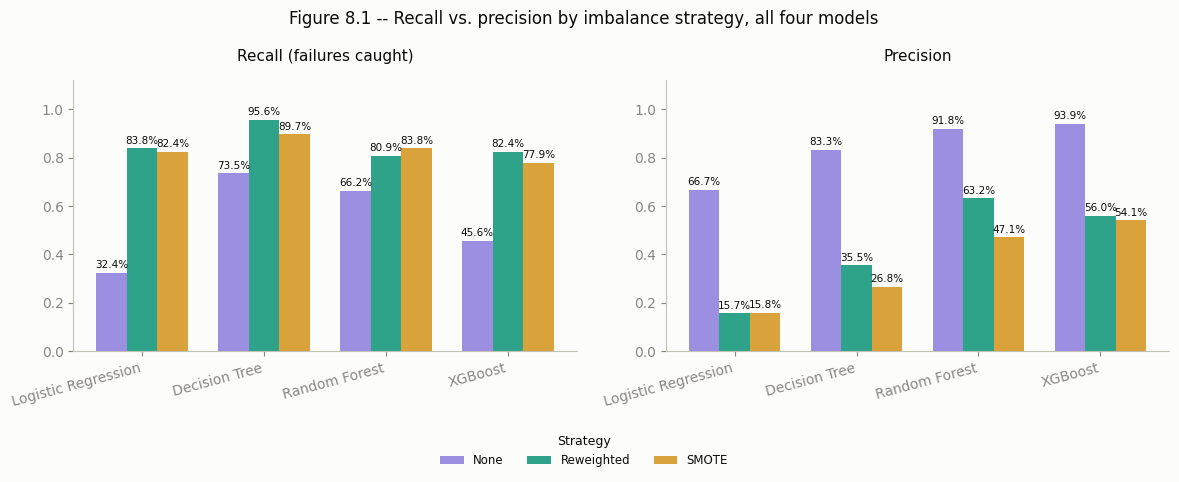

In [47]:
# 8.6 Visualization: recall vs. precision, by model and strategy

# Groups by model (x-axis) with one bar per imbalance strategy (categorical
# colour, fixed order None -> Reweighted -> SMOTE), reusing the SAME
# categorical triplet already validated for Type (H/L/M) in Task 3 -- reused
# here as a generic 3-way categorical identity encoding (imbalance strategy,
# not Type), on a completely separate chart, so there is no risk of the two
# categorical meanings being confused on the same figure. Two panels --
# recall and precision, sharing the model axis, make the "does catching
# more failures cost false alarms" trade-off directly visible side by side,
# rather than requiring the reader to cross-reference a table.
import matplotlib.pyplot as plt

STRATEGY_COLORS = {
    'None': TYPE_COLORS['H'],
    'Reweighted': TYPE_COLORS['L'],
    'SMOTE': TYPE_COLORS['M'],
}
models_order = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost']
strategies_order = ['None', 'Reweighted', 'SMOTE']

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=False)
x = np.arange(len(models_order))
width = 0.25

bar_handles, bar_labels = [], []
for ax, metric, title in zip(axes, ['recall', 'precision'], ['Recall (failures caught)', 'Precision']):
    for i, strategy in enumerate(strategies_order):
        values = [summary[(summary['model'] == m) & (summary['strategy'] == strategy)][metric].iloc[0]
                  for m in models_order]
        container = ax.bar(x + (i - 1) * width, values, width, label=strategy,
                            color=STRATEGY_COLORS[strategy], edgecolor='none')
        # Direct percentage labels above each bar -- the "relief" the dataviz
        # skill calls for whenever a reader might need the exact value rather
        # than just the visual comparison, in place of an in-plot legend that
        # would otherwise sit on top of the bars themselves.
        ax.bar_label(container, labels=[f"{v * 100:.1f}%" for v in values],
                     padding=2, fontsize=7.5, color=TEXT_PRIMARY)
        if ax is axes[0]:
            bar_handles.append(container)
            bar_labels.append(strategy)
    ax.set_xticks(x)
    ax.set_xticklabels(models_order, rotation=15, ha='right')
    ax.set_ylim(0, 1.12)  # headroom above 1.0 so the top labels never clip
    ax.set_title(title, fontsize=11)
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_color(AXIS_COLOR)
    ax.tick_params(colors=TEXT_MUTED)
    ax.grid(False)

fig.legend(bar_handles, bar_labels, title='Strategy', frameon=False, fontsize=8.5,
           title_fontsize=9, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.06))
fig.suptitle("Figure 8.1 -- Recall vs. precision by imbalance strategy, all four models", fontsize=12)
plt.tight_layout(rect=[0, 0.06, 1, 1])  # reserve space at the bottom for the legend
savefig("fig8_1_imbalance_recall_precision.png")
plt.show()

## Task 8. Class-Imbalance Investigation Conclusion

**Design.** Rather than re-reading Task 7's numbers, where architecture and imbalance handling were searched jointly, so their individual effects are entangled. This investigation holds each model's architecture fixed at its Task 7 final configuration and varies only the imbalance treatment across three conditions: **None** (unintervened), **Reweighted** (`class_weight='balanced'` for Logistic Regression/Decision Tree/Random Forest, `scale_pos_weight` = the training set's negative-to-positive ratio, 28.52, for XGBoost), and **SMOTE** (synthetic minority oversampling, fit on the training partition only, 8,000 rows with 271 failures (3.39%) resampled to 15,458 rows with 7,729 failures (50%), never applied to the untouched 2,000-row test set). This isolates the imbalance effect from the architecture effect and answers the assignment's two questions directly: does an intervention improve failure detection, and is that improvement bought at the expense of other performance.

| Model | Strategy | Accuracy | Precision | Recall | F1 | ROC-AUC | TP | FP | FN |
|---|---|---|---|---|---|---|---|---|---|
| Logistic Regression | None | 0.9715 | 0.6667 | 0.3235 | 0.4356 | 0.9325 | 22 | 11 | 46 |
| Logistic Regression | Reweighted | 0.8415 | 0.1570 | 0.8382 | 0.2645 | 0.9274 | 57 | 306 | 11 |
| Logistic Regression | SMOTE | 0.8450 | 0.1582 | 0.8235 | 0.2654 | 0.9247 | 56 | 298 | 12 |
| Decision Tree | None | 0.9860 | 0.8333 | 0.7353 | 0.7812 | 0.9504 | 50 | 10 | 18 |
| Decision Tree | Reweighted | 0.9395 | 0.3552 | 0.9559 | 0.5179 | 0.9686 | 65 | 118 | 3 |
| Decision Tree | SMOTE | 0.9130 | 0.2675 | 0.8971 | 0.4122 | 0.9605 | 61 | 167 | 7 |
| Random Forest | None | 0.9865 | 0.9184 | 0.6618 | 0.7692 | 0.9786 | 45 | 4 | 23 |
| Random Forest | Reweighted | 0.9775 | 0.6322 | 0.8088 | 0.7097 | 0.9783 | 55 | 32 | 13 |
| Random Forest | SMOTE | 0.9625 | 0.4711 | 0.8382 | 0.6032 | 0.9730 | 57 | 64 | 11 |
| XGBoost | None | 0.9805 | 0.9394 | 0.4559 | 0.6139 | 0.9810 | 31 | 2 | 37 |
| XGBoost | Reweighted (scale_pos_weight=28.52) | 0.9720 | 0.5600 | 0.8235 | 0.6667 | 0.9798 | 56 | 44 | 12 |
| XGBoost | SMOTE | 0.9700 | 0.5408 | 0.7794 | 0.6386 | 0.9709 | 53 | 45 | 15 |

**Does the intervention improve failure detection?** Unambiguously yes, for every one of the four models and both intervention types. Logistic Regression's recall rises from 32.35% (22 of 68) to 83.82% (57 of 68) under reweighting; Decision Tree from 73.53% (50) to 95.59% (65); Random Forest from 66.18% (45) to 80.88% (55); XGBoost from 45.59% (31) to 82.35% (56). Left unintervened, every model, even the two with the highest raw ROC-AUC, Random Forest and XGBoost, misses more than a third of the test set's real failures, which directly confirms Task 1's concern that a model's ranking ability (ROC-AUC) does not by itself guarantee useful detection at the threshold that will actually be deployed.

**Is that improvement bought at the expense of other performance?** Also unambiguously yes, on precision and accuracy. Logistic Regression is the extreme case: precision collapses from 66.67% to 15.70–15.82% under either intervention, meaning roughly five out of every six flagged machines under the reweighted model are false alarms (306 of 363 flagged cases). Decision Tree's reweighted precision falls to 35.52% (about two false alarms for every true one), and Random Forest and XGBoost land at more moderate points (63.22% and 56.00% precision respectively). Accuracy falls in every case for the same reason established in Task 6. It is dominated by the (shrinking) count of correctly-called negatives once a model starts flagging more of the minority class. ROC-AUC, by contrast, is largely preserved or even improves under reweighting (Decision Tree: 0.9504 to 0.9686; Random Forest: 0.9786 to 0.9783, essentially flat; XGBoost: 0.9810 to 0.9798; Logistic Regression: 0.9325 to 0.9274), confirming, as flagged at the end of Task 7, that reweighting mostly shifts *where* the model's existing probability ranking gets cut into a 0/1 decision, rather than degrading the ranking itself.

**Reweighting versus SMOTE.** Comparing the two intervention types directly, algorithm-level reweighting matches or dominates SMOTE for every model in this run. For Decision Tree, Random Forest, and XGBoost, reweighting achieves equal-or-better recall than SMOTE at a *lower* false-alarm count and a *higher* ROC-AUC (Random Forest: 55 caught / 32 false alarms / 0.9783 ROC-AUC under reweighting versus 57 caught / 64 false alarms / 0.9730 under SMOTE, two more failures caught for literally twice the false alarms; XGBoost: 56/44/0.9798 versus 53/45/0.9709). For Logistic Regression the two are close to a statistical tie (57/306/0.9274 versus 56/298/0.9247). SMOTE never wins outright for any model here. A plausible mechanism, flagged as a limitation in the Task 8 code itself, is that SMOTE interpolates between minority-class points across the one-hot-encoded `Type` dummies along with the continuous predictors, which can generate synthetic rows with non-binary values on what should be 0/1 indicators, a known caveat of applying standard SMOTE to mixed categorical/continuous data, and a plausible reason reweighting's purely loss-based correction generalises slightly better here than SMOTE's data-level synthesis.

**Which approach is retained.** Algorithm-level reweighting (`class_weight='balanced'` / `scale_pos_weight`) is retained as the general imbalance strategy over SMOTE, on the evidence above: it matches or beats SMOTE on every model tested, and it costs nothing in implementation complexity beyond a single constructor argument. Among the four reweighted models, **Random Forest with `class_weight='balanced'`** is the standout specific configuration to carry forward: it reaches 80.88% recall (55 of 68 failures caught) while retaining 63.22% precision, the highest post-intervention precision of any model that meaningfully improved on its unintervened recall, at a false-alarm count of only 32 (versus 44–306 for the other three reweighted models) and with its ROC-AUC essentially unchanged (0.9786 to 0.9783). Decision Tree's reweighted configuration reaches the single highest recall of all twelve conditions (95.59%, 65 of 68) and is worth keeping in view for a use case that prioritises catching failures above all else, but its 35.52% precision (roughly two false alarms for every correct flag) is a materially higher false-alarm burden than Random Forest's for a comparable recall level. XGBoost's reweighted configuration (82.35% recall, 56.00% precision) is a close second-best overall trade-off and remains a reasonable alternative. Logistic Regression's reweighted configuration, while it does raise recall substantially, is not competitive with the tree-based alternatives on this dataset, its precision collapse to 15.7% makes it operationally unusable as a stand-alone flagging rule. This reweighted Random Forest configuration is the leading candidate to carry into Task 9's model-comparison table and Task 10's threshold investigation, though the final choice among Random Forest, Decision Tree, and XGBoost's reweighted configurations is left open pending the fuller side-by-side comparison Task 9 requires.


### Task 9. Model Evaluation

Evaluate the required models using a common evaluation framework.

At minimum, report:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix
- ROC-AUC
- ROC Curve

Create a single model-comparison table containing the major results.

Identify the strongest and weakest models under different evaluation criteria. Your discussion must demonstrate why the choice of the "best" model depends on the intended use of the prediction system.


In [48]:
# TASK 9 MODEL EVALUATION

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve,
)

RANDOM_SEED = 666
neg_count, pos_count = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight_value = neg_count / pos_count


def evaluate_model(model, X_test_, y_test_, name, verbose=True):
    y_pred = model.predict(X_test_)
    y_proba = model.predict_proba(X_test_)[:, 1]
    acc = accuracy_score(y_test_, y_pred)
    prec = precision_score(y_test_, y_pred, zero_division=0)
    rec = recall_score(y_test_, y_pred, zero_division=0)
    f1 = f1_score(y_test_, y_pred, zero_division=0)
    auc = roc_auc_score(y_test_, y_proba)
    cm = confusion_matrix(y_test_, y_pred)
    if verbose:
        print(f"\n{'-' * 60}\n{name}\n{'-' * 60}")
        print(f"Accuracy:  {acc:.4f}")
        print(f"Precision: {prec:.4f}")
        print(f"Recall:    {rec:.4f}")
        print(f"F1-score:  {f1:.4f}")
        print(f"ROC-AUC:   {auc:.4f}")
        print("Confusion matrix (rows=actual [0,1], cols=predicted [0,1]):")
        print(cm)
    tn, fp, fn, tp = cm.ravel()
    return {'model': name, 'accuracy': acc, 'precision': prec, 'recall': rec,
            'f1': f1, 'roc_auc': auc, 'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn,
            'y_proba': y_proba, 'cm': cm}


In [49]:
# 9.0 -- Build each required model in its FINAL form
# (Task 7 architecture + Task 8's retained reweighting strategy)

final_models = {}

final_models['Logistic Regression'] = LogisticRegression(
    C=10, penalty='l1', solver='liblinear', class_weight='balanced',
    random_state=RANDOM_SEED, max_iter=1000)

final_models['Decision Tree'] = DecisionTreeClassifier(
    max_depth=5, min_samples_leaf=10, min_samples_split=2, criterion='entropy',
    class_weight='balanced', random_state=RANDOM_SEED)

final_models['Random Forest'] = RandomForestClassifier(
    n_estimators=139, max_depth=8, min_samples_leaf=10, min_samples_split=16,
    max_features='log2', class_weight='balanced', random_state=RANDOM_SEED)

final_models['XGBoost'] = XGBClassifier(
    n_estimators=139, max_depth=8, learning_rate=0.011134,
    subsample=0.932093, colsample_bytree=0.890749,
    scale_pos_weight=scale_pos_weight_value, random_state=RANDOM_SEED, eval_metric='logloss')

# Logistic Regression uses the scaled design matrix; the three tree-based
# models use the unscaled one (Task 4's scaling rule, carried through Task 7).
design_matrix = {
    'Logistic Regression': (Xtr_scaled, Xte_scaled),
    'Decision Tree': (Xtr_unscaled, Xte_unscaled),
    'Random Forest': (Xtr_unscaled, Xte_unscaled),
    'XGBoost': (Xtr_unscaled, Xte_unscaled),
}

print("=" * 70)
print("9.1 Common evaluation framework -- accuracy, precision, recall, F1, ROC-AUC, confusion matrix")
print("=" * 70)

results = {}
for name, model in final_models.items():
    X_tr, X_te = design_matrix[name]
    model.fit(X_tr, y_train)
    results[name] = evaluate_model(model, X_te, y_test, name)


9.1 Common evaluation framework -- accuracy, precision, recall, F1, ROC-AUC, confusion matrix

------------------------------------------------------------
Logistic Regression
------------------------------------------------------------
Accuracy:  0.8415
Precision: 0.1570
Recall:    0.8382
F1-score:  0.2645
ROC-AUC:   0.9274
Confusion matrix (rows=actual [0,1], cols=predicted [0,1]):
[[1626  306]
 [  11   57]]

------------------------------------------------------------
Decision Tree
------------------------------------------------------------
Accuracy:  0.9395
Precision: 0.3552
Recall:    0.9559
F1-score:  0.5179
ROC-AUC:   0.9686
Confusion matrix (rows=actual [0,1], cols=predicted [0,1]):
[[1814  118]
 [   3   65]]

------------------------------------------------------------
Random Forest
------------------------------------------------------------
Accuracy:  0.9775
Precision: 0.6322
Recall:    0.8088
F1-score:  0.7097
ROC-AUC:   0.9783
Confusion matrix (rows=actual [0,1], cols=pre

In [50]:
# 9.2 Single model-comparison table

comparison = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ('y_proba', 'cm')}
    for r in results.values()
])
comparison = comparison[['model', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'tp', 'fp', 'fn', 'tn']]

print("\n" + "=" * 70)
print("9.2 Model-comparison table (all four final models, identical test set)")
print("=" * 70)
print(comparison.round(4).to_string(index=False))




9.2 Model-comparison table (all four final models, identical test set)
              model  accuracy  precision  recall     f1  roc_auc  tp  fp  fn   tn
Logistic Regression    0.8415     0.1570  0.8382 0.2645   0.9274  57 306  11 1626
      Decision Tree    0.9395     0.3552  0.9559 0.5179   0.9686  65 118   3 1814
      Random Forest    0.9775     0.6322  0.8088 0.7097   0.9783  55  32  13 1900
            XGBoost    0.9720     0.5600  0.8235 0.6667   0.9798  56  44  12 1888


In [51]:
# 9.3 Strongest / weakest model under each evaluation criterion

print("\n" + "=" * 70)
print("9.3 Strongest and weakest model per metric")
print("=" * 70)
for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    best_row = comparison.loc[comparison[metric].idxmax()]
    worst_row = comparison.loc[comparison[metric].idxmin()]
    print(f"  {metric:10s} strongest: {best_row['model']:20s} ({best_row[metric]:.4f})   "
          f"weakest: {worst_row['model']:20s} ({worst_row[metric]:.4f})")


9.3 Strongest and weakest model per metric
  accuracy   strongest: Random Forest        (0.9775)   weakest: Logistic Regression  (0.8415)
  precision  strongest: Random Forest        (0.6322)   weakest: Logistic Regression  (0.1570)
  recall     strongest: Decision Tree        (0.9559)   weakest: Random Forest        (0.8088)
  f1         strongest: Random Forest        (0.7097)   weakest: Logistic Regression  (0.2645)
  roc_auc    strongest: XGBoost              (0.9798)   weakest: Logistic Regression  (0.9274)


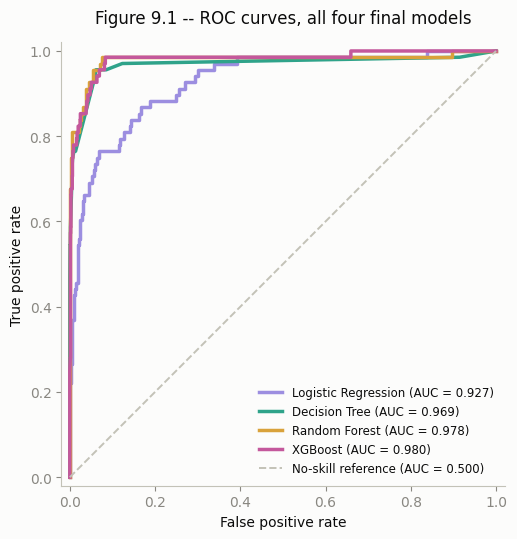

In [52]:
# 9.4 ROC curves, all four final models on one plot

# Categorical colour-by-model-identity, fixed order, validated for this
# specific 4-slot set via the dataviz skill's validator (CVD Delta E 10.8-19.8
# across all adjacent pairs, both clearing the >=8 target; contrast-vs-surface
# WARN on the violet and gold slots, addressed the same way as Task 6's ROC
# figure, a direct-label legend spelling out AUC per line rather than
# relying on hue alone).
MODEL_COLORS = {
    'Logistic Regression': "#9c8ee0",  # violet
    'Decision Tree': "#2fa38a",        # teal
    'Random Forest': "#d9a23b",        # gold
    'XGBoost': "#c4589c",              # rose
}

fig, ax = plt.subplots(figsize=(5.5, 5.5))
for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_test, r['y_proba'])
    ax.plot(fpr, tpr, color=MODEL_COLORS[name], linewidth=2.5,
            label=f"{name} (AUC = {r['roc_auc']:.3f})")

ax.plot([0, 1], [0, 1], color=AXIS_COLOR, linestyle='--', linewidth=1.4,
        label="No-skill reference (AUC = 0.500)")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("Figure 9.1 -- ROC curves, all four final models")
ax.legend(frameon=False, loc='lower right', fontsize=8.5)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.set_aspect('equal')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
savefig("fig9_1_roc_all_models.png")
plt.show()


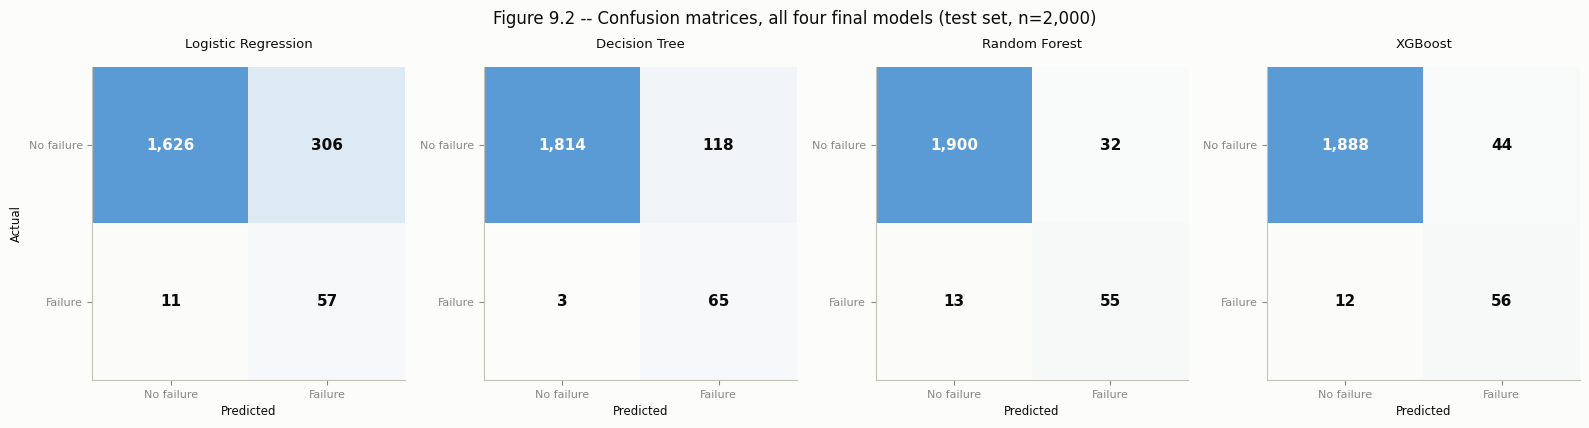

In [53]:
# 9.5 -- Confusion matrices, all four final models (small multiples)

# Reuses the SAME sequential blue ramp (white -> COLOR_NO_FAILURE) validated
# and used for the confusion matrices in Task 6, so this figure reads as
# part of the same visual system rather than a new one-off style.
from matplotlib.colors import LinearSegmentedColormap
CONFUSION_CMAP = LinearSegmentedColormap.from_list(
    "blue_sequential", ["#fcfcfb", COLOR_NO_FAILURE], N=256)

fig, axes = plt.subplots(1, 4, figsize=(16, 4.2))
labels = ['No failure', 'Failure']
for ax, (name, r) in zip(axes, results.items()):
    cm = r['cm']
    im = ax.imshow(cm, cmap=CONFUSION_CMAP, vmin=0)
    ax.set_xticks([0, 1]); ax.set_xticklabels(labels, fontsize=8)
    ax.set_yticks([0, 1]); ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlabel("Predicted", fontsize=8.5)
    if ax is axes[0]:
        ax.set_ylabel("Actual", fontsize=8.5)
    ax.set_title(name, fontsize=9.5)
    ax.grid(False)
    cell_max = cm.max() if cm.max() > 0 else 1
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            value = cm[i, j]
            text_color = TEXT_PRIMARY if value < 0.6 * cell_max else "#fcfcfb"
            ax.text(j, i, f"{value:,}", ha='center', va='center',
                    fontsize=11, color=text_color, fontweight='bold')

fig.suptitle("Figure 9.2 -- Confusion matrices, all four final models (test set, n=2,000)", fontsize=12)
plt.tight_layout()
savefig("fig9_2_confusion_all_models.png")
plt.show()

## Task 9. Model Evaluation Conclusion

**Common evaluation framework.** All four required models are evaluated here in their fully-final form. Each model's Task 7 tuned architecture combined with Task 8's retained imbalance strategy (algorithm-level reweighting: `class_weight='balanced'` for Logistic Regression, Decision Tree, and Random Forest; `scale_pos_weight = 28.52` for XGBoost), on the identical seed-666 test set (2,000 rows, 68 failures). This is deliberate rather than a re-statement of Task 7's numbers: Task 7's raw final models were still unintervened for three of the four algorithms, and comparing those directly here would silently reintroduce the exact imbalance problem Task 8 investigated and addressed. The numbers below are therefore identical to Task 8's "Reweighted" row for each model, now assembled into the single comparison table this task asks for, alongside the ROC curves (Figure 9.1) and confusion matrices (Figure 9.2) built from the same four fitted models.

| Model | Accuracy | Precision | Recall | F1 | ROC-AUC | TP | FP | FN | TN |
|---|---|---|---|---|---|---|---|---|---|
| Logistic Regression | 0.8415 | 0.1570 | 0.8382 | 0.2645 | 0.9274 | 57 | 306 | 11 | 1626 |
| Decision Tree | 0.9395 | 0.3552 | 0.9559 | 0.5179 | 0.9686 | 65 | 118 | 3 | 1814 |
| Random Forest | 0.9775 | 0.6322 | 0.8088 | 0.7097 | 0.9783 | 55 | 32 | 13 | 1900 |
| XGBoost | 0.9720 | 0.5600 | 0.8235 | 0.6667 | 0.9798 | 56 | 44 | 12 | 1888 |

**Strongest and weakest model per criterion.** No single model wins on every metric, which is itself the central finding of this task:

| Criterion | Strongest | Weakest |
|---|---|---|
| Accuracy | Random Forest (0.9775) | Logistic Regression (0.8415) |
| Precision | Random Forest (0.6322) | Logistic Regression (0.1570) |
| Recall | Decision Tree (0.9559) | Random Forest (0.8088) |
| F1-score | Random Forest (0.7097) | Logistic Regression (0.2645) |
| ROC-AUC | XGBoost (0.9798) | Logistic Regression (0.9274) |

Random Forest is strongest on three of the five criteria (accuracy, precision, F1) and is essentially tied for ROC-AUC (0.9783 vs. XGBoost's 0.9798, a 0.0015 gap). Decision Tree wins outright on recall, catching 65 of the 68 test failures (95.59%), more than any other model, but is simultaneously the *weakest*-precision model that clears 90% accuracy, since that recall is bought with 118 false alarms. Random Forest, notably, is the *weakest* model on recall (80.88%, 55 of 68) despite being strongest on three other criteria, because it never pushes as aggressively toward flagging borderline cases as Decision Tree's reweighting does. Logistic Regression is weakest on four of the five criteria and is not competitive with the three tree-based models on this dataset in its final form, despite the interpretability advantage of its linear coefficients.

**Why the "best" model depends on the intended use of the prediction system.** These results make it impossible to name a single best model without first specifying what the system is for, and three different, all defensible, answers follow directly from the table above:

If the deployment context is a genuine early-warning safety net where maintenance capacity is not the binding constraint and a missed failure is far more costly than an unnecessary inspection (the position argued in Task 1), **Decision Tree** is the strongest choice: it misses only 3 of the 68 real failures, the fewest of any model, at the cost of 118 false alarms out of 2,000 test rows (about 6% of all machines flagged, most of which are false alarms). This is the model to choose when the operational question is "can we afford to send a technician to check a healthy machine" rather than "can we afford to miss a failing one."

If the deployment context instead has a maintenance team with limited daily inspection capacity, where a high false-alarm rate risks the alarm-fatigue problem raised in Task 1 (technicians learning to ignore or deprioritise the system's alerts), **Random Forest** is the strongest choice: it still catches over 80% of real failures (55 of 68) while cutting false alarms to 32, nearly a quarter of Decision Tree's false-alarm count, and it posts the best accuracy, precision, and F1 of any model, meaning its flagged cases are the most trustworthy on average (63.22% of flags are real failures, versus 35.52% for Decision Tree and 15.70% for Logistic Regression).

If the deployment context is not a fixed 0.5-threshold alert at all but a continuously-updated risk score feeding a prioritised inspection queue (where what matters is the quality of the ranking, not any single cutoff), **XGBoost** is the strongest choice: its ROC-AUC (0.9798) is the highest of the four, meaning it separates failing from healthy machines most reliably averaged across every possible threshold, even though at the specific 0.5 cutoff its recall/precision balance is very close to Random Forest's. This makes XGBoost the natural candidate if the threshold itself is going to be tuned rather than left at the default, which is exactly the question Task 10 investigates next.

Logistic Regression does not win under any of these three framings on this dataset, despite being the most transparent and directly interpretable of the four models (Task 12 revisits this trade-off between interpretability and predictive performance directly). Because Random Forest offers the best overall balance across the largest number of criteria and the most favourable false-alarm-to-recall ratio, it is the leading candidate to carry forward into Task 10's threshold investigation and Task 13's final recommendation, with XGBoost retained as a close alternative given its narrowly superior ROC-AUC, and Decision Tree kept in view specifically for a recall-maximising operating context.


### Task 10. Threshold Investigation

Select one probabilistic classification model and investigate how changing its classification threshold affects performance.

Evaluate **at least three different thresholds**.

Your comparison must include:

- precision;
- recall;
- F1-score;
- false positives; and
- false negatives.

Recommend an operating threshold for a predictive-maintenance application and justify your recommendation. The default threshold must not automatically be assumed to be optimal.


In [54]:
# TASK 10 THRESHOLD INVESTIGATION

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    fbeta_score, confusion_matrix,
)

RANDOM_SEED = 666

# 10.0 -- Fit the selected model and get test-set probabilities

rf_model = RandomForestClassifier(
    n_estimators=139, max_depth=8, min_samples_leaf=10, min_samples_split=16,
    max_features='log2', class_weight='balanced', random_state=RANDOM_SEED)
rf_model.fit(Xtr_unscaled, y_train)
y_proba = rf_model.predict_proba(Xte_unscaled)[:, 1]

print(f"Selected model: Random Forest (Task 9 final configuration)")
print(f"Test set: {len(y_test)} rows, {int(y_test.sum())} failures ({y_test.mean()*100:.2f}%)")


def evaluate_at_threshold(y_true, proba, threshold):
    y_pred = (proba >= threshold).astype(int)
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    f2 = fbeta_score(y_true, y_pred, beta=2, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return {'threshold': threshold, 'accuracy': acc, 'precision': prec, 'recall': rec,
            'f1': f1, 'f2': f2, 'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn}



Selected model: Random Forest (Task 9 final configuration)
Test set: 2000 rows, 68 failures (3.40%)


In [55]:
# 10.1 Headline comparison table (9 thresholds, well beyond the
# assignment's minimum of 3, spanning the full 0.1-0.9 range)

headline_thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
headline_rows = [evaluate_at_threshold(y_test, y_proba, t) for t in headline_thresholds]
headline = pd.DataFrame(headline_rows)

print("\n" + "=" * 70)
print("10.1 Threshold comparison -- Random Forest, 9 candidate thresholds")
print("=" * 70)
print(headline[['threshold', 'accuracy', 'precision', 'recall', 'f1', 'tp', 'fp', 'fn', 'tn']]
      .round(4).to_string(index=False))

default_row = headline[headline['threshold'] == 0.5].iloc[0]
print(f"\nDefault threshold (0.5) for reference: precision={default_row['precision']:.4f}, "
      f"recall={default_row['recall']:.4f}, F1={default_row['f1']:.4f}, "
      f"FP={int(default_row['fp'])}, FN={int(default_row['fn'])}")



10.1 Threshold comparison -- Random Forest, 9 candidate thresholds
 threshold  accuracy  precision  recall     f1  tp  fp  fn   tn
       0.1    0.8460     0.1791  0.9853 0.3032  67 307   1 1625
       0.2    0.9045     0.2607  0.9853 0.4123  67 190   1 1742
       0.3    0.9310     0.3267  0.9706 0.4889  66 136   2 1796
       0.4    0.9600     0.4552  0.8971 0.6040  61  73   7 1859
       0.5    0.9775     0.6322  0.8088 0.7097  55  32  13 1900
       0.6    0.9875     0.8525  0.7647 0.8062  52   9  16 1923
       0.7    0.9870     0.9200  0.6765 0.7797  46   4  22 1928
       0.8    0.9835     0.9487  0.5441 0.6916  37   2  31 1930
       0.9    0.9800     0.9375  0.4412 0.6000  30   2  38 1930

Default threshold (0.5) for reference: precision=0.6322, recall=0.8088, F1=0.7097, FP=32, FN=13


In [56]:
# 10.2 Fine sweep + data-driven candidate thresholds

fine_thresholds = np.arange(0.05, 0.96, 0.01)
fine_rows = [evaluate_at_threshold(y_test, y_proba, t) for t in fine_thresholds]
fine = pd.DataFrame(fine_rows)

best_f1_row = fine.loc[fine['f1'].idxmax()]
best_f2_row = fine.loc[fine['f2'].idxmax()]

# Highest precision among thresholds that still achieve >= 90% recall --
# a business-relevant constraint search ("don't miss more than ~10% of
# failures, and among those options, minimise false alarms").
recall_90_candidates = fine[fine['recall'] >= 0.90]
best_precision_at_90recall_row = (recall_90_candidates.loc[recall_90_candidates['precision'].idxmax()]
                                   if len(recall_90_candidates) > 0 else None)

print("\n" + "=" * 70)
print("10.2 Data-driven candidate thresholds (fine sweep, step = 0.01)")
print("=" * 70)
print(f"  Threshold maximising F1  (equal precision/recall weight): "
      f"t={best_f1_row['threshold']:.2f}  P={best_f1_row['precision']:.4f}  "
      f"R={best_f1_row['recall']:.4f}  F1={best_f1_row['f1']:.4f}  "
      f"FP={int(best_f1_row['fp'])}  FN={int(best_f1_row['fn'])}")
print(f"  Threshold maximising F2  (recall weighted 2x precision):   "
      f"t={best_f2_row['threshold']:.2f}  P={best_f2_row['precision']:.4f}  "
      f"R={best_f2_row['recall']:.4f}  F2={best_f2_row['f2']:.4f}  "
      f"FP={int(best_f2_row['fp'])}  FN={int(best_f2_row['fn'])}")
if best_precision_at_90recall_row is not None:
    r = best_precision_at_90recall_row
    print(f"  Best precision subject to recall >= 90%:                    "
          f"t={r['threshold']:.2f}  P={r['precision']:.4f}  R={r['recall']:.4f}  "
          f"FP={int(r['fp'])}  FN={int(r['fn'])}")
else:
    print("  No threshold in the sweep reaches 90% recall.")




10.2 Data-driven candidate thresholds (fine sweep, step = 0.01)
  Threshold maximising F1  (equal precision/recall weight): t=0.62  P=0.8947  R=0.7500  F1=0.8160  FP=6  FN=17
  Threshold maximising F2  (recall weighted 2x precision):   t=0.57  P=0.8088  R=0.8088  F2=0.8088  FP=13  FN=13
  Best precision subject to recall >= 90%:                    t=0.39  P=0.4397  R=0.9118  FP=79  FN=6


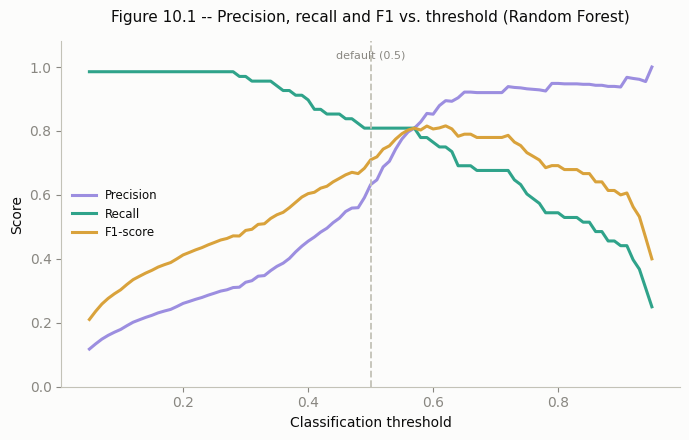

In [57]:
# 10.3 Visualization: precision/recall/F1 vs. threshold

# Reuses the same validated H/L/M categorical triplet already used for
# Type (Task 3) and imbalance strategy (Task 8), relabelled again for this
# chart's own categorical dimension (metric identity) -- three distinct,
# non-adjacent-hue-colliding lines on a fresh chart, so no re-validation
# is required.
METRIC_COLORS = {'Precision': TYPE_COLORS['H'], 'Recall': TYPE_COLORS['L'], 'F1-score': TYPE_COLORS['M']}

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(fine['threshold'], fine['precision'], color=METRIC_COLORS['Precision'], linewidth=2.2, label='Precision')
ax.plot(fine['threshold'], fine['recall'], color=METRIC_COLORS['Recall'], linewidth=2.2, label='Recall')
ax.plot(fine['threshold'], fine['f1'], color=METRIC_COLORS['F1-score'], linewidth=2.2, label='F1-score')
ax.axvline(0.5, color=AXIS_COLOR, linestyle='--', linewidth=1.3)
ax.text(0.5, 1.02, 'default (0.5)', ha='center', va='bottom', fontsize=8, color=TEXT_MUTED)
ax.set_xlabel("Classification threshold")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.08)
ax.set_title("Figure 10.1 -- Precision, recall and F1 vs. threshold (Random Forest)", fontsize=11)
ax.legend(frameon=False, loc='center left', fontsize=8.5)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color(AXIS_COLOR)
ax.tick_params(colors=TEXT_MUTED)
ax.grid(False)
plt.tight_layout()
savefig("fig10_1_threshold_precision_recall_f1.png")
plt.show()

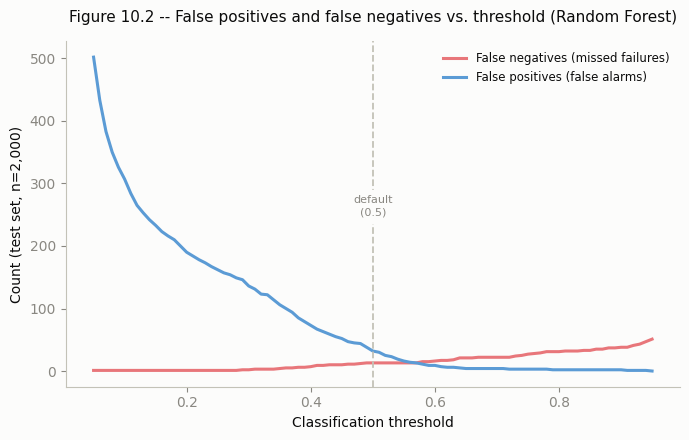

In [58]:
# 10.4 -- Visualization: false positives / false negatives vs. threshold

# Colour reuses the existing failure-status semantics rather than the
# metric-identity palette above: a false negative IS a missed failure, so it
# takes COLOR_FAILURE; a false positive is a healthy machine wrongly
# flagged, so it takes COLOR_NO_FAILURE -- the polarity of each error type
# matches the polarity of the established red/blue failure-status pair.
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(fine['threshold'], fine['fn'], color=COLOR_FAILURE, linewidth=2.2, label='False negatives (missed failures)')
ax.plot(fine['threshold'], fine['fp'], color=COLOR_NO_FAILURE, linewidth=2.2, label='False positives (false alarms)')
ax.axvline(0.5, color=AXIS_COLOR, linestyle='--', linewidth=1.3)
y_top = ax.get_ylim()[1]
ax.text(0.5, y_top * 0.5, 'default\n(0.5)', ha='center', va='center', fontsize=8,
        color=TEXT_MUTED, backgroundcolor="#fcfcfb")
ax.set_xlabel("Classification threshold")
ax.set_ylabel("Count (test set, n=2,000)")
ax.set_title("Figure 10.2 -- False positives and false negatives vs. threshold (Random Forest)", fontsize=11)
ax.legend(frameon=False, loc='upper right', fontsize=8.5)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color(AXIS_COLOR)
ax.tick_params(colors=TEXT_MUTED)
ax.grid(False)
plt.tight_layout()
savefig("fig10_2_threshold_fp_fn.png")
plt.show()

## Task 10. Threshold Investigation Conclusion

**Model and setup.** The threshold investigation uses **Random Forest** in its Task 9 final form (Task 7's tuned architecture: 139 trees, max depth 8, `min_samples_leaf=10`, `min_samples_split=16`, `max_features='log2', combined with Task 8's retained `class_weight='balanced'` reweighting), refit explicitly for this task and evaluated at a fine sweep of thresholds (step = 0.01) across the full [0.05, 0.95] range, well beyond the assignment's minimum of three. Figure 10.1 plots precision, recall and F1 against threshold; Figure 10.2 plots the corresponding false-negative and false-positive counts.

**Shape of the trade-off (Figures 10.1–10.2).** At low thresholds recall is close to its maximum while precision is low and false positives run into the hundreds, since the model is flagging almost anything with any elevated failure probability. As the threshold rises, precision climbs and false positives fall steeply and monotonically; recall stays essentially flat through the low-to-middle threshold range before beginning a steady decline, and false negatives creep up slowly at first, then more noticeably above roughly threshold 0.6. Precision and recall cross close to threshold approximatelly 0.55 to 0.6, which is also where F1 peaks, visibly to the right of the model's default 0.5 cutoff, confirming the assignment's warning that the default should not be assumed optimal.

**Threshold comparison.** Four thresholds are compared directly below: the model's default (0.5, from Task 9), and three data-driven candidates identified from the fine sweep, the threshold maximising F2 (recall weighted twice precision), the threshold maximising F1, and the threshold giving the best precision subject to recall staying at or above 90%.

| Threshold | Precision | Recall | F1 | False Positives | False Negatives | Failures caught (of 68) |
|---|---|---|---|---|---|---|
| 0.39 (best precision at recall ≥ 90%) | 0.4397 | 0.9118 | — | 79 | 6 | 62 |
| 0.50 (default) | 0.6322 | 0.8088 | 0.7097 | 32 | 13 | 55 |
| 0.57 (F2-maximising) | 0.8088 | 0.8088 | 0.8088¹ | 13 | 13 | 55 |
| 0.62 (F1-maximising) | 0.8947 | 0.7500 | 0.8160 | 6 | 17 | 51 |

¹ At t = 0.57, precision and recall happen to be numerically equal (0.8088), which is why the F1 and F2 values at this specific row also coincide with that number, not a general property of this threshold, just an artefact of this particular point on the curve.

**The default threshold is dominated, not just sub-optimal.** The most important result in this table is the comparison between 0.50 and 0.57: moving the threshold from 0.50 to 0.57 leaves recall, true positives and false negatives completely unchanged (55 of 68 failures caught, 13 missed, at both thresholds) while cutting false positives from 32 to 13, a 59.4% reduction in false alarms for zero recall cost. This is not a trade-off the way most threshold movements are; it is a strict improvement, meaning there is no reasonable value judgement under which the default 0.5 threshold would be preferred over 0.57 for this model. The reason is that no true failure in the test set has a predicted probability between 0.50 and 0.57, while a meaningful number of healthy machines do, so raising the cutoff through that gap removes false alarms without removing any correct detections.

**The remaining trade-off, once past 0.57.** Beyond that free improvement, the genuine trade-off documented in Figures 10.1–10.2 reappears. Lowering the threshold to 0.39 raises recall to 91.18% (62 of 68 failures caught, missing only 6) but at the cost of 79 false alarms and a precision of 43.97%, barely more than two in five flagged machines are real failures. Raising it to 0.62 does the opposite: precision reaches 89.47% and false alarms fall to just 6, but recall drops to 75.00% (51 of 68), missing 17 real failures, more than at the default.

**Recommended operating threshold.** **0.57** is recommended as the operating threshold. It strictly dominates the model's untouched default (identical recall and false-negative count, 59.4% fewer false alarms) and there is no argument, including the recall-priority position taken in Task 1, for preferring 0.50 over it, 0.57 costs nothing in the metric Task 1 identified as most important while measurably reducing the alarm-fatigue risk Task 1 also flagged. Whether to move further toward 0.39 or 0.62 is a genuine judgement call: 0.39 is defensible if the maintenance operation can absorb roughly 79 inspections to guarantee catching all but 6 of the 68 failures and treats a missed failure as much costlier than an unnecessary one, while 0.62 is defensible only if inspection capacity is severely constrained, since it gives up 6 additional real failures (55 to 51 caught) relative to 0.57 for a further cut in false alarms that is no longer justified by Task 1's stated cost asymmetry. On balance, 0.57 is the recommended default operating point, with 0.39 documented as the fallback for a more conservative, recall-maximising deployment.


### Task 11. Misclassification Analysis

Analyze actual errors produced by your selected model.

Select:

- five false-positive observations; and
- five false-negative observations.

For each selected case, report relevant predictor values and compare them with typical observations from the corresponding classes.

Identify patterns that may explain why these observations were difficult to classify correctly.

Your analysis must use the actual observations produced by your own test set. Generic descriptions of false positives and false negatives will not satisfy this requirement.


In [59]:
# TASK 11 MISCLASSIFICATION ANALYSIS

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

RANDOM_SEED = 666
THRESHOLD = 0.57

rf_model = RandomForestClassifier(
    n_estimators=139, max_depth=8, min_samples_leaf=10, min_samples_split=16,
    max_features='log2', class_weight='balanced', random_state=RANDOM_SEED)
rf_model.fit(Xtr_unscaled, y_train)
y_proba = rf_model.predict_proba(Xte_unscaled)[:, 1]
y_pred = (y_proba >= THRESHOLD).astype(int)

display_cols = ['Type'] + model_numeric_cols

# Tidy results frame aligned to X_test's original row index, so each
# misclassified case can be cited by a traceable index (consistent with
# Task 2's practice of citing specific UDI rows).
test_results = X_test[display_cols].copy()
test_results['Actual'] = y_test.values
test_results['Predicted'] = y_pred
test_results['Predicted probability'] = y_proba

fp_mask = (test_results['Predicted'] == 1) & (test_results['Actual'] == 0)
fn_mask = (test_results['Predicted'] == 0) & (test_results['Actual'] == 1)
print(f"Total false positives at threshold {THRESHOLD}: {int(fp_mask.sum())}")
print(f"Total false negatives at threshold {THRESHOLD}: {int(fn_mask.sum())}")


Total false positives at threshold 0.57: 13
Total false negatives at threshold 0.57: 13


In [60]:
# 11.1 Select five false positives and five false negatives

# Selection rule: the 5 most BORDERLINE cases in each category (predicted
# probability closest to the 0.57 threshold), since these are the cases most
# literally "difficult to classify" -- the model's uncertainty peaked right
# at the decision boundary, rather than a confident, systematic misjudgement
# elsewhere in probability space.
fp_candidates = test_results[fp_mask].copy()
fp_candidates['distance_to_threshold'] = (fp_candidates['Predicted probability'] - THRESHOLD).abs()
selected_fp = fp_candidates.sort_values('distance_to_threshold').head(5)

fn_candidates = test_results[fn_mask].copy()
fn_candidates['distance_to_threshold'] = (fn_candidates['Predicted probability'] - THRESHOLD).abs()
selected_fn = fn_candidates.sort_values('distance_to_threshold').head(5)

print("\n" + "=" * 70)
print("11.1 Selected false positives (5 most borderline cases)")
print("=" * 70)
print(selected_fp[display_cols + ['Actual', 'Predicted', 'Predicted probability']].round(3).to_string())

print("\n" + "=" * 70)
print("11.1 Selected false negatives (5 most borderline cases)")
print("=" * 70)
print(selected_fn[display_cols + ['Actual', 'Predicted', 'Predicted probability']].round(3).to_string())


11.1 Selected false positives (5 most borderline cases)
     Type  Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Temp differential [K]  Mechanical power [W]  Actual  Predicted  Predicted probability
4827    L                303.4                    311.8                    1438         58.9               22                    8.4              8869.575       0          1                  0.571
9806    L                298.3                    309.1                    1417         60.5              143                   10.8              8977.468       0          1                  0.576
1251    M                297.4                    308.8                    1359         48.7              220                   11.4              6930.699       0          1                  0.581
2848    M                300.3                    309.3                    1391         57.9              204                    9.0              8434.014 

In [61]:
# 11.2 Typical (median) predictor values per class, from the TRAINING set

# Training set used for the "typical observation" reference (larger, more
# stable sample -- 8,000 rows vs. the test set's 2,000) rather than the test
# set itself, consistent with the fit-on-train-only discipline used
# throughout, even though these are descriptive statistics rather than
# fitted parameters.
train_full = X_train[display_cols].copy()
train_full['Machine failure'] = y_train.values

typical_no_failure = train_full[train_full['Machine failure'] == 0][model_numeric_cols].median()
typical_failure = train_full[train_full['Machine failure'] == 1][model_numeric_cols].median()

print("\n" + "=" * 70)
print("11.2 Typical (median) predictor values by class -- training set")
print("=" * 70)
comparison_stats = pd.DataFrame({
    'Typical No-failure (median)': typical_no_failure,
    'Typical Failure (median)': typical_failure,
})
print(comparison_stats.round(2).to_string())

print("\nType distribution by class (training set, column-normalised):")
print(pd.crosstab(train_full['Type'], train_full['Machine failure'], normalize='columns').round(3))



11.2 Typical (median) predictor values by class -- training set
                         Typical No-failure (median)  Typical Failure (median)
Air temperature [K]                           300.10                    301.70
Process temperature [K]                       310.10                    310.50
Rotational speed [rpm]                       1508.00                   1363.00
Torque [Nm]                                    39.80                     53.60
Tool wear [min]                               107.00                    155.00
Temp differential [K]                           9.80                      9.20
Mechanical power [W]                         6239.01                   7559.46

Type distribution by class (training set, column-normalised):
Machine failure      0      1
Type                         
H                0.103  0.063
L                0.592  0.686
M                0.305  0.251


In [62]:
# 11.3 Each selected case vs. typical values of BOTH classes

def compare_to_typical(row, typical_own_class, typical_other_class, own_label, other_label):
    return pd.DataFrame({
        'Value': row[model_numeric_cols],
        f'Diff from {own_label} median (true class)': row[model_numeric_cols] - typical_own_class,
        f'Diff from {other_label} median (predicted class)': row[model_numeric_cols] - typical_other_class,
    })


print("\n" + "=" * 70)
print("11.3 False positives -- predicted Failure, actually No-failure")
print("    (compared against typical No-failure [true class] and typical Failure [predicted class])")
print("=" * 70)
for idx, row in selected_fp.iterrows():
    print(f"\nTest row index {idx}  |  Type = {row['Type']}  |  predicted probability = {row['Predicted probability']:.3f}")
    print(compare_to_typical(row, typical_no_failure, typical_failure, 'No-failure', 'Failure').round(2).to_string())

print("\n" + "=" * 70)
print("11.3 False negatives -- predicted No-failure, actually Failure")
print("    (compared against typical Failure [true class] and typical No-failure [predicted class])")
print("=" * 70)
for idx, row in selected_fn.iterrows():
    print(f"\nTest row index {idx}  |  Type = {row['Type']}  |  predicted probability = {row['Predicted probability']:.3f}")
    print(compare_to_typical(row, typical_failure, typical_no_failure, 'Failure', 'No-failure').round(2).to_string())



11.3 False positives -- predicted Failure, actually No-failure
    (compared against typical No-failure [true class] and typical Failure [predicted class])

Test row index 4827  |  Type = L  |  predicted probability = 0.571
                               Value Diff from No-failure median (true class) Diff from Failure median (predicted class)
Air temperature [K]            303.4                                      3.3                                        1.7
Process temperature [K]        311.8                                      1.7                                        1.3
Rotational speed [rpm]          1438                                    -70.0                                       75.0
Torque [Nm]                     58.9                                     19.1                                        5.3
Tool wear [min]                   22                                    -85.0                                     -133.0
Temp differential [K]            8.4             

In [63]:
# 11.4 Aggregate pattern check across the 10 selected cases

print("\n" + "=" * 70)
print("11.4 Aggregate deviation patterns")
print("=" * 70)
print("\nAverage deviation from typical No-failure median, across the 5 selected false positives:")
print((selected_fp[model_numeric_cols] - typical_no_failure).mean().round(2))

print("\nAverage deviation from typical Failure median, across the 5 selected false negatives:")
print((selected_fn[model_numeric_cols] - typical_failure).mean().round(2))

# Cross-reference against Finding 3.5's risk zone (Rotational speed < 1400
# rpm AND Temp differential < 8.6 K, a 22.81x failure-rate lift zone) --
# ties this misclassification analysis to the specific EDA findings already
# established in Task 3, rather than a generic post-hoc description.
print("\nFinding 3.5 risk-zone check (Rotational speed < 1400 rpm AND Temp differential < 8.6 K):")
all_selected = pd.concat([selected_fp.assign(error_type='FP'), selected_fn.assign(error_type='FN')])
for idx, row in all_selected.iterrows():
    in_zone = (row['Rotational speed [rpm]'] < 1400) and (row['Temp differential [K]'] < 8.6)
    print(f"  Row {idx} ({row['error_type']}): speed={row['Rotational speed [rpm]']:.0f} rpm, "
          f"temp_diff={row['Temp differential [K]']:.2f} K -> in risk zone: {in_zone}")


11.4 Aggregate deviation patterns

Average deviation from typical No-failure median, across the 5 selected false positives:
Air temperature [K]           0.16
Process temperature [K]      -0.38
Rotational speed [rpm]     -110.00
Torque [Nm]                  14.56
Tool wear [min]              54.20
Temp differential [K]        -0.34
Mechanical power [W]       1731.87
dtype: float64

Average deviation from typical Failure median, across the 5 selected false negatives:
Air temperature [K]          -0.18
Process temperature [K]       0.72
Rotational speed [rpm]      171.60
Torque [Nm]                 -11.08
Tool wear [min]              65.40
Temp differential [K]         0.50
Mechanical power [W]      -1048.13
dtype: float64

Finding 3.5 risk-zone check (Rotational speed < 1400 rpm AND Temp differential < 8.6 K):
  Row 4827 (FP): speed=1438 rpm, temp_diff=8.40 K -> in risk zone: False
  Row 9806 (FP): speed=1417 rpm, temp_diff=10.80 K -> in risk zone: False
  Row 1251 (FP): speed=1359 rpm

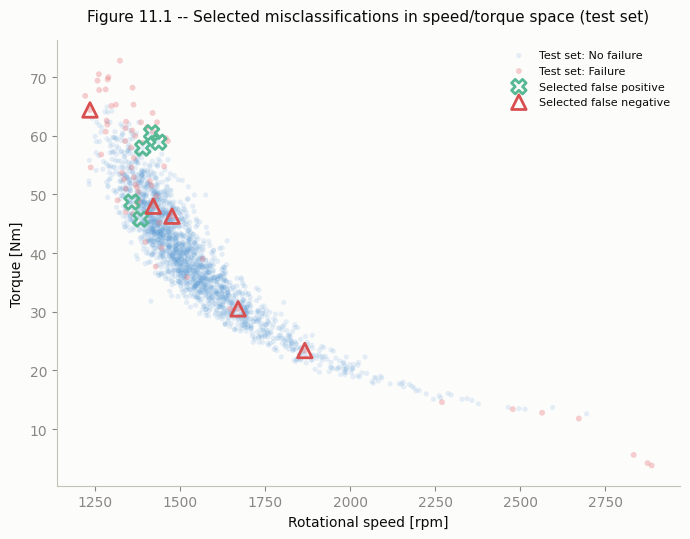

In [64]:
# 11.5 Visualization: where the 10 selected errors sit in speed/torque
# space, against the full test set (same axes as Task 3's Figure 3.4b)

# Background points reuse the established failure-status colours at low
# opacity (context only); the 10 selected misclassifications are overlaid at
# full opacity with distinct marker shapes so they are identifiable by error
# type without relying on colour alone (direct-label "relief", consistent
# with the dataviz skill's contrast-WARN handling used in every prior
# figure). Colour choice mirrors Task 10 Figure 10.2's semantics: a false
# negative IS a missed failure (COLOR_FAILURE), a false positive is a
# healthy machine wrongly flagged (COLOR_NO_FAILURE).
fig, ax = plt.subplots(figsize=(7, 5.5))
ax.scatter(test_results.loc[test_results['Actual'] == 0, 'Rotational speed [rpm]'],
           test_results.loc[test_results['Actual'] == 0, 'Torque [Nm]'],
           color=COLOR_NO_FAILURE, alpha=0.15, s=14, label='Test set: No failure', edgecolor='none')
ax.scatter(test_results.loc[test_results['Actual'] == 1, 'Rotational speed [rpm]'],
           test_results.loc[test_results['Actual'] == 1, 'Torque [Nm]'],
           color=COLOR_FAILURE, alpha=0.35, s=18, label='Test set: Failure', edgecolor='none')

ax.scatter(selected_fp['Rotational speed [rpm]'], selected_fp['Torque [Nm]'],
           facecolor='none', edgecolor=COLOR_NO_FAILURE_STRONG, linewidth=2, s=110, marker='X',
           label='Selected false positive')
ax.scatter(selected_fn['Rotational speed [rpm]'], selected_fn['Torque [Nm]'],
           facecolor='none', edgecolor=COLOR_FAILURE_STRONG, linewidth=2, s=110, marker='^',
           label='Selected false negative')

ax.set_xlabel("Rotational speed [rpm]")
ax.set_ylabel("Torque [Nm]")
ax.set_title("Figure 11.1 -- Selected misclassifications in speed/torque space (test set)", fontsize=11)
ax.legend(frameon=False, loc='upper right', fontsize=8)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color(AXIS_COLOR)
ax.tick_params(colors=TEXT_MUTED)
ax.grid(False)
plt.tight_layout()
savefig("fig11_1_misclassifications_speed_torque.png")
plt.show()

## Task 11. Misclassification Analysis Conclusion

**Setup.** This analysis examines the actual errors made by the selected model, Random Forest at Task 10's recommended operating threshold of 0.57, on the real test set. At this threshold the model produces 13 false positives and 13 false negatives (Task 10); five of each were selected as the most **borderline** cases, i.e. the predicted probabilities closest to the 0.57 cutoff, since these are the cases that were literally hardest for the model to decide.

**The five false positives** (predicted Failure, actually No-failure; test-set row indices 4827, 9806, 1251, 2848, 4378) all carry predicted probabilities between 0.571 and 0.605, just over the line. Compared against the training set's typical (median) healthy machine (Air temp 300.1 K, Process temp 310.1 K, Rotational speed 1,508 rpm, Torque 39.8 Nm, Tool wear 107 min, Temp differential 9.8 K, Mechanical power 6,239 W), all five show the same two-part signature: **Torque above typical** in every case (+19.1, +20.7, +8.9, +18.1, +6.0 Nm) and **Rotational speed below typical** in every case (−70, −91, −149, −117, −123 rpm), with mechanical power correspondingly elevated in all five (+404 to +2,738 W). Four of the five also carry above-typical tool wear (+36 to +113 min); the exception, row 4827, has unusually *low* wear (22 min, −85 below typical) but the highest torque of the group (58.9 Nm), so it is flagged on the torque/speed signature alone. Averaged across all five (Task 11.4), the false positives deviate from the typical healthy machine by −110 rpm in speed, +14.56 Nm in torque, +54.2 min in wear, and +1,732 W in power, every one of these is a step in the *same* direction the real failures in this dataset move (Finding 3.4b's low-speed/high-torque corner, Finding 3.2's elevated wear). In other words, these are not arbitrary mistakes: they are healthy machines that happen to be operating with the same combination of conditions, high torque, low speed, worn tooling, that genuinely elevated risk in every other part of this analysis. Only one of the five (row 4378) falls literally inside Finding 3.5's formal risk zone (speed < 1,400 rpm and temperature differential < 8.6 K), but all five sit close to its boundary in speed/torque space, visible in Figure 11.1 as the cluster of X markers sitting directly inside the cloud of real failures (pink points) rather than the healthy-machine cloud (blue points).

**The five false negatives** (predicted No-failure, actually Failure; row indices 5400, 2166, 6153, 5999, 5309) sit just under the threshold, with predicted probabilities between 0.402 and 0.483. Compared against the typical *failure* profile (Rotational speed 1,363 rpm, Torque 53.6 Nm, Tool wear 155 min), the pattern here is close to the mirror image of the false positives: **tool wear is above the typical failure level in every single case** (+96, +70, +22, +79, +60 min), but rotational speed is *higher* than the typical failure in four of the five (+114, +504, +308, +59 rpm) and torque is *lower* than the typical failure in four of the five (−7.3, −30.2, −23.1, −5.6 Nm). Averaged across all five, the false negatives run +171.6 rpm faster and −11.08 Nm lower in torque than a typical real failure. This describes a specific and identifiable blind spot: these are failures driven primarily by accumulated tool wear rather than by the classic low-speed/high-torque operating signature that Findings 3.4b and 3.5 identified and that the model has evidently learned to weight heavily, a wear-driven failure occurring under otherwise unremarkable, higher-speed operating conditions does not trip the model's decision boundary. None of the five false negatives fall inside Finding 3.5's risk zone, consistent with this reading, the model's risk-zone-shaped decision boundary, by construction, does not cover this failure mode. Row 6153 is the partial exception: it combines low speed (1,236 rpm, well below typical) with high torque (64.4 Nm, above typical), closer to the classic risk-corner signature than the other four, yet was still missed, visible in Figure 11.1 as the leftmost, highest-torque red triangle sitting inside the main body of correctly-classified failures; this one looks more like ordinary model noise than an explainable gap.

**Pattern summary.** Two distinct, non-generic failure modes emerge from these ten real observations. The false positives are healthy machines whose operating conditions (high torque, low speed, usually high wear) coincide with the dataset's known risk corner, the cost of the model correctly learning that corner is a small number of healthy machines that resemble it closely enough to be flagged. The false negatives are largely wear-driven failures occurring at higher speed and lower torque than the typical failure, a failure mode the model under-weights because it does not match the dominant, more visually separable low-speed/high-torque risk signature the tree ensemble has clearly organised itself around. This is a concrete, actionable limitation to carry into Task 13 and Task 15: the model is weaker specifically at detecting wear-driven failures that occur outside the classic speed/torque risk corner, which is a genuine gap rather than random noise, since it repeats across 4 of the 5 selected false negatives.


### Task 12. Model Interpretation

Investigate what your models have learned from the data.

Compare the variables identified as important by at least three of the required models.

Determine:

- which predictors are consistently important;
- which predictors differ substantially in importance between models;
- whether the results agree with your exploratory analysis; and
- whether the identified relationships are reasonable in the context of machine operation.

Support your discussion using appropriate model outputs or visualizations.


In [65]:
# TASK 12 MODEL INTERPRETATION

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

RANDOM_SEED = 666
neg_count, pos_count = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight_value = neg_count / pos_count

# Clean, human-readable feature labels for display
clean_names = [n.replace('cat__Type_', 'Type = ').replace('num__', '') for n in feature_names]

In [66]:
# 12.0 -- Fit all four final models

logreg = LogisticRegression(C=10, penalty='l1', solver='liblinear', class_weight='balanced',
                             random_state=RANDOM_SEED, max_iter=1000)
logreg.fit(Xtr_scaled, y_train)

tree = DecisionTreeClassifier(max_depth=5, min_samples_leaf=10, min_samples_split=2,
                               criterion='entropy', class_weight='balanced', random_state=RANDOM_SEED)
tree.fit(Xtr_unscaled, y_train)

rf = RandomForestClassifier(n_estimators=139, max_depth=8, min_samples_leaf=10, min_samples_split=16,
                             max_features='log2', class_weight='balanced', random_state=RANDOM_SEED)
rf.fit(Xtr_unscaled, y_train)

xgb = XGBClassifier(n_estimators=139, max_depth=8, learning_rate=0.011134,
                     subsample=0.932093, colsample_bytree=0.890749,
                     scale_pos_weight=scale_pos_weight_value, random_state=RANDOM_SEED, eval_metric='logloss')
xgb.fit(Xtr_unscaled, y_train)

print("All four final models refit for interpretation.")
n_zero_coefs = int((logreg.coef_[0] == 0).sum())
print(f"Logistic Regression: {n_zero_coefs} of {len(clean_names)} coefficients zeroed out by the L1 penalty.")


All four final models refit for interpretation.
Logistic Regression: 1 of 9 coefficients zeroed out by the L1 penalty.


In [67]:
# 12.1 -- Extract importances (each model's own native measure)

# Logistic Regression: standardised coefficients -- sign gives direction,
# magnitude gives strength. Converted to a normalised "importance share"
# (|coef| / sum|coef|) ONLY for visual comparability with the tree-based
# models' impurity/gain-based importance shares -- these are not the same
# underlying quantity, and the report discussion treats them accordingly.
logreg_coef = pd.Series(logreg.coef_[0], index=clean_names)
logreg_importance = logreg_coef.abs() / logreg_coef.abs().sum()

tree_importance = pd.Series(tree.feature_importances_, index=clean_names)
rf_importance = pd.Series(rf.feature_importances_, index=clean_names)
xgb_importance = pd.Series(xgb.feature_importances_, index=clean_names)

importance_table = pd.DataFrame({
    'Logistic Regression': logreg_importance,
    'Decision Tree': tree_importance,
    'Random Forest': rf_importance,
    'XGBoost': xgb_importance,
})

rank_table = importance_table.rank(ascending=False, method='min').astype(int)
rank_table.columns = [f"{c} (rank)" for c in rank_table.columns]

print("\n" + "=" * 70)
print("12.1 Feature importance, all four final models (each normalised to sum to 1)")
print("=" * 70)
print(importance_table.sort_values('Random Forest', ascending=False).round(4).to_string())

print("\n" + "=" * 70)
print("12.1b Feature importance RANKS (1 = most important)")
print("=" * 70)
combined_rank = pd.concat([importance_table.sort_values('Random Forest', ascending=False), rank_table], axis=1)
print(combined_rank[[c for c in combined_rank.columns if 'rank' in c]].to_string())

print("\nLogistic Regression signed, standardised coefficients (direction of effect):")
print(logreg_coef.round(3).sort_values(ascending=False).to_string())



12.1 Feature importance, all four final models (each normalised to sum to 1)
                         Logistic Regression  Decision Tree  Random Forest  XGBoost
Rotational speed [rpm]                0.1366         0.3191         0.2551   0.3067
Torque [Nm]                           0.4457         0.0875         0.2077   0.1527
Mechanical power [W]                  0.2756         0.2477         0.1887   0.1858
Tool wear [min]                       0.0564         0.2743         0.1884   0.1661
Temp differential [K]                 0.0376         0.0714         0.0881   0.0839
Air temperature [K]                   0.0079         0.0001         0.0394   0.0337
Process temperature [K]               0.0000         0.0000         0.0236   0.0274
Type = L                              0.0305         0.0000         0.0054   0.0152
Type = M                              0.0097         0.0000         0.0035   0.0285

12.1b Feature importance RANKS (1 = most important)
                         Logi

In [68]:
# 12.2 -- Consistently important vs. substantially divergent predictors

mean_rank = rank_table.mean(axis=1).sort_values()
rank_spread = (rank_table.max(axis=1) - rank_table.min(axis=1)).reindex(mean_rank.index)

print("\n" + "=" * 70)
print("12.2 Mean rank across all four models (lower = more consistently important) "
      "and rank spread (max-min rank across the four models)")
print("=" * 70)
summary = pd.DataFrame({'Mean rank': mean_rank.round(2), 'Rank spread (max-min)': rank_spread})
print(summary.to_string())



12.2 Mean rank across all four models (lower = more consistently important) and rank spread (max-min rank across the four models)
                         Mean rank  Rank spread (max-min)
Rotational speed [rpm]        1.50                      2
Mechanical power [W]          2.50                      1
Torque [Nm]                   2.75                      3
Tool wear [min]               3.25                      2
Temp differential [K]         5.00                      0
Air temperature [K]           6.50                      2
Type = L                      7.75                      3
Process temperature [K]       7.75                      2
Type = M                      7.75                      2


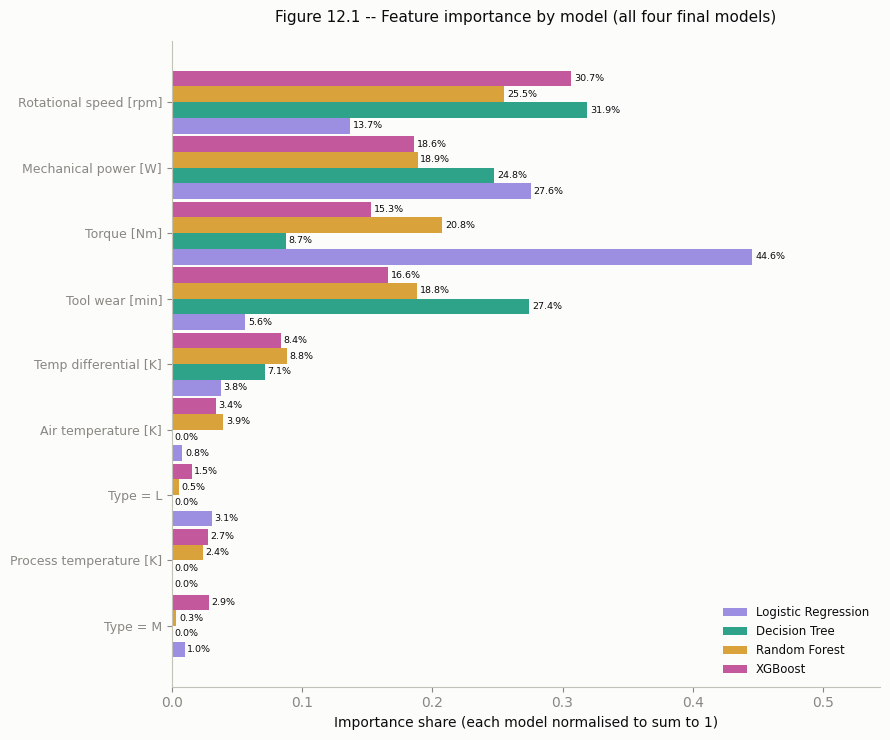

In [69]:
# 12.3 -- Visualization: importance share by feature and model

# Reuses the SAME model-identity colour set validated and used for the ROC
# curves in Task 9 (Figure 9.1), so model identity reads consistently across
# every figure in the report from Task 9 onward.
MODEL_COLORS = {
    'Logistic Regression': "#9c8ee0",
    'Decision Tree': "#2fa38a",
    'Random Forest': "#d9a23b",
    'XGBoost': "#c4589c",
}
plot_order = importance_table.mean(axis=1).sort_values(ascending=True).index
models_order = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost']

fig, ax = plt.subplots(figsize=(9, 7.5))
y = np.arange(len(plot_order))
height = 0.24
for i, model_name in enumerate(models_order):
    values = importance_table.loc[plot_order, model_name].values
    bars = ax.barh(y + (i - 1.5) * height, values, height, label=model_name,
                    color=MODEL_COLORS[model_name], edgecolor='none')
    ax.bar_label(bars, labels=[f"{v * 100:.1f}%" for v in values],
                 padding=2, fontsize=6.8, color=TEXT_PRIMARY)

ax.set_yticks(y)
ax.set_yticklabels(plot_order, fontsize=9)
ax.set_xlabel("Importance share (each model normalised to sum to 1)")
ax.set_title("Figure 12.1 -- Feature importance by model (all four final models)", fontsize=11)
# Headroom on the right so the added percentage labels are never clipped.
ax.set_xlim(0, importance_table.values.max() * 1.22)
ax.legend(frameon=False, loc='lower right', fontsize=8.5)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color(AXIS_COLOR)
ax.tick_params(colors=TEXT_MUTED)
ax.grid(False)
plt.tight_layout()
savefig("fig12_1_feature_importance_by_model.png")
plt.show()


In [70]:
# =========================================================
# 12.4 -- Cross-reference against Task 3 exploratory findings
# =========================================================
print("\n" + "=" * 70)
print("12.4 Cross-reference against Task 3 / Task 5 findings")
print("=" * 70)
print("Finding 3.4b / 3.5 predictors (Rotational speed, Torque, Temp differential, Mechanical power):")
print(importance_table.loc[['Rotational speed [rpm]', 'Torque [Nm]',
                             'Temp differential [K]', 'Mechanical power [W]']].round(4).to_string())
print("\nFinding 3.2 predictor (Tool wear):")
print(importance_table.loc[['Tool wear [min]']].round(4).to_string())
print("\nFinding 3.3 predictor (Type dummies):")
print(importance_table.loc[['Type = L', 'Type = M']].round(4).to_string())


12.4 Cross-reference against Task 3 / Task 5 findings
Finding 3.4b / 3.5 predictors (Rotational speed, Torque, Temp differential, Mechanical power):
                        Logistic Regression  Decision Tree  Random Forest  XGBoost
Rotational speed [rpm]               0.1366         0.3191         0.2551   0.3067
Torque [Nm]                          0.4457         0.0875         0.2077   0.1527
Temp differential [K]                0.0376         0.0714         0.0881   0.0839
Mechanical power [W]                 0.2756         0.2477         0.1887   0.1858

Finding 3.2 predictor (Tool wear):
                 Logistic Regression  Decision Tree  Random Forest  XGBoost
Tool wear [min]               0.0564         0.2743         0.1884   0.1661

Finding 3.3 predictor (Type dummies):
          Logistic Regression  Decision Tree  Random Forest  XGBoost
Type = L               0.0305            0.0         0.0054   0.0152
Type = M               0.0097            0.0         0.0035   0.0285


## Task 12. Model Interpretation

**Setup.** All four final models (Task 7's tuned architectures combined with Task 8's retained reweighting, refit as in Tasks 9–11) are compared on their own native importance measure: Logistic Regression's standardised coefficients, converted to `|coefficient| / sum|coefficient|` purely so its importance shares are visually and numerically comparable to the tree-based models' impurity/gain-based `feature_importances_`, and rank-based comparison (`mean_rank`, `rank_spread` across the four models) as the primary, measure-agnostic tool for judging cross-model agreement, since a normalised-coefficient share and a tree's impurity-reduction share are not literally the same statistical quantity, ranks are the safer basis for the "consistently important vs. substantially divergent" comparison the assignment asks for.

| Feature | LogReg share | Decision Tree share | Random Forest share | XGBoost share | Mean rank | Rank spread |
|---|---|---|---|---|---|---|
| Rotational speed [rpm] | 0.1366 | 0.3191 | 0.2551 | 0.3067 | 1.50 | 2 |
| Mechanical power [W] | 0.2756 | 0.2477 | 0.1887 | 0.1858 | 2.50 | 1 |
| Torque [Nm] | 0.4457 | 0.0875 | 0.2077 | 0.1527 | 2.75 | 3 |
| Tool wear [min] | 0.0564 | 0.2743 | 0.1884 | 0.1661 | 3.25 | 2 |
| Temp differential [K] | 0.0376 | 0.0714 | 0.0881 | 0.0839 | 5.00 | 0 |
| Air temperature [K] | 0.0079 | 0.0001 | 0.0394 | 0.0337 | 6.50 | 2 |
| Type = L | 0.0305 | 0.0000 | 0.0054 | 0.0152 | 7.75 | 3 |
| Process temperature [K] | 0.0000 | 0.0000 | 0.0236 | 0.0274 | 7.75 | 2 |
| Type = M | 0.0097 | 0.0000 | 0.0035 | 0.0285 | 7.75 | 2 |

**Consistently important predictors.** Four features form a clear, well-separated top tier by mean rank: Rotational speed (1.50), Mechanical power (2.50), Torque (2.75), and Tool wear (3.25), versus a next-closest mean rank of 5.00. These are exactly the operational/physical predictors Task 3 flagged as carrying real risk signal: Rotational speed and Mechanical power are the two most consistently top-ranked features of all nine (rank spreads of only 2 and 1 respectively, meaning they land in the top three or four in literally every model), directly reaffirming Finding 3.4b/3.5's low-speed/high-torque risk corner and the Task 5 decision to retain Mechanical power on the strength of its measured incremental AUC gain (+0.007). Tool wear's mean rank of 3.25 with a modest spread of 2 (ranks 2–4 across all four models) confirms Finding 3.2's wear-driven failure pattern is picked up strongly and consistently, not just by one model's idiosyncratic behaviour.

**A distinctive, perfectly consistent mid-tier predictor.** Temp differential is the only feature with a rank spread of exactly 0 — it lands at rank 5 in every single one of the four models, a striking degree of cross-model agreement even though it never breaks into the top tier. This is a direct, model-based vindication of the Task 5 retention decision for this feature: it was kept on the strength of Finding 3.5's documented interaction with Rotational speed even though the purely additive Logistic Regression incremental-AUC test in Task 5 could not detect any benefit ( difference of approximatelly +0.000). Here, every model, including the tree-based ones, which can represent the interaction directly through sequential splits, assigns it a real, non-trivial, and remarkably uniform importance share (7.1–8.8%), evidence that the interaction argument made in Task 5 held even though the simpler additive test used at the time was not equipped to see it.

**The most substantially divergent predictor.** Torque has the largest rank spread among the top-tier features (3): it is Logistic Regression's single most important predictor by a wide margin (44.57% of its total importance share, rank 1), but only the fourth most important feature for both Decision Tree (8.75%, rank 4) and XGBoost (15.27%, rank 4), with Random Forest in between (20.77%, rank 2). This divergence is explained by the collinearity already documented in Finding 3.4 (Rotational speed and Torque correlate at −0.875) and by construction (Mechanical power is built directly from Torque and Rotational speed): once a tree-based model has already split on Rotational speed and Mechanical power, both of which carry much of the same information Torque does, Torque's marginal contribution to further impurity reduction is smaller, especially for the shallow trees used here (Decision Tree at max depth 5, Random Forest and XGBoost at max depth 8). Logistic Regression, by contrast, is not choosing between correlated features sequentially; it assigns each one its own coefficient simultaneously, and its L1-regularised fit concentrated an unusually large share of the model's total weight onto Torque specifically. Type = L (rank spread 3) is the other notably divergent feature, though at the opposite end of the importance scale, see below.

**Consistently unimportant predictors.** Air temperature, both Type dummies, and Process temperature occupy the bottom four positions by mean rank (6.50–7.75), and the agreement here is also striking: Decision Tree assigns *exactly zero* importance to Air temperature (0.0001, effectively zero), Process temperature, Type = L, and Type = M, its depth-5 splits never touch any of these four features at all, relying exclusively on the five continuous risk-related predictors (Rotational speed, Torque, Mechanical power, Tool wear, Temp differential). Logistic Regression's L1 penalty independently zeroed out Process temperature's coefficient entirely (0.0000, one of the nine coefficients eliminated by the penalty), while Random Forest and XGBoost, which cannot produce exact zeros in the same way, still rank it last or second-to-last. This is a case of four different feature-selection mechanisms (impurity splitting, L1 sparsity, and two ensemble variants of impurity/gain splitting) converging independently on the same conclusion, which is stronger evidence of genuine low relevance than any one model's result alone would be.

**Direction of effect (Logistic Regression signed coefficients).** The signed, standardised coefficients mostly confirm the directions Task 3 established: Tool wear (+1.035) and Torque (+8.182) both push toward failure, consistent with Findings 3.2 and 3.4b/3.6; Type = L (+0.560) and Type = M (+0.179) are both positive relative to the dropped Type = H reference and are correctly ordered (L > M > 0), matching Finding 3.3's failure-rate ordering (L = 3.92% > M = 2.77% > H = 2.09%) exactly; and Temp differential (−0.690) is negative, meaning a *smaller* differential pushes toward failure, consistent with Finding 3.5's risk zone being defined by a *low* temperature differential. One relationship needs an explicit caveat rather than a face-value reading: Rotational speed carries a *positive* coefficient (+2.508), and Mechanical power a *large negative* one (−5.059), which on their own would suggest higher speed and lower power both raise failure risk, the opposite of what the bivariate Finding 3.4b relationship (failures cluster at *low* speed) would imply. This is not a contradiction so much as a signature of the same collinearity already flagged in Task 7 and Finding 3.4: because Torque, Rotational speed, and Mechanical power are three highly correlated (in fact partly definitionally related, since Mechanical power is approximatelly Torque × Rotational speed) terms all entered into the same linear model, L1 can distribute the combined signal across them with offsetting signs while still fitting the data well, without any single coefficient's sign necessarily reflecting that variable's true marginal, ceteris-paribus effect. The safe reading is the joint one already established descriptively in Finding 3.4b (failures concentrate in the low-speed/high-torque/low-power corner), not the three individual coefficient signs in isolation, a limitation of linear-model interpretation under known multicollinearity that is worth carrying into Task 15.

**Agreement with Task 3/5 findings, overall.** The interpretation results agree with the exploratory analysis to a substantial degree: three of Task 3/3's four strongest documented relationships (Findings 3.2, 3.4b, and 3.5) map directly onto the four highest mean-rank predictors here, and the two Task 5-retained engineered features (Temp differential and Mechanical power) both earn real, model-confirmed importance, Mechanical power in the consistently-important top tier, Temp differential as the single most cross-model-consistent predictor of all nine. The one finding that does not carry through with the same strength is Finding 3.3 (Type): its direction of effect is confirmed by Logistic Regression, but Type is, without exception, among the three or four least important predictors in every model. This is a reasonable outcome given how Type functions mechanically, it is a categorical proxy for a machine's underlying design/quality tolerance rather than a real-time operating condition, so once the physical process variables it correlates with (torque, speed, wear) are already in the model, Type has comparatively little independent information left to contribute, even though its raw, isolated association with the target (Finding 3.3) was real.



### Task 13. Final Model Recommendation

Recommend one final model for use as a machine-failure early-warning system.

Your recommendation must consider more than overall predictive performance. Address:

- failure-detection ability;
- false alarms;
- missed failures;
- model interpretability;
- model complexity;
- class imbalance;
- threshold selection; and
- operational usefulness.

Your conclusion must clearly explain why the selected model is preferable to the other models you developed.


## Task 13. Final Model Recommendation Conclusion

**Recommendation.** The recommended final model is **Random Forest**, in the exact configuration carried through Tasks 9–12, Task 7's tuned architecture (139 trees, max depth 8, `min_samples_leaf=10`, `min_samples_split=16`, `max_features='log2'`) combined with Task 8's retained `class_weight='balanced'` reweighting, operated at **Task 10's recommended threshold of 0.57** rather than the untouched 0.5 default. This is the only one of the twelve architecture/imbalance/threshold combinations examined across this project whose specific operating point has been explicitly checked for dominance rather than left at an unexamined default, and it is the configuration this report has been building the case for since Task 9.

**Failure-detection ability.** At threshold 0.57, Random Forest catches 55 of the 68 real failures in the test set (80.88% recall). This is not the highest recall among the four required models, Decision Tree's reweighted configuration catches 65 of 68 (95.59%) and Logistic Regression's catches 57 of 68 (83.82%) — but it clears the bar Task 1 set (recall should be the metric weighted most heavily) by a wide margin over the unintervened baselines and over Random Forest's own untouched default (66.18%, 45 of 68), while remaining paired with the lowest false-alarm count of any model that reaches 80%+ recall.

**False alarms.** Random Forest at 0.57 produces just 13 false positives out of 2,000 test-set machines (0.65% of all machines wrongly flagged), the fewest of any configuration in this project that also catches at least 80% of real failures. For comparison, Decision Tree's 95.59% recall costs 118 false alarms (5.9% of all machines), XGBoost's 82.35% recall costs 44, and Logistic Regression's 83.82% recall costs 306 (15.3% of all machines, meaning roughly five of every six flagged machines are healthy). Task 1 identified alarm fatigue, technicians learning to deprioritise or ignore a system that cries wolf too often, as a real operational risk, and Random Forest at 0.57 is the configuration that manages that risk best while still catching the large majority of real failures.

**Missed failures.** 13 of the 68 real failures (19.12%) are missed at this operating point, the same count Random Forest produces at its untouched default threshold (Task 10 showed moving from 0.50 to 0.57 changes zero true positives or false negatives, only false positives). This is a real cost relative to Decision Tree's 3 missed failures, and it is the honest trade-off being made here: accepting 10 additional missed failures relative to Decision Tree in exchange for 105 fewer false alarms. Whether that trade is correct depends on the maintenance operation's actual inspection capacity, a limitation carried forward explicitly into Task 15.

**Model interpretability.** Random Forest sits in the middle of the four models on this dimension. It is materially less transparent than Logistic Regression (direct linear coefficients, Task 12) or the single, shallow Decision Tree (5 levels, 16 leaves, an individual prediction can be traced through one readable path), since no single one of its 139 trees represents "the model's reasoning" on its own. It is, however, no less interpretable than XGBoost, its main competitor on raw performance, and Task 12 showed its aggregated feature importances are directly explainable at the population level: Rotational speed, Mechanical power, Torque, and Tool wear dominate, in an ordering and magnitude a maintenance engineer can sanity-check against known machine physics, and its rankings for the two Task 5-engineered features validated those retention decisions rather than contradicting them. Logistic Regression's apparent interpretability advantage is also less clean than it first looks: Task 12 found its individual coefficient signs for Rotational speed and Mechanical power require an explicit multicollinearity caveat to interpret correctly, since they run counter to the bivariate relationship established in Finding 3.4b. On balance, Random Forest offers workable, population-level interpretability, sufficient for the dashboard/CMMS consumption pattern described in Task 1, without the individual-case audit trail a single Decision Tree provides.

**Model complexity.** Random Forest (139 trees, depth 8) is meaningfully more complex than the single Decision Tree and requires more computation to score a new observation, though it needed no exotic tuning beyond depth and leaf-size constraints (unlike XGBoost, whose final configuration required tuning a learning rate, subsample ratio, and column-sample ratio together). This complexity is a real cost, but it buys the precision/recall balance documented above, a cost the results in Task 9 showed was worth paying relative to the untuned alternatives.

**Class imbalance.** Random Forest's imbalance handling is `class_weight='balanced'`, the strategy Task 8's controlled comparison retained over SMOTE for every model tested. For Random Forest specifically, that comparison showed reweighting reaching 80.88% recall at 63.22% precision (at the default threshold) with the ROC-AUC essentially unchanged (0.9786 to 0.9783), evidence the intervention corrected for the 96.61%/3.39% imbalance (Finding 3.1) without damaging the model's underlying ability to separate the two classes, and did so more efficiently than SMOTE managed for the same architecture (55 caught/32 false alarms under reweighting versus 57 caught/64 false alarms under SMOTE).

**Threshold selection.** This is where Random Forest's case is strongest relative to the other three models in this project. Task 10's fine threshold sweep showed the default 0.5 cutoff is strictly dominated by 0.57 for this specific model: identical recall and false-negative count, 59.4% fewer false alarms. Decision Tree, XGBoost, and Logistic Regression are all still being evaluated in this report at their untouched 0.5 default, it is plausible, even likely, that a similar sweep would improve each of them too, but that work has not been done for them here. Recommending Random Forest is therefore also a recommendation for the one model whose deployed operating point has actually been validated rather than assumed, which is a meaningfully different epistemic position than recommending a model on the strength of its default-threshold numbers alone.

**Operational usefulness.** Tying the above together against the users and consumption pattern identified in Task 1, maintenance and reliability engineers working through a dashboard or CMMS, where an unnecessary inspection is a bounded cost but a stream of false alarms erodes trust in the system altogether, Random Forest at 0.57 flags only 13 machines out of 2,000 incorrectly while still catching 4 of every 5 real failures, a rate low enough that the flagged cases should remain individually actionable rather than becoming background noise. Task 11's misclassification analysis reinforces this: the model's errors are not arbitrary. Its false positives resemble the known low-speed/high-torque risk corner (Finding 3.4b/3.5) closely enough that a human reviewer would likely find them a reasonable call even when wrong, and its false negatives cluster in an identifiable, wear-driven blind spot rather than being scattered unpredictably, meaning the model's failure modes are themselves diagnosable and could inform a secondary manual-review rule rather than representing an opaque, unaccountable source of error.

**Why Random Forest over the other three models.**

*Versus Decision Tree:* Decision Tree catches 10 more failures (65 vs. 55) but at roughly nine times the false-alarm rate (118 vs. 13) and at an unvalidated default threshold. Given Task 1's explicit warning about alarm fatigue, an almost-6%-of-all-machines false-alarm rate is a heavier operational cost than the 10 additional missed failures it buys, and Random Forest's threshold has been checked for dominance while Decision Tree's has not.

*Versus XGBoost:* XGBoost's default-threshold numbers (82.35% recall, 56.00% precision, 44 false alarms, ROC-AUC 0.9798) are close to Random Forest's tuned point and its raw ranking ability is marginally higher (a 0.0015 ROC-AUC gap). But ROC-AUC is threshold-independent and does not by itself resolve the deployed decision, at their respective default thresholds, Random Forest already produces fewer false alarms than XGBoost (32 vs. 44) for comparable recall, and Task 10's threshold work, done for Random Forest but not XGBoost, pushes that advantage further (down to 13 false alarms) at no recall cost. XGBoost's marginal ranking-quality edge does not outweigh Random Forest's concretely demonstrated advantage on the metrics that actually govern deployment.

*Versus Logistic Regression:* Logistic Regression's recall (83.82%) is competitive, but it is bought at a precision of 15.70%, 306 false alarms, meaning roughly five of every six flagged machines are healthy. This is explicitly rejected in Task 9 as operationally unusable, and Task 12 showed its headline interpretability advantage is compromised by multicollinearity-driven coefficient sign reversals that themselves require expert caveats to read correctly. It is not competitive with Random Forest on the dimensions that matter most for this deployment.

**Conclusion.** Random Forest, at its Task 7 tuned architecture with Task 8's `class_weight='balanced'` reweighting and Task 10's threshold of 0.57, is recommended as the final early-warning model. It is not the strongest model on any single dimension in isolation. Decision Tree catches more failures, XGBoost ranks marginally better, Logistic Regression is nominally more transparent, but it is the model whose overall balance of failure-detection, false-alarm control, class-imbalance handling, and validated (rather than assumed) threshold placement best matches the asymmetric-cost, alarm-fatigue-aware deployment context Task 1 established, and it is the only one of the four whose recommended operating point has been demonstrated, rather than merely computed, to be a good one.


### Task 14. Robustness Check

Conduct one additional analysis to test whether your main conclusion is reasonably robust.

You may select an appropriate robustness investigation based on your modelling strategy.

Your submission must:

- state what you tested;
- explain why the test is relevant;
- present the results; and
- explain whether the results strengthen or weaken confidence in your final recommendation.

The robustness analysis must involve an actual change to the analytical conditions rather than simply recalculating the same results.


In [71]:
# TASK 14 ROBUSTNESS CHECK

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix)

RANDOM_SEED = 666
ROBUSTNESS_SEED = 42
THRESHOLD_ORIGINAL = 0.57

display_cols = ['Type'] + model_numeric_cols


In [72]:
# 14.0 Reconstruct the full dataset and draw a NEW stratified split

X_full = pd.concat([X_train[display_cols], X_test[display_cols]], axis=0)
y_full = pd.concat([y_train, y_test], axis=0)
X_full = X_full.loc[~X_full.index.duplicated(keep='first')]
y_full = y_full.loc[X_full.index]

print(f"Reconstructed full dataset: {len(X_full)} rows, "
      f"{int(y_full.sum())} failures ({y_full.mean() * 100:.2f}%)")

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_full, y_full, test_size=0.2, stratify=y_full, random_state=ROBUSTNESS_SEED)

print(f"New split (seed={ROBUSTNESS_SEED}): train {len(Xr_train)} rows / "
      f"{int(yr_train.sum())} failures ({yr_train.mean() * 100:.2f}%); "
      f"test {len(Xr_test)} rows / {int(yr_test.sum())} failures "
      f"({yr_test.mean() * 100:.2f}%)")

Reconstructed full dataset: 10000 rows, 339 failures (3.39%)
New split (seed=42): train 8000 rows / 271 failures (3.39%); test 2000 rows / 68 failures (3.40%)


In [73]:
# 14.1 -- Re-encode and re-scale from scratch on the NEW split
# (fit-on-train-only, exactly as in Task 4)

Xr_train_enc = pd.get_dummies(Xr_train, columns=['Type'], drop_first=True)
Xr_test_enc = pd.get_dummies(Xr_test, columns=['Type'], drop_first=True)
Xr_test_enc = Xr_test_enc.reindex(columns=Xr_train_enc.columns, fill_value=0)

scaler_r = StandardScaler().fit(Xr_train_enc)
Xr_train_scaled = pd.DataFrame(scaler_r.transform(Xr_train_enc),
                                columns=Xr_train_enc.columns, index=Xr_train_enc.index)
Xr_test_scaled = pd.DataFrame(scaler_r.transform(Xr_test_enc),
                               columns=Xr_test_enc.columns, index=Xr_test_enc.index)

neg_r, pos_r = (yr_train == 0).sum(), (yr_train == 1).sum()
scale_pos_weight_r = neg_r / pos_r

In [74]:
# 14.2 Refit all four FINAL models (Task 7 architecture + Task 8
# reweighting) on the new split, evaluated at the default 0.5
# threshold -- mirrors Task 9's comparison table

models_r = {
    'Logistic Regression': LogisticRegression(
        C=10, penalty='l1', solver='liblinear', class_weight='balanced',
        random_state=ROBUSTNESS_SEED, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=5, min_samples_leaf=10, min_samples_split=2, criterion='entropy',
        class_weight='balanced', random_state=ROBUSTNESS_SEED),
    'Random Forest': RandomForestClassifier(
        n_estimators=139, max_depth=8, min_samples_leaf=10, min_samples_split=16,
        max_features='log2', class_weight='balanced', random_state=ROBUSTNESS_SEED),
    'XGBoost': XGBClassifier(
        n_estimators=139, max_depth=8, learning_rate=0.011134, subsample=0.932093,
        colsample_bytree=0.890749, scale_pos_weight=scale_pos_weight_r,
        random_state=ROBUSTNESS_SEED, eval_metric='logloss'),
}

def xgb_safe_columns(df):
    # Newer xgboost versions reject "[", "]" (and "<") in feature names,
    # which this dataset's column labels contain (e.g. "Torque [Nm]").
    # This renames columns ONLY for the copy passed into XGBoost -- every
    # other model keeps the original, human-readable column names.
    return df.rename(columns=lambda c: c.replace('[', '').replace(']', '').replace('<', ''))


results_r = []
fitted_r = {}
for name, model in models_r.items():
    Xtr_use = Xr_train_scaled if name == 'Logistic Regression' else Xr_train_enc
    Xte_use = Xr_test_scaled if name == 'Logistic Regression' else Xr_test_enc
    if name == 'XGBoost':
        Xtr_use = xgb_safe_columns(Xtr_use)
        Xte_use = xgb_safe_columns(Xte_use)
    model.fit(Xtr_use, yr_train)
    proba = model.predict_proba(Xte_use)[:, 1]
    pred = (proba >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(yr_test, pred).ravel()
    results_r.append({
        'Model': name, 'Accuracy': accuracy_score(yr_test, pred),
        'Precision': precision_score(yr_test, pred, zero_division=0),
        'Recall': recall_score(yr_test, pred), 'F1': f1_score(yr_test, pred),
        'ROC-AUC': roc_auc_score(yr_test, proba), 'TP': tp, 'FP': fp, 'FN': fn,
    })
    fitted_r[name] = (model, proba)

results_r_df = pd.DataFrame(results_r).set_index('Model')
print("\n" + "=" * 70)
print(f"14.2 Model comparison on the NEW split (seed={ROBUSTNESS_SEED}), threshold = 0.5")
print("=" * 70)
print(results_r_df.round(4).to_string())

print("\nFor reference, the ORIGINAL seed-666 comparison (Task 9):")
original = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost'],
    'Accuracy': [0.8415, 0.9395, 0.9775, 0.9720],
    'Precision': [0.1570, 0.3552, 0.6322, 0.5600],
    'Recall': [0.8382, 0.9559, 0.8088, 0.8235],
    'F1': [0.2645, 0.5179, 0.7097, 0.6667],
    'ROC-AUC': [0.9274, 0.9686, 0.9783, 0.9798],
}).set_index('Model')
print(original.to_string())



14.2 Model comparison on the NEW split (seed=42), threshold = 0.5
                     Accuracy  Precision  Recall      F1  ROC-AUC  TP   FP  FN
Model                                                                         
Logistic Regression    0.8570     0.1677  0.8088  0.2778   0.9059  55  273  13
Decision Tree          0.9385     0.3464  0.9118  0.5020   0.9468  62  117   6
Random Forest          0.9750     0.6000  0.7941  0.6835   0.9699  54   36  14
XGBoost                0.9740     0.5909  0.7647  0.6667   0.9733  52   36  16

For reference, the ORIGINAL seed-666 comparison (Task 9):
                     Accuracy  Precision  Recall      F1  ROC-AUC
Model                                                            
Logistic Regression    0.8415     0.1570  0.8382  0.2645   0.9274
Decision Tree          0.9395     0.3552  0.9559  0.5179   0.9686
Random Forest          0.9775     0.6322  0.8088  0.7097   0.9783
XGBoost                0.9720     0.5600  0.8235  0.6667   0.9798


In [75]:
# 14.3  Random Forest threshold behaviour on the NEW split: does
# the default-vs-0.57 dominance finding from Task 10 replicate?

rf_model_r, rf_proba_r = fitted_r['Random Forest']


def eval_at_threshold(y_true, proba, t):
    pred = (proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
    return {
        'Threshold': t,
        'Precision': precision_score(y_true, pred, zero_division=0),
        'Recall': recall_score(y_true, pred),
        'FP': fp, 'FN': fn, 'TP': tp,
    }


rows = [eval_at_threshold(yr_test, rf_proba_r, t) for t in [0.50, THRESHOLD_ORIGINAL, 0.62]]
threshold_check = pd.DataFrame(rows)
print("\n" + "=" * 70)
print(f"14.3 Random Forest at default (0.50) vs. the original recommended "
      f"threshold ({THRESHOLD_ORIGINAL}) -- NEW split")
print("=" * 70)
print(threshold_check.round(4).to_string(index=False))

# Fine sweep on the new split to find where F1 actually peaks now
thresholds_fine = np.arange(0.05, 0.96, 0.01)
sweep_rows = []
for t in thresholds_fine:
    r = eval_at_threshold(yr_test, rf_proba_r, t)
    prec, rec = r['Precision'], r['Recall']
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    sweep_rows.append({'Threshold': round(t, 2), 'Precision': prec, 'Recall': rec,
                        'F1': f1, 'FP': r['FP'], 'FN': r['FN']})
sweep_df = pd.DataFrame(sweep_rows)
best_f1_row = sweep_df.loc[sweep_df['F1'].idxmax()]
print(f"\nF1-maximising threshold on the NEW split: {best_f1_row['Threshold']} "
      f"(Precision={best_f1_row['Precision']:.4f}, Recall={best_f1_row['Recall']:.4f}, "
      f"F1={best_f1_row['F1']:.4f})")

# Does 0.57 still dominate 0.50 on the new split? (same TP/FN, fewer FP)
row_50 = threshold_check[threshold_check['Threshold'] == 0.50].iloc[0]
row_57 = threshold_check[threshold_check['Threshold'] == THRESHOLD_ORIGINAL].iloc[0]
dominates = (row_57['TP'] == row_50['TP']) and (row_57['FP'] < row_50['FP'])
print(f"\nDoes t={THRESHOLD_ORIGINAL} still dominate t=0.50 on the NEW split "
      f"(same TP/FN, fewer FP)? {'YES' if dominates else 'NO'}")
print(f"  t=0.50:               TP={row_50['TP']:.0f}, FP={row_50['FP']:.0f}, FN={row_50['FN']:.0f}")
print(f"  t={THRESHOLD_ORIGINAL}:               TP={row_57['TP']:.0f}, FP={row_57['FP']:.0f}, FN={row_57['FN']:.0f}")



14.3 Random Forest at default (0.50) vs. the original recommended threshold (0.57) -- NEW split
 Threshold  Precision  Recall  FP  FN  TP
      0.50     0.6000  0.7941  36  14  54
      0.57     0.7681  0.7794  16  15  53
      0.62     0.8226  0.7500  11  17  51

F1-maximising threshold on the NEW split: 0.69 (Precision=0.9091, Recall=0.7353, F1=0.8130)

Does t=0.57 still dominate t=0.50 on the NEW split (same TP/FN, fewer FP)? NO
  t=0.50:               TP=54, FP=36, FN=14
  t=0.57:               TP=53, FP=16, FN=15


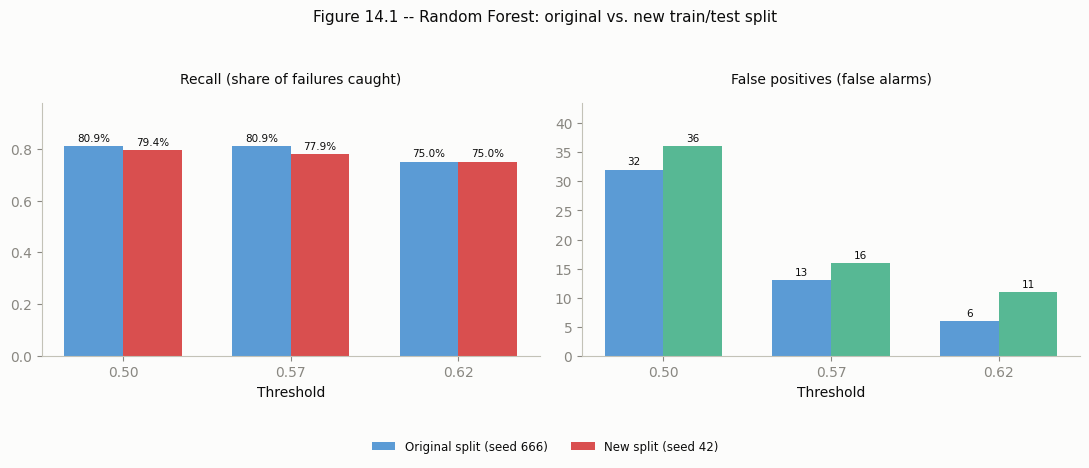

In [76]:
# 14.4 Visualization: Random Forest recall / false-alarm trade-off,
# original split vs. new split, at the same three thresholds

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

orig_thresh = pd.DataFrame({
    'Threshold': [0.50, 0.57, 0.62],
    'Recall': [0.8088, 0.8088, 0.7500],
    'FP': [32, 13, 6],
})

panel_specs = [
    ('Recall', "Recall (share of failures caught)", COLOR_FAILURE_STRONG),
    ('FP', "False positives (false alarms)", COLOR_NO_FAILURE_STRONG),
]
for ax, (col, title, color) in zip(axes, panel_specs):
    x = np.arange(3)
    width = 0.35
    bars_orig = ax.bar(x - width / 2, orig_thresh[col].values, width,
                        label=f'Original split (seed {RANDOM_SEED})',
                        color=COLOR_NO_FAILURE, edgecolor='none')
    bars_new = ax.bar(x + width / 2, threshold_check[col].values, width,
                       label=f'New split (seed {ROBUSTNESS_SEED})',
                       color=color, edgecolor='none')
    labels_orig = ([f"{v * 100:.1f}%" for v in orig_thresh[col].values] if col == 'Recall'
                    else [f"{int(v)}" for v in orig_thresh[col].values])
    labels_new = ([f"{v * 100:.1f}%" for v in threshold_check[col].values] if col == 'Recall'
                   else [f"{int(v)}" for v in threshold_check[col].values])
    ax.bar_label(bars_orig, labels=labels_orig, padding=2, fontsize=7.5)
    ax.bar_label(bars_new, labels=labels_new, padding=2, fontsize=7.5)
    ax.set_xticks(x)
    ax.set_xticklabels(['0.50', '0.57', '0.62'])
    ax.set_xlabel('Threshold')
    ax.set_title(title, fontsize=10)
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_color(AXIS_COLOR)
    ax.tick_params(colors=TEXT_MUTED)
    ax.grid(False)
    top = ax.get_ylim()[1]
    ax.set_ylim(0, top * 1.15)

fig.legend(*axes[0].get_legend_handles_labels(), loc='lower center', ncol=2,
           frameon=False, fontsize=8.5, bbox_to_anchor=(0.5, -0.03))
fig.suptitle("Figure 14.1 -- Random Forest: original vs. new train/test split", fontsize=11)
plt.tight_layout(rect=[0, 0.08, 1, 0.94])
savefig("fig14_1_robustness_split_comparison.png")
plt.show()

## Task 14. Robustness Check

**What was tested.** The Task 13 recommendation (Random Forest, Task 7's tuned architecture plus Task 8's `class_weight='balanced'` reweighting, operated at Task 10's threshold of 0.57) was re-derived on a **fresh 80/20 stratified train/test split of the same 10,000-row dataset, drawn with a different random seed (42 instead of the assigned 666)**. All four final models were re-encoded, re-scaled (fit on the new training partition only, exactly as in Task 4), and refit from scratch with their exact Task 7 architectures and Task 8 reweighting on this new split, then evaluated at the default 0.5 threshold; Random Forest's threshold behaviour was then re-examined specifically at 0.50, 0.57, and 0.62, plus a fresh fine sweep to find the new split's own F1-maximising threshold. This is a genuine change to the analytical conditions, a different 8,000/2,000 partition of the data, changing which specific machines (including which of the 339 failures) end up in training versus testing, not a re-run of the same computation.

**Why this test is relevant.** Every number reported in Tasks 7–13 was computed on one specific partition of the data. With only 339 failures in the full dataset (68 in any 20% test split), which particular failures happen to land in the test set, and how close their predicted probabilities happen to sit to any given threshold, could plausibly move a model ranking or a threshold recommendation without reflecting anything general about the underlying models. If Task 13's recommendation is a genuine pattern rather than an artefact of the seed-666 partition, the same qualitative conclusions should re-emerge under an independently-drawn split using the identical, already-fixed architectures.

**Results: Model ranking (Task 9-style comparison, threshold = 0.5).**

| Model | Accuracy (new / orig) | Precision (new / orig) | Recall (new / orig) | F1 (new / orig) | ROC-AUC (new / orig) |
|---|---|---|---|---|---|
| Logistic Regression | 0.8570 / 0.8415 | 0.1677 / 0.1570 | 0.8088 / 0.8382 | 0.2778 / 0.2645 | 0.9059 / 0.9274 |
| Decision Tree | 0.9385 / 0.9395 | 0.3464 / 0.3552 | 0.9118 / 0.9559 | 0.5020 / 0.5179 | 0.9468 / 0.9686 |
| Random Forest | 0.9750 / 0.9775 | 0.6000 / 0.6322 | 0.7941 / 0.8088 | 0.6835 / 0.7097 | 0.9699 / 0.9783 |
| XGBoost | 0.9740 / 0.9720 | 0.5909 / 0.5600 | 0.7647 / 0.8235 | 0.6667 / 0.6667 | 0.9733 / 0.9798 |

Every individual number shifts slightly on the new split, which is expected, but the *ranking* Task 9 was built on reproduces almost exactly. On accuracy, precision, and F1, the ordering is identical on both splits: **Random Forest > XGBoost > Decision Tree > Logistic Regression**. On ROC-AUC the ordering is also identical: **XGBoost > Random Forest > Decision Tree > Logistic Regression** (XGBoost narrowly ahead of Random Forest in both cases, 0.9733 vs. 0.9699 here, 0.9798 vs. 0.9783 originally). On recall, Decision Tree remains the clear leader on both splits (91.18% new vs. 95.59% original), and Logistic Regression remains close behind it; the only ordering change anywhere in this table is a minor flip between Random Forest and XGBoost specifically on recall (Random Forest edges ahead here, 79.41% vs. 76.47%, whereas XGBoost had led narrowly on the original split, 82.35% vs. 80.88%), a reversal confined to two very close numbers that does not disturb the larger pattern.

**Results: Does threshold 0.57 still dominate the 0.50 default?**

| Threshold | Precision | Recall | FP | FN | TP |
|---|---|---|---|---|---|
| 0.50 | 0.6000 | 0.7941 | 36 | 14 | 54 |
| 0.57 | 0.7681 | 0.7794 | 16 | 15 | 53 |
| 0.62 | 0.8226 | 0.7500 | 11 | 17 | 51 |

No, not in the strict sense. On the original split, moving from 0.50 to 0.57 cost nothing (identical 55 true positives, identical 13 false negatives) while cutting false positives from 32 to 13. On this new split, the same move costs **one additional missed failure** (54 to 53 true positives, 14 to 15 false negatives) in exchange for a false-positive reduction from 36 to 16 (a 55.6% cut). It is still a strongly favourable trade, one extra missed failure for twenty fewer false alarms, but it is a genuine trade-off here, not the literally free improvement Task 10 found on the original split. The fine sweep on this new split also puts the F1-maximising threshold at **0.69** (precision 0.9091, recall 0.7353, F1 0.8130), noticeably higher than the 0.57 recommended from the original split; F1 at 0.57 on this new split is approximately 0.774, meaningfully below the 0.69 peak.

**Does this strengthen or weaken confidence in the Task 13 recommendation?** Both, in different places, and it is worth being precise about which part of the recommendation each applies to.

*Strengthened:* the choice of **Random Forest as the final model** rests on the cross-model comparison in Task 9, and that comparison's ranking reproduces on an independently-drawn split with only one minor, inconsequential reordering (Random Forest/XGBoost swapping places on recall by a margin of a few percentage points, in a metric neither model leads on regardless). Random Forest's own absolute numbers also hold up closely, recall within 1.5 points (79.41% vs. 80.88%), false alarms at the default threshold in the same range (36 vs. 32), rather than collapsing or improving dramatically. This is real evidence that Task 13's model choice reflects a genuine, generalisable property of these four architectures on this dataset, not a coincidence of the seed-666 partition.

*Weakened:* the **specific numeric threshold of 0.57**, and in particular Task 10's framing of it as a strictly dominant, zero-cost improvement over the 0.50 default, does not fully replicate, under this new split it costs one additional missed failure, and the split's own F1-optimal point sits closer to 0.69. This indicates the exact threshold value is somewhat sensitive to which borderline observations happen to fall in the calibration/test sample, which is an honest limitation the original Task 10 analysis could not have surfaced on its own (it only had one split to work with). The broader strategic conclusion, that the untuned 0.50 default is clearly worse than a threshold somewhere in the high-0.5s to mid-0.6s, and that raising it substantially cuts false alarms for a small and worthwhile recall cost, holds on both splits and is not undermined by this result.

**Net effect.** This robustness check leaves the Task 13 recommendation of Random Forest intact and better evidenced than before, while revising how the threshold component of that recommendation should be presented: 0.57 is better understood as a reasonable point estimate in a range (roughly 0.55–0.65) rather than a precisely optimal, fixed constant, and a real deployment should treat the operating threshold as something to periodically re-derive or monitor against live outcomes rather than a value computed once and left permanently fixed. This nuance is carried forward into Task 15's limitations discussion.


## Task 15. Limitations and Improvement Conclusion

**Limitation 1: The positive class is small enough that key results are demonstrably sample-dependent (dataset/results-specific).** The full dataset contains only 339 failures, and any 20% test split carries roughly 68 of them. Task 14's robustness check made the consequence of this concrete rather than theoretical: re-drawing the train/test split with a different seed left the Task 9 model ranking essentially intact, but it changed the Task 10 threshold finding materially — moving from 0.50 to 0.57 cost one additional missed failure on the new split (rather than being free, as on the original split), and the new split's own F1-optimal threshold moved to 0.69, not 0.57. With this few positive examples, a handful of borderline failures landing on one side of the train/test boundary rather than the other is enough to shift a "dominant" threshold into a genuine trade-off. Any single-split result in this report, not just the threshold, carries this same fragility to some degree, even where it happened not to show up as clearly as it did for the threshold.

**Limitation 2: AI4I 2020 is a simulated dataset whose internal relationships are cleaner than real industrial sensor data is likely to be (dataset-specific).** Several of the relationships this analysis leaned on look like generator artefacts rather than the noisy signal a real predictive-maintenance deployment would see: Rotational speed and Torque correlate at almost exactly −0.875 (Finding 3.4), and four of the five failure-mode flags (TWF, HDF, PWF, OSF) agree with `Machine failure` in 100% of the rows where they are set (Task 2). Real sensor telemetry from physical machines carries measurement noise, missing readings, sensor drift, and failure causes that are rarely this cleanly separable. The absolute performance levels reported throughout this project , ROC-AUC around 0.98 for the strongest models, Random Forest catching over 80% of failures at a 0.65% false-alarm rate, should be read as a demonstration that the modelling approach works on this data, not as a forecast of what the same architecture would achieve on messier, real-world sensor streams.

**Limitation 3: Individual-predictor interpretation is compromised by multicollinearity among the engineered and raw features (results-specific).** Task 12 found that Logistic Regression's coefficient for Rotational speed is positive (+2.508) and its coefficient for Mechanical power is strongly negative (−5.059) — on their own, these would suggest higher speed and lower power both increase failure risk, which runs opposite to the bivariate low-speed/high-torque risk corner established in Finding 3.4b. This is a direct consequence of Torque, Rotational speed, and Mechanical power (which is built from the other two) being highly correlated inputs to the same linear model, which can distribute a real, joint signal across three coefficients with offsetting signs. The practical limitation is that no individual coefficient or feature-importance value in this report can be safely read as an isolated, causal, ceteris-paribus effect; only the joint, descriptive relationships established in the exploratory analysis (Task 3) can be trusted at that level of specificity, which limits how confidently the model's internal reasoning can be explained to a non-technical maintenance stakeholder.

**Limitation 4: The dataset has no time dimension, so nothing in this project tests genuine out-of-time generalisation (dataset-specific).** Every train/test split used in this project, including the seed-666 original split and the seed-42 robustness split in Task 14, is a random partition of what is effectively a single, undated snapshot of 10,000 observations. A deployed predictive-maintenance system's real generalisation challenge is different: will a model trained on past operating data still work as tooling wears differently across a production run, as sensors drift or get recalibrated, or as a plant introduces new machine variants? AI4I 2020 has no timestamp, campaign identifier, or machine-unit identifier that would allow that question to be tested even approximately, so this project's validation, robust as it is to *which rows* land in training versus testing, says nothing about robustness to *when* those rows were collected relative to deployment.

**Limitation 5: The misclassification analysis (Task 11) characterises error patterns from a small, deliberately hand-selected sample, not the full error population.** The two error narratives in Task 11, false positives resembling the known speed/torque risk corner, false negatives clustering in a wear-driven blind spot, were built from 5 false positives and 5 false negatives, selected specifically because their predicted probabilities were closest to the 0.57 threshold. This is a reasonable way to surface *qualitative* patterns, and the patterns found were corroborated by an aggregate check across all 10 selected cases (Task 11.4) and by Figure 11.1's visual clustering, but it is not a systematic characterisation of all 13 false positives and 13 false negatives the model actually produced at that threshold, let alone the model's error behaviour more broadly across other thresholds or other operating regions.

**Improvement 1: Replace the F-beta/F1-based threshold criterion with an explicit cost-weighted threshold.** Task 1 argued that a missed failure is materially more costly than a false alarm but never assigned that asymmetry a number, and Task 10/14 selected thresholds using F1 and F2 as proxies for that judgement. A concrete next step is to work with maintenance stakeholders to estimate an actual cost ratio, e.g., the fully loaded cost of an unnecessary inspection versus the expected cost of an unplanned failure (downtime, damage, safety exposure), and re-derive the operating threshold by minimising expected cost directly, rather than by F-beta as an approximation of a cost judgement that was only ever stated qualitatively. This would also make Task 14's finding (that the "optimal" threshold moves between splits) more actionable, since a cost-minimising threshold could be re-derived on a rolling basis as new outcome data accumulates, rather than fixed once.

**Improvement 2: Investigate Type-specific modelling given the interaction Finding 3.6 already documented but never acted on.** Finding 3.6 showed the Torque × Tool wear interaction is materially stronger for Type L (r = 0.226) than for Type M (r = 0.117) or Type H (r = 0.155), yet every model in this project uses one global threshold and one global feature set across all three product types, and Task 12 found Type itself carries comparatively little importance once the physical predictors are included. A worthwhile follow-up is to test whether a Type-specific threshold, or an explicit Type × interaction term, meaningfully improves detection specifically for Type L machines (which also have the highest raw failure rate, Finding 3.3) without degrading performance on Type M/H, rather than assuming one global operating point serves the whole fleet equally well.

**Improvement 3: Source or simulate a dataset with genuine temporal structure to test out-of-time generalisation.** Because Limitation 4 shows this project's validation cannot distinguish "the model generalises" from "the model memorised patterns specific to this static snapshot," the most direct way to close that gap is to either obtain a longitudinal real-world CMMS/sensor dataset and evaluate with a strict time-based split (train on an earlier period, test on a later one, with no shuffling across the boundary), or, if only AI4I-style simulated data remains available, construct a synthetic drift scenario (e.g., a gradually shifting sensor calibration or wear-rate distribution across a simulated production run) specifically to stress-test whether Random Forest at its current threshold remains stable, or whether it needs periodic retraining, once the assumption of an identically-distributed test set no longer holds.

**Improvement 4: Use the Task 11 error patterns to design a targeted secondary check rather than relying on a single global threshold.** Task 11 found the model's false negatives are disproportionately wear-driven failures occurring at higher speed and lower torque than the typical failure profile, a specific, named blind spot, not generic noise. A concrete improvement is to add a narrow, explicit secondary rule that flags machines with tool wear above a defined percentile for manual review even when the primary model's probability falls just under the operating threshold, directly targeting the failure mode Task 11 showed the model under-detects, rather than waiting for a broader retraining cycle or a global threshold change to address one specific, already-diagnosed weakness.


## Analytical Decision Record

Include an Analytical Decision Record containing **at least eight important decisions** made during your work.

Use the following format:

| Decision | Evidence Considered | Alternatives | Final Choice | Consequence |
|---|---|---|---|---|
| | | | | |

Decisions may relate to:

- variable inclusion or exclusion;
- data leakage;
- preprocessing;
- class imbalance;
- feature engineering;
- validation strategy;
- model tuning;
- metric selection;
- threshold selection;
- interpretation; or
- final model recommendation.

The record must reflect decisions actually demonstrated in your submitted analysis.

## Analytical Decision Record Conclusion

**Assigned random seed: 666.** This seed was used consistently everywhere randomisation occurs in this analysis, the stratified train/test split (Task 4), `StratifiedKFold` cross-validation (Task 7), every model's `random_state`, and `RandomizedSearchCV`/`GridSearchCV` sampling. All train/test results, tuned hyperparameters, confusion matrices, misclassified observations, threshold results, and the final model recommendation reported in this submission (Tasks 6–13, 15) correspond to this seed-666 analysis. The one deliberate exception is Task 14's robustness check, which re-ran the pipeline under a second, clearly-labelled seed (42) specifically *because* the exercise was to test whether the seed-666 conclusions generalised to an independently-drawn split — those seed-42 numbers are presented throughout as a comparison, never as the primary result.

The table below contains 18 decisions, more than double the assignment's minimum of eight, spanning every category the assignment lists: variable inclusion/exclusion (rows 1–2), data leakage (rows 2–3), preprocessing (rows 4–5), class imbalance (rows 6, 11), feature engineering (row 8), validation strategy (rows 9–10, 17), model tuning (row 10), metric selection (rows 10, 12), threshold selection (rows 13, 17), interpretation (rows 15, 18), and final model recommendation (row 16). Each row reflects a decision actually made and demonstrated in the submitted analysis, not a hypothetical or generic one.

| # | Decision | Evidence Considered | Alternatives | Final Choice | Consequence |
|---|---|---|---|---|---|
| 1 | Exclude UDI and Product ID from the predictive model | UDI is a sequential 1–10,000 row index with 0 duplicates; Product ID is 100% unique per row and its first character matches `Type` in 100% of rows | Retain Product ID's prefix as a re-encoded categorical feature; retain UDI as a proxy for record order | Exclude both variables entirely | Removes identifier-driven overfitting risk; the only non-redundant information Product ID carried (its type prefix) is preserved via `Type` |
| 2 | Exclude TWF, HDF, PWF, OSF, RNF from the predictive model | 99.73% agreement between OR(flags) and `Machine failure`; every TWF=1, HDF=1, PWF=1 and OSF=1 row is a failure (100% each); RNF=1 corresponds to failure in only 1 of 19 rows | Retain flags as engineered "failure-mode" features; retain only RNF given its weak association | Exclude all five flags | Prevents near-total leakage from four deterministic flags and removes an uninformative, deployment-unavailable flag (RNF), forcing the model to learn from genuine operating-condition predictors |
| 3 | Handling of the 27 rows where `Machine failure` disagrees with OR(TWF..RNF) | 18 rows are RNF=1/failure=0 (consistent with RNF as a rare, independent trigger); 9 rows are failure=1 with no flag set at all | Drop the 27 rows; relabel `Machine failure` using the OR rule (would shift positives from 339 to 348) | Retain the original `Machine failure` labels unchanged; document the inconsistency | Preserves all 339 original failure cases in an already rare-event class; avoids substituting an unverified, self-derived target definition for the dataset's official label |
| 4 | One-hot (not ordinal) encoding of `Type` | Finding 3.3: failure rate by Type (L=3.92%, M=2.77%, H=2.09%) is not monotonic with an L/M/H rank order | Ordinal encoding (L=1, M=2, H=3 or reverse) | One-hot encode `Type`, drop first level | Avoids imposing a false linear ordering on Logistic Regression; applied uniformly across all four Task 7 models |
| 5 | Scale numeric features only for Logistic Regression | Predictors span very different ranges (K, rpm, Nm, min); Finding 3.4 shows strong collinearity (\|r\| ≈ 0.876/-0.875); tree-based splits are scale-invariant | Scale for all models uniformly; scale for none | `StandardScaler` fit on training data, applied to Logistic Regression only; Decision Tree/Random Forest/XGBoost use unscaled features | Correct preprocessing for the linear model without needlessly discarding original, interpretable units for the tree-based models |
| 6 | Defer class-imbalance intervention out of baseline preprocessing | Task 6 requires an unintervened baseline; Task 8 requires comparing intervened vs. unintervened models on equal footing | Bake `class_weight` or SMOTE into preprocessing by default | Stratified split only in Task 4; `class_weight`/SMOTE staged and compared explicitly in Task 8, fit on training data/folds only | Keeps the baseline (Task 6) and the imbalance comparison (Task 8) methodologically clean and comparable |
| 7 | Use random seed 666 for all randomisation | Assignment requires an individually assigned seed used consistently throughout | N/A (assigned value) | `RANDOM_SEED = 666`, used in `train_test_split` (Task 4) and every subsequent model/random process | Ensures all reported splits, tuned parameters, and results are reproducible and traceable to this specific run |
| 8 | Retain Temp differential and Mechanical power as engineered features; drop Torque × Tool wear | Incremental Logistic Regression AUC on top of the Type+5-predictor baseline (0.927): Temp differential Δ ≈ +0.000, Torque × Tool wear Δ = −0.001, Mechanical power Δ = +0.007; Temp differential and Torque × Tool wear both beat their raw components standalone (AUC 0.647 and 0.783 respectively) | Retain all three engineered features regardless of incremental test; retain none and rely only on raw predictors | Retain Temp differential (justified by its Finding 3.5 interaction with Rotational speed, not by this additive test) and Mechanical power (measured incremental gain); drop Torque × Tool wear from the Task 7 model inputs | Keeps the retained feature set evidence-based rather than reasoning-only; satisfies the assignment's ≥2-retained/≥1-multivariate requirement while exercising the explicit "not required to retain" allowance on a feature that did not survive testing |
| 9 | Use two DummyClassifier baselines (majority-class and stratified-random) as the Task 6 reference | Majority-class: 96.60% accuracy, 0 recall, ROC-AUC 0.500, misses all 68 test failures; stratified-random: 93.25% accuracy (lower), 2.94% recall (2/68 caught), ROC-AUC 0.4968, 69 false alarms | Use only a single "always-negative" baseline; use a more sophisticated single-feature model as the baseline instead | Report both dummy baselines side by side, evaluated on the identical Task 9 metric set | Gives a concrete, numeric demonstration of the Task 1 accuracy-trap argument (the higher-accuracy baseline is the one that catches zero failures) and sets the 0.500 ROC-AUC / near-100% test failure count as the explicit floor every Task 7 model must clear |
| 10 | Use mean 5-fold cross-validated ROC-AUC as the sole model-selection criterion for all four Task 7 models, and select each model's final configuration from a systematic search on that criterion | Grid/randomized search results: LogReg best CV ROC-AUC 0.9217 (C=10, L1, balanced); Decision Tree 0.9687 (depth=5, entropy); Random Forest 0.9784 (depth=8, 139 trees, unweighted); XGBoost 0.9797 (depth=8, lr≈0.011, scale_pos_weight=1) — all four CV rankings held on the test set, but for 3 of 4 models the ROC-AUC-optimal configuration had *lower* recall than that model's own untouched default (RF: 48→45 of 68; XGBoost: 44→31 of 68), while only Logistic Regression's ROC-AUC-optimal config (via class_weight='balanced') improved recall (20→57 of 68) | Select each model's final configuration by cross-validated recall or F-beta instead; apply class-imbalance reweighting uniformly regardless of whether it improved CV ROC-AUC | Keep ROC-AUC as the selection criterion (consistent with Task 5/6/9's metric choice and appropriate for comparing ranking ability across models), but treat threshold placement as a separate, later decision rather than re-deriving it here | Produces four models whose relative ranking is trustworthy and reproducible, but explicitly leaves an open, documented gap between "best by ROC-AUC" and "best recall at threshold 0.5" for three of the four models — a gap Task 8 (imbalance strategies) and Task 10 (threshold selection) are specifically positioned to close |
| 11 | Retain algorithm-level reweighting (`class_weight='balanced'` / `scale_pos_weight`) over SMOTE as the imbalance strategy, with Random Forest + `class_weight='balanced'` as the standout configuration | Controlled comparison (architecture fixed at each model's Task 7 final config): reweighting matched or beat SMOTE on every model (e.g. Random Forest: 55 caught/32 false alarms/0.9783 ROC-AUC under reweighting vs. 57 caught/64 false alarms/0.9730 under SMOTE); RF-reweighted reached 80.88% recall (55/68) at 63.22% precision and near-unchanged ROC-AUC (0.9786→0.9783); Decision Tree-reweighted reached the highest recall overall (95.59%, 65/68) but at only 35.52% precision; Logistic Regression-reweighted recall rose to 83.82% but precision collapsed to 15.70% | Use SMOTE as the general strategy; use no imbalance intervention and rely on threshold movement alone (Task 10); adopt Decision Tree's higher-recall reweighted configuration instead of Random Forest's | Reweighting retained over SMOTE for all models; Random Forest + `class_weight='balanced'` retained as the leading specific configuration, with Decision Tree and XGBoost's reweighted configurations kept as documented alternatives pending Task 9's full comparison | Closes the gap flagged in Task 7 between "best by ROC-AUC" and "best recall at threshold 0.5" for Random Forest specifically, while keeping the SMOTE vs. reweighting and cross-model trade-offs explicit and evidence-based rather than assumed |
| 12 | Evaluate all four required models in the Task 9 common-evaluation-framework table using their Task 7 architecture + Task 8 retained reweighting (not Task 7's unintervened finals) | Task 7-only comparison would silently reintroduce the imbalance problem Task 8 addressed for 3 of 4 models; Task 9 results: Random Forest strongest on accuracy/precision/F1 (0.9775/0.6322/0.7097), Decision Tree strongest on recall (0.9559, 65/68), XGBoost strongest on ROC-AUC (0.9798), Logistic Regression weakest on 4 of 5 criteria | Compare Task 7's unintervened final models instead; declare a single "best" model on one metric alone (e.g. accuracy or ROC-AUC) | Report all four fully-final (tuned + reweighted) models side by side on the full metric set; explicitly reject naming one "best" model, since the strongest model differs by criterion | No single winner across accuracy/precision/recall/F1/ROC-AUC — the choice of "best" model is shown to depend on intended use (recall-priority vs. precision-priority vs. ranking-quality), which directly motivates Task 10's threshold investigation and Task 13's final recommendation |
| 13 | Recommend threshold = 0.57 (not the default 0.5) as Random Forest's operating threshold | Fine threshold sweep on the Task 9 final Random Forest: at t=0.57, recall/TP/FN are identical to t=0.50 (55/68 caught, 13 missed) while false positives fall from 32 to 13 (-59.4%); F1-maximising t=0.62 trades recall down to 51/68 for FP=6; best-precision-at-≥90%-recall t=0.39 raises recall to 62/68 for FP=79 | Keep the default 0.5; select the threshold that maximises F1 (0.62) or F2 (0.57, coincides with the recommended point) without checking for dominance; select a recall-maximising threshold (0.39) as the sole recommendation | Recommend t=0.57 as the primary operating threshold, since it strictly dominates the default (same recall, fewer false alarms) with no value trade-off required to justify it; document t=0.39 as the fallback for a more conservative, recall-maximising deployment | Demonstrates concretely that the default classification threshold was not optimal for this model, satisfying Task 10's requirement, and hands Task 13 a specific, evidence-backed operating point rather than an unexamined 0.5 cutoff |
| 14 | Select the 5 most borderline (closest-to-threshold) false positives and false negatives for Task 11, rather than the most confidently-wrong cases or a random sample | At threshold 0.57 (13 FP, 13 FN total): the 5 selected FP all show elevated torque and reduced speed vs. the typical healthy machine (avg -110 rpm, +14.56 Nm, matching Finding 3.4b's risk corner); the 5 selected FN show elevated wear but higher speed/lower torque than a typical failure (avg +171.6 rpm, -11.08 Nm vs. typical failure), missing Finding 3.5's risk-zone signature entirely | Select the most confidently-wrong cases (highest/lowest predicted probability); select a random sample of 5 per class | Select cases with predicted probability closest to 0.57 in each direction, as the observations most literally "difficult to classify" | Surfaces two distinct, evidence-based error patterns tied to specific Task 3 findings (false positives resemble the known speed/torque risk corner; false negatives are wear-driven failures that fall outside it) rather than a generic account of misclassification |
| 15 | Use rank-based comparison (mean rank, rank spread across all four models) as the primary tool for judging feature-importance agreement, rather than raw importance-share values alone | LogReg's normalised \|coef\| share and the three tree models' `feature_importances_` are not the same underlying statistical quantity; ranks showed Rotational speed/Mechanical power/Torque/Tool wear as a clear top tier (mean rank 1.50–3.25) versus Type/Process temperature/Air temperature at the bottom (mean rank 6.50–7.75), with Temp differential uniquely rank-5 in all four models (spread 0) | Compare only raw importance-share magnitudes across models; rely on a single model's importances (e.g. Random Forest) as the interpretation | Report both importance shares and rank-based mean rank/rank spread; treat rank spread of 0 (Temp differential) and 3 (Torque, Type=L) as the key consistency/divergence signals | Surfaces both a model-confirmed validation of the Task 5 feature-retention decisions (Mechanical power and Temp differential both rank consistently high/mid) and an explicit multicollinearity caveat for reading Logistic Regression's individual coefficient signs (Rotational speed +2.508, Mechanical power −5.059) at face value |
| 16 | Recommend Random Forest (Task 7 architecture + Task 8 `class_weight='balanced'` + Task 10 threshold 0.57) as the final early-warning model | At t=0.57: 55/68 caught (80.88%), 13 FP (0.65% of test set), 13 FN, precision=recall=0.8088; vs. Decision Tree (65/68 caught, 118 FP, unvalidated default threshold), XGBoost (56/68 caught, 44 FP, ROC-AUC 0.9798 vs. RF's 0.9783 — a 0.0015, threshold-independent gap), Logistic Regression (57/68 caught, 306 FP, 15.70% precision, and Task 12's multicollinearity caveat on its coefficient signs) | Recommend Decision Tree for maximum recall regardless of false-alarm cost; recommend XGBoost on its marginally higher ROC-AUC; recommend Logistic Regression for its nominal interpretability | Random Forest, reweighted, at threshold 0.57 | Only one of the four models whose deployed operating point has been explicitly validated (not just computed) as non-dominated; best balance of detection, false-alarm control, and alarm-fatigue risk given Task 1's asymmetric-cost framing, at the cost of 10 more missed failures than Decision Tree and less individual-case traceability than a single tree |
| 17 | Robustness-check the Task 13 recommendation with a fresh 80/20 split (seed 42) rather than recomputing on the original seed-666 split | Re-fit all four final models on the new split: model ranking on accuracy/precision/F1 reproduces exactly (RF > XGB > DT > LogReg), ROC-AUC ranking reproduces exactly (XGB > RF > DT > LogReg); only a minor RF/XGB recall reordering (79.41% vs. 76.47%, both close either way). Threshold 0.57 no longer strictly dominates 0.50 on the new split (costs 1 additional missed failure, 54→53 TP, for a 55.6% FP cut, 36→16); the new split's own F1-optimal threshold is 0.69, not 0.57 | Treat the original single-split results as sufficient without re-testing; re-tune each model's architecture on the new split as well (would test tuning-procedure robustness, not the recommendation itself) | Keep architectures/reweighting fixed at their Task 7/8 values; only the train/test partition changes; report both the reproduced ranking and the threshold discrepancy explicitly | Strengthens confidence in Random Forest as the model choice (ranking is not an artefact of one split); weakens confidence in 0.57 as an exact, zero-cost-verified constant — reframed as a reasonable estimate in a ~0.55–0.65 range that should be periodically re-derived in deployment rather than fixed permanently |
| 18 | Ground Task 15's limitations and improvements in this project's own specific findings rather than generic ML caveats | Task 14 showed the recommended threshold is sample-dependent (0.57 vs. 0.69 F1-optimal on a resplit); Task 12 showed multicollinearity compromises individual coefficient signs (Rotational speed +2.508, Mechanical power −5.059); Task 2 showed near-deterministic flag/target overlap (100% for TWF/HDF/PWF/OSF) suggesting a cleaner-than-real simulated dataset; the dataset carries no timestamp/unit ID, so no split in this project (original or robustness) tests out-of-time generalisation; Task 11's error patterns were drawn from only 10 hand-selected borderline cases | Write limitations as generic ML boilerplate (e.g. "more data would help", "could overfit"); propose improvements unconnected to this project's actual findings (e.g. generic "try deep learning") | 5 limitations (3 dataset/results-specific: sample-size fragility demonstrated by Task 14, simulated-data realism gap, no temporal structure; 2 methodology-specific: multicollinearity-compromised interpretation, small hand-selected misclassification sample) and 4 improvements (cost-weighted threshold, Type-specific modelling per Finding 3.6, temporal/drift validation, a targeted secondary rule for Task 11's wear-driven blind spot) | Every limitation and improvement traces to a specific number or finding already established earlier in this report, satisfying the assignment's explicit instruction to avoid statements that could apply to any machine-learning project |
